## آماده‌سازی

In [323]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import jdatetime
import datetime
import folium
from folium.plugins import HeatMap
from scipy import stats
from scipy.stats import ttest_ind
from pyproj import Transformer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, GridSearchCV, ParameterSampler, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor

    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    


## بخش ۱: معرفی داده

### بارگذاری دیتاست

In [166]:
df = pd.read_csv("Divar.csv")
city_class = pd.read_csv('iran_city_classification.csv')

### بررسی اولیه

In [167]:
df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [168]:
df = df.drop(columns=['Unnamed: 0'])

In [169]:
df.shape

(1000000, 60)

In [170]:
df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

### مقادیر یکتا و محل‌های گم‌شده

In [172]:
df['city_slug'].unique()

array(['karaj', 'tehran', 'mashhad', 'ahvaz', 'kermanshah',
       'mahdasht-city', 'pardis-city', 'foolad-shahr', 'rasht', 'mahabad',
       'shiraz', 'gonabad', 'azna', 'andisheh-new-town', 'chamestan',
       'babol', 'arak', 'pishva', 'tabriz', 'urmia', 'nur', 'kish',
       'nasimshahr', 'amol', 'yasuj', 'isfahan', 'ilam', 'najafabad',
       'yazd', 'pakdasht-city', 'bandar-ganaveh', 'chalus', 'sabzevar',
       'eslamshahr', 'dezful', 'mohammadieh', 'lavasan-city', 'sirjan',
       'Kordkuy', 'hamedan', 'qods-city', 'shandiz-city', 'mahmudabad',
       'aran-va-bidgol', 'bandar-abbas', 'bandar-kangan', 'kiashahr',
       'izadshahr', 'bushehr', 'tuyserkan', 'khoram-abad', 'qazvin',
       'khorramabad', 'kashan', 'nowshahr', 'hashtgerd-city', 'behshahr',
       'sanandaj', 'masal', 'shahin-dej', 'vahidieh', 'parand-city',
       'shush', 'mobarakeh', 'neyshabur', 'kerman', 'rudehen',
       'torbat-jam', 'polsefid', 'salman-shahr', 'saveh', 'shahriar-city',
       'damghan', 'ra

In [173]:
df['cat3_slug'].unique()

array(['villa', 'apartment-sell', 'apartment-rent', 'office-rent',
       'shop-sell', 'plot-old', 'house-villa-sell', 'house-villa-rent',
       'shop-rent', 'industry-agriculture-business-rent', 'office-sell',
       'industry-agriculture-business-sell', 'presell', 'suite-apartment',
       'partnership', 'workspace', nan], dtype=object)

In [174]:
df['cat2_slug'].unique()

array(['temporary-rent', 'residential-sell', 'residential-rent',
       'commercial-rent', 'commercial-sell', 'real-estate-services'],
      dtype=object)

In [175]:
df['location_latitude'].isna().sum(), df['location_longitude'].isna().sum(), df['location_radius'].isna().sum()

(np.int64(344392), np.int64(344392), np.int64(660301))

In [176]:
df['neighborhood_slug'].isna().sum()

np.int64(562861)

### بررسی ستون‌های قیمت، اجاره و رهن

In [177]:
df['price_mode'].value_counts(dropna=False)

price_mode
مقطوع     566444
NaN       426394
توافقی      5260
مجانی       1902
Name: count, dtype: int64

In [178]:
df['rent_mode'].value_counts(dropna=False)

rent_mode
NaN       647006
مقطوع     292081
مجانی      59241
توافقی      1672
Name: count, dtype: int64

In [179]:
df['credit_mode'].value_counts(dropna=False)

credit_mode
NaN       647006
مقطوع     349231
مجانی       2864
توافقی       899
Name: count, dtype: int64

In [180]:
cols_to_check = ['rent_mode', 'rent_value', 'credit_mode', 'credit_value',
                  'transformable_rent', 'transformed_rent',
                  'transformable_credit', 'transformed_credit']

df[df['rent_mode'] == 'مقطوع'][cols_to_check].head(10)

,rent_mode,rent_value,credit_mode,credit_value,transformable_rent,transformed_rent,transformable_credit,transformed_credit
2,مقطوع,26000000.0,مقطوع,7.500000e+08,26000000.0,NaN,7.500000e+08,NaN
3,مقطوع,95000000.0,مقطوع,9.500000e+08,95000000.0,NaN,9.500000e+08,NaN
5,مقطوع,6000000.0,مقطوع,2.500000e+08,6000000.0,1.0,2.500000e+08,400000000.0
6,مقطوع,16000000.0,مقطوع,1.500000e+08,16000000.0,NaN,1.500000e+08,NaN
15,مقطوع,18000000.0,مقطوع,1.000000e+08,18000000.0,NaN,1.000000e+08,NaN
17,مقطوع,6000000.0,مقطوع,1.000000e+08,6000000.0,NaN,1.000000e+08,NaN
18,مقطوع,15000000.0,مقطوع,2.500000e+08,15000000.0,NaN,2.500000e+08,NaN
21,مقطوع,100000.0,مقطوع,9.000000e+08,100000.0,21000000.0,9.000000e+08,200000000.0
23,مقطوع,100000.0,مقطوع,1.000000e+09,100000.0,NaN,1.000000e+09,NaN
27,مقطوع,7000000.0,مقطوع,1.100000e+08,7000000.0,NaN,1.100000e+08,NaN


In [181]:
df[df['transformed_rent'].notnull()]['cat2_slug'].value_counts()

cat2_slug
residential-rent    63299
commercial-rent      9110
Name: count, dtype: int64

In [182]:
df.groupby('cat2_slug')[['rent_value', 'credit_value']].apply(
    lambda x: x.notnull().mean()
)

,rent_value,credit_value
cat2_slug,,
commercial-rent,0.992477,0.992595
commercial-sell,0.000077,0.000077
real-estate-services,0.000103,0.000103
residential-rent,0.995524,0.998286
residential-sell,0.000005,0.000005
temporary-rent,0.000100,0.000100


In [183]:
df.groupby('cat2_slug')[['price_value']].apply(
    lambda x: x.notnull().mean()
)

,price_value
cat2_slug,
commercial-rent,0.000444
commercial-sell,0.826716
real-estate-services,0.062361
residential-rent,0.000022
residential-sell,0.957502
temporary-rent,0.000167


In [184]:
df[df['cat2_slug'] == 'commercial-sell']['price_mode'].value_counts(dropna=False)

price_mode
مقطوع     31929
NaN        5630
توافقی     1104
مجانی       198
Name: count, dtype: int64

In [185]:
df['cat2_slug'].value_counts()

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

In [186]:
df[df['cat2_slug'] == 'temporary-rent']['cat3_slug'].value_counts()

cat3_slug
suite-apartment    16465
villa              12899
workspace            539
Name: count, dtype: int64

### توابع کمکی

In [187]:
def iqr_capping(df:pd.DataFrame, column_names: list[str]):
    for columns in column_names:
        q1 = df[columns].quantile(0.25)
        q3 = df[columns].quantile(0.75)
        iqr = q3 - q1
        
        uppper_bound = q3 + (1.5 * iqr)
        lower_bound = q1 - (1.5 * iqr)

        df.loc[df[columns] > uppper_bound, columns] = uppper_bound
        df.loc[df[columns] < lower_bound, columns] = lower_bound
    return df

### پیش‌پردازش

#### مقادیر گمشده‌ی دسته‌بندی و شهر

یه مقدار cat3_slug گم بود٬ با استفاده از توضیحات آگهی به صورت دستی پرش کردیم.

In [188]:
df.loc[df['cat3_slug'].isnull() == True] # 1 missing value
df.loc[df['cat3_slug'].isnull() == True, 'cat3_slug'] = 'office-rent' # used description to fill
df.loc[df['cat3_slug'].isnull() == True]

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius


دو تا مقدار city_slug هم گم بودن اونا رو هم با توضیحات آگهی‌ها دستی پر کردیم.

In [189]:
# NOTE: the column is looked up by name because 'Unnamed: 0' was already dropped above
df.loc[df['city_slug'].isnull() == True, 'description'] # two were missing
df.iloc[676502, df.columns.get_loc('city_slug')] = 'shiraz' # used description to fill
df.iloc[292674, df.columns.get_loc('city_slug')] = 'golsar' # used description to fill
df.loc[df['city_slug'].isnull() == True]

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius


#### اجاره‌ی قابل مقایسه

In [190]:
df['comparable_rent'] = df['credit_value'] * 0.03 + df['rent_value']

In [191]:
df[['rent_value', 'credit_value', 'comparable_rent']].head(10)

,rent_value,credit_value,comparable_rent
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,26000000.0,750000000.0,48500000.0
3,95000000.0,950000000.0,123500000.0
4,NaN,NaN,NaN
5,6000000.0,250000000.0,13500000.0
6,16000000.0,150000000.0,20500000.0
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


**نکته برای بخش‌های بعد (رگرسیون):** ستون comparable_rent توی همین سلول از rent_value و credit_value خام ساخته شده و هنوزم مقادیر پرت خیلی بزرگ داره (تا یه میلیون میلیارد تومن) که بعدا توی تحلیل ماهانه پیدا کردیم و برای rent_value_clean حلش کردیم. قبل از اینکه comparable_rent رو توی مدل استفاده کنیم باید همون سقف/کف یا یه فیلتر مشابه رو روی credit_value هم بزاریم وگرنه مقادیر پرت وارد مدل میشه.

#### سال ساخت

In [192]:
df['construction_year'].unique()

array([nan, '۱۳۸۴', '۱۴۰۱', '۱۴۰۰', '۱۴۰۳', '۱۳۸۹', '۱۳۹۵', '۱۳۹۳',
       '۱۳۹۶', '۱۳۸۷', '۱۳۸۵', '۱۳۹۰', '۱۳۹۸', '۱۴۰۲', '۱۳۸۸',
       'قبل از ۱۳۷۰', '۱۳۹۲', '۱۳۸۳', '۱۳۹۴', '۱۳۹۱', '۱۳۸۰', '۱۳۷۸',
       '۱۳۷۵', '۱۳۹۷', '۱۳۹۹', '۱۳۸۲', '۱۳۸۶', '۱۳۷۹', '۱۳۷۲', '۱۳۷۴',
       '۱۳۷۶', '۱۳۷۷', '۱۳۷۱', '۱۳۸۱', '۱۳۷۳'], dtype=object)

In [193]:
persian_digits = "۰۱۲۳۴۵۶۷۸۹"
english_digits = "0123456789"

translation_table = str.maketrans(persian_digits, english_digits)

df['construction_year'] = df['construction_year'].str.translate(translation_table)

In [194]:
df['construction_year'].unique()

array([nan, '1384', '1401', '1400', '1403', '1389', '1395', '1393',
       '1396', '1387', '1385', '1390', '1398', '1402', '1388',
       'قبل از 1370', '1392', '1383', '1394', '1391', '1380', '1378',
       '1375', '1397', '1399', '1382', '1386', '1379', '1372', '1374',
       '1376', '1377', '1371', '1381', '1373'], dtype=object)

In [195]:
df['construction_year'].value_counts(normalize=True) * 100

construction_year
1403           14.250553
1390            7.248954
1402            7.161313
1400            6.579083
1395            6.500022
1398            4.683218
1397            4.452654
1396            4.349814
1401            4.330325
1385            4.175512
1399            3.627480
1393            3.566193
1392            3.202881
1394            3.200430
1388            2.974647
1380            2.878058
قبل از 1370     2.529577
1389            2.053742
1391            1.999931
1387            1.732718
1386            1.650838
1383            1.212756
1384            1.041151
1375            0.888300
1382            0.853734
1371            0.677962
1381            0.440044
1378            0.370789
1379            0.296018
1377            0.259491
1372            0.234608
1373            0.223944
1376            0.195262
1374            0.157999
Name: proportion, dtype: float64

In [196]:
df['construction_year_numeric'] = pd.to_numeric(
    df['construction_year'], errors='coerce'
)

In [197]:
print(df['construction_year_numeric'].describe())
print()
print("Number of NaN in the new column:", df['construction_year_numeric'].isnull().sum())
print("Number of NaN in the original column:", df['construction_year'].isnull().sum())

count    795191.000000
mean       1394.420196
std           7.428366
min        1371.000000
25%        1390.000000
50%        1396.000000
75%        1401.000000
max        1403.000000
Name: construction_year_numeric, dtype: float64

Number of NaN in the new column: 204809
Number of NaN in the original column: 184172


#### تعداد اتاق

In [198]:
df['rooms_count'].value_counts(dropna=False)

rooms_count
دو              404050
یک              192083
NaN             154101
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

In [199]:
room_mapping = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4
}

df['rooms_count_numeric'] = df['rooms_count'].map(room_mapping)

In [200]:
df[['rooms_count', 'rooms_count_numeric']].value_counts(dropna=False)

rooms_count   rooms_count_numeric
دو            2.0                    404050
یک            1.0                    192083
NaN           NaN                    154101
سه            3.0                    138633
بدون اتاق     0.0                     75898
چهار          4.0                     21371
پنج یا بیشتر  NaN                     13864
Name: count, dtype: int64

In [201]:
df['has_five_plus_rooms'] = df['rooms_count'] == 'پنج یا بیشتر'

In [202]:
df['has_five_plus_rooms'].value_counts()

has_five_plus_rooms
False    986136
True      13864
Name: count, dtype: int64

#### ستون‌های تاریخ (تقویم شمسی)

اول رشته‌های ماه شمسی رو از created_at_month خام میسازیم٬ بعد created_at_month به datetime تبدیل میشه برای نمودارای ماهانه.

In [203]:
df['created_at_month'].unique()

array(['2024-08-01 00:00:00', '2024-05-01 00:00:00',
       '2024-10-01 00:00:00', '2024-06-01 00:00:00',
       '2024-09-01 00:00:00', '2024-11-01 00:00:00',
       '2024-07-01 00:00:00', '2024-12-01 00:00:00',
       '2024-04-01 00:00:00', '2025-01-01 00:00:00',
       '2024-03-01 00:00:00', '2024-01-01 00:00:00',
       '2025-02-01 00:00:00', '2024-02-01 00:00:00',
       '2023-11-01 00:00:00', '2023-09-01 00:00:00',
       '2023-10-01 00:00:00', '2023-07-01 00:00:00',
       '2023-12-01 00:00:00', '2023-05-01 00:00:00',
       '2023-03-01 00:00:00', '2023-04-01 00:00:00',
       '2023-06-01 00:00:00', '2023-08-01 00:00:00',
       '2023-02-01 00:00:00', '2021-05-01 00:00:00',
       '2022-11-01 00:00:00', '2022-07-01 00:00:00',
       '2022-05-01 00:00:00', '2022-06-01 00:00:00',
       '2023-01-01 00:00:00', '2022-10-01 00:00:00',
       '2021-12-01 00:00:00', '2020-12-01 00:00:00',
       '2022-12-01 00:00:00', '2022-04-01 00:00:00',
       '2022-09-01 00:00:00', '2022-08-01 00:0

In [204]:
def convert_to_jalali_month(gregorian_str):
    if pd.isna(gregorian_str):
        return np.nan
    gregorian_date = pd.to_datetime(gregorian_str).date()
    jalali_date = jdatetime.date.fromgregorian(date=gregorian_date)
    return jalali_date.strftime("%Y-%m")

unique_months = df['created_at_month'].dropna().unique()

month_mapping = {
    month: convert_to_jalali_month(month) for month in unique_months
}

df['created_at_month_jalali'] = df['created_at_month'].map(month_mapping)

In [205]:
df[['created_at_month', 'created_at_month_jalali']].drop_duplicates().sort_values('created_at_month')

,created_at_month,created_at_month_jalali
359490,2020-02-01 00:00:00,1398-11
151134,2020-12-01 00:00:00,1399-09
580785,2021-02-01 00:00:00,1399-11
36722,2021-05-01 00:00:00,1400-02
335401,2021-06-01 00:00:00,1400-03
667152,2021-11-01 00:00:00,1400-08
141441,2021-12-01 00:00:00,1400-09
400383,2022-01-01 00:00:00,1400-10
353671,2022-02-01 00:00:00,1400-11
606334,2022-03-01 00:00:00,1400-12


ساخت ستون‌های تاریخ جدید (تقویم فارسی/شمسی).

In [206]:
df['created_at_month'] = pd.to_datetime(df['created_at_month'])
df['created_at_month']

0        2024-08-01
1        2024-05-01
2        2024-10-01
3        2024-06-01
4        2024-05-01
            ...    
999995   2024-07-01
999996   2024-07-01
999997   2024-11-01
999998   2024-09-01
999999   2024-08-01
Name: created_at_month, Length: 1000000, dtype: datetime64[ns]

In [207]:
farsi_months_dic = {1 : 'Farvardin', 2: 'Ordibehesht', 3 : 'Khordad', 4: 'Tir', 5: 'Mordad', 6: 'Shahrivar', 7 : 'Mehr', 8 : 'Aban', 9 : 'Azar', 10 : 'Dey', 11 : 'Bahman', 12 : 'Esfand'}
df['farsi_date'] = df['created_at_month'].apply(lambda x: jdatetime.date.fromgregorian(date=x.date()) if pd.notna(x) else None)
df['farsi_date']

0         1403-05-11
1         1403-02-12
2         1403-07-10
3         1403-03-12
4         1403-02-12
             ...    
999995    1403-04-11
999996    1403-04-11
999997    1403-08-11
999998    1403-06-11
999999    1403-05-11
Name: farsi_date, Length: 1000000, dtype: object

In [208]:
df['farsi_month_numerical'] = df['farsi_date'].apply(lambda date: date.month)
df['farsi_year'] = df['farsi_date'].apply(lambda date: date.year).astype(str)
df['farsi_month_2'] = df['farsi_month_numerical'].apply(lambda month: farsi_months_dic[month])
df['farsi_month'] = df['farsi_month_2'] + ' ' +  df['farsi_year']
df.drop(columns=['farsi_month_numerical', 'farsi_year', 'farsi_year', 'farsi_month_2'], inplace=True)
df['farsi_month']

0              Mordad 1403
1         Ordibehesht 1403
2                Mehr 1403
3             Khordad 1403
4         Ordibehesht 1403
                ...       
999995            Tir 1403
999996            Tir 1403
999997           Aban 1403
999998      Shahrivar 1403
999999         Mordad 1403
Name: farsi_month, Length: 1000000, dtype: object

#### کدگذاری عددی تعداد اتاق و پرچم‌های امکانات

اینجا ساختیمش چون هم ماتریس همبستگی (سوال ۸) و هم تحلیل امکانات بر حسب منطقه (سوال ۹) این ستونارو لازم دارن. از روی ستون‌های خام پرچمی حساب شدن (مقادیر گمشده NaN نگه داشته شده).

In [209]:
persian_num_map = {"یک": 1, "دو": 2, "سه": 3, "چهار": 4, "پنج یا بیشتر": 5, "بدون اتاق": 0}
df["rooms_count_num"] = pd.to_numeric(df["rooms_count"].replace(persian_num_map), errors="coerce")

bool_map = {"true": 1, "false": 0, "unselect": np.nan, True: 1, False: 0}
amenities = ["has_balcony", "has_elevator", "has_security_guard", "has_barbecue", "has_pool"]
for col in amenities:
    df[col + "_num"] = pd.to_numeric(df[col].replace(bool_map), errors="coerce")

## بخش ۲: تحلیل‌های آماری

### آمار توصیفی

#### ۱. توزیع آگهی‌ها (cat2_slug و cat3_slug)

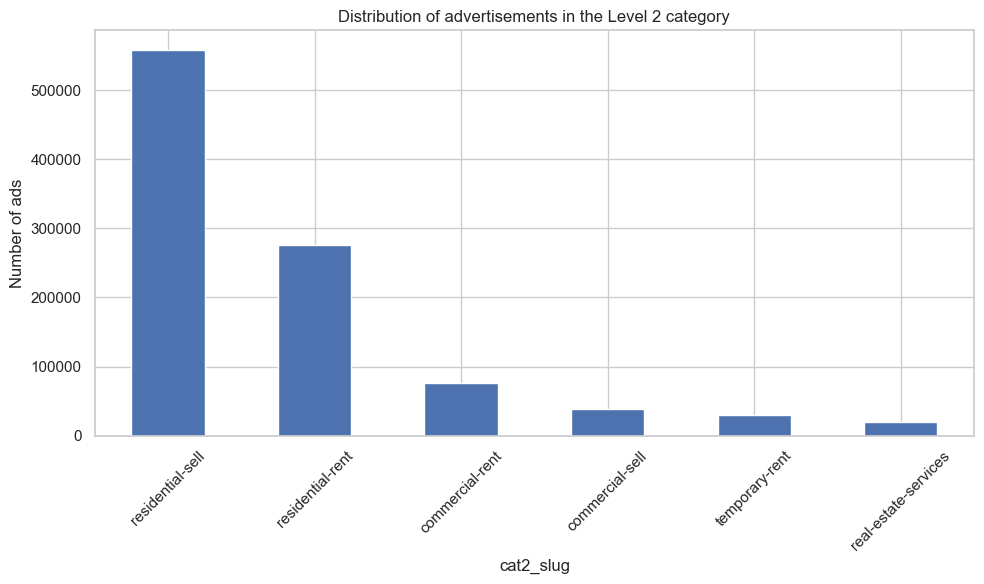

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64


In [210]:
cat2_counts = df["cat2_slug"].value_counts()
cat2_counts.plot(kind="bar", figsize=(10, 6))

plt.xlabel("cat2_slug")
plt.ylabel("Number of ads")
plt.title("Distribution of advertisements in the Level 2 category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(cat2_counts)

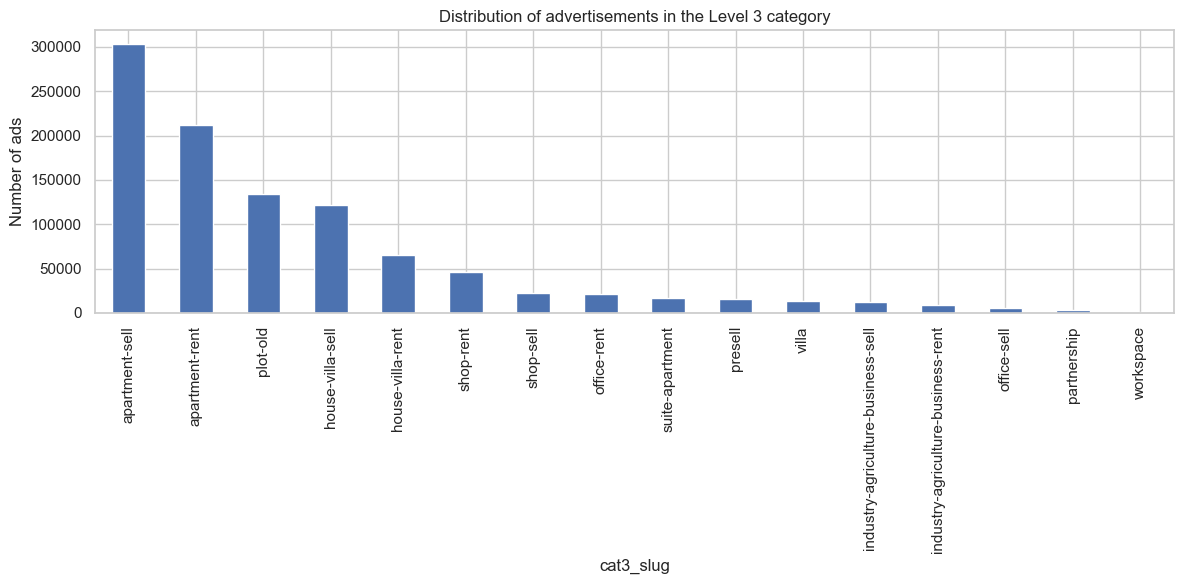

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21419
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64


In [211]:
cat3_counts = df["cat3_slug"].value_counts()
cat3_counts.plot(kind="bar", figsize=(12, 6))

plt.xlabel("cat3_slug")
plt.ylabel("Number of ads")
plt.title("Distribution of advertisements in the Level 3 category")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(cat3_counts)

<div dir="rtl" style="text-align:right">

#### ۲. توزیع سال ساخت

</div>

In [212]:
# چند تا توضیح تصادفی از آگهی‌هایی که سال ساخت ندارن می‌خونیم
sample_desc = df[df['construction_year'].isnull()]['description'].sample(20, random_state=42)
for desc in sample_desc:
    print(desc)
    print('---')

زمین  با کاربری کشاورزی باغی حاصلخیز وورجه یک
مساحت ۱۱۹۰۰متر
درحال حاضر دارای سند قطعی مشاعی محضری
دارای کلیه استعلامات جهاد کشاورزی .اوقاف.منابع طبیعی ودارایی ثبت اسناد
دارای نقشه utmنظام مهندسی
مناسب برای احداث باغ
بر جاده نجم اباد
آدرس نظر اباد جاده نجم اباد بعد از خرم اباد روبه رو سه‌راهی حسین خانلو
---
یازده قصب زمین دیوارکشی مکانی مناسب برای ویلاسازی دارای پروانه ساخت امتیاز آب برق گاز .دارای  آب رایگان قنات .
---
باغ منزل واقع در باغستان علیا دارای فضای سنتی و سرسبز وارام مجهز به پارکینگ فاصله از فردوس ۱۵کیلومتر فاصله تا آبگرم معدنی ۵کیلومتر
---
زمین مسکونی آماده ساخت در روستای مرزی ملت آباد 
موقعیت عالی برای ساخت  خانه یا انباری و سرمایه‌گذاری پ
۱۵ متر حدودا با  جاده اصلی فاصله داره 
قابل معاوضه با زمین از محله ایثارگران
با چک معتبر
متراژ بالا داریم
---
۳۰۰۰ متر زمین
دارای قولنامه یک ساعت اب
قولنامه ای و دارای شرایط گرفتن سند
جنب مجتمع بزرگ ویلایی
گاز و برق با فاصله ۲۰۰ متری
تخفیف پای قولنامه
اس ام اس جوابگو نیستم
ممنون
---
باسلام
یک دستگاه خانه دوطبقه کلنگی قابل سکونت 
جهت فرو

In [213]:
# این آگهی‌ها بیشتر چه دسته‌ای هستن؟
df[df['construction_year'].isnull()]['cat3_slug'].value_counts(normalize=True).head(10) * 100

cat3_slug
plot-old                              72.524054
suite-apartment                        8.940013
presell                                8.568621
villa                                  7.003779
partnership                            1.966640
industry-agriculture-business-sell     0.359990
workspace                              0.292661
industry-agriculture-business-rent     0.259540
office-rent                            0.038551
shop-rent                              0.016289
Name: proportion, dtype: float64

<div dir="rtl" style="text-align:right">

حدود ۱۸٫۴٪ آگهی‌ها سال ساخت ندارن. وقتی نگاه کردیم، بیشترشون (حدود ۸۱٪) زمین یا پیش‌فروشن و اصلاً سال ساخت ندارن. فقط حدود ۳٫۵٪ کل داده واقعاً «گم‌شده»ست. برای همین این ستون رو پر نکردیم.

</div>

In [214]:
# آپارتمان/ویلای بدون سال ساخت توی فروش و اجاره‌ی بلندمدت داریم یا نه؟
mask = (
    df['construction_year'].isnull() &
    df['cat3_slug'].isin(['suite-apartment', 'villa']) &
    df['cat2_slug'].isin(['residential-rent', 'residential-sell', 'commercial-rent', 'commercial-sell'])
)
print("Number of target rows:", mask.sum())

Number of target rows: 0


<div dir="rtl" align="right">

بررسی بیشتر نشان داد suite-apartment و villa به‌طور ساختاری فقط زیر دسته‌ی اجاره‌ی کوتاه‌مدت تعریف شده‌اند (صفر مورد در فروش یا اجاره‌ی بلندمدت)، که تأییدِ دیگری بر بی‌فایده‌بودن استخراج متنی برای این ستون است

</div>

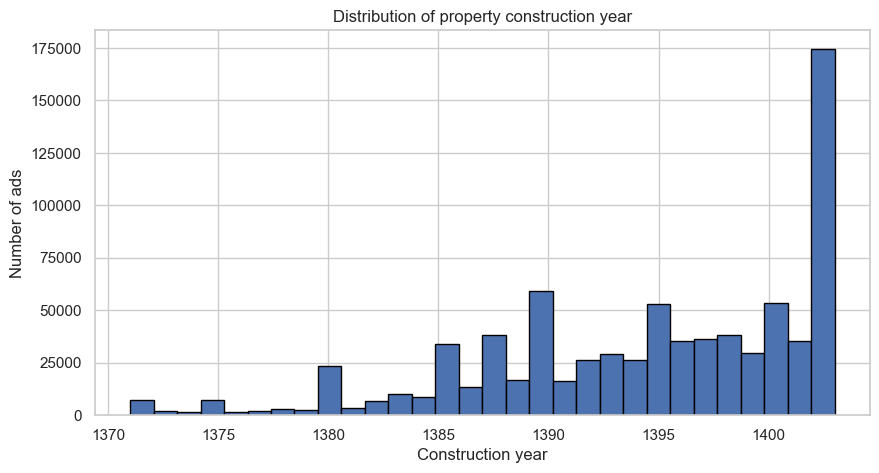

In [215]:
# هیستوگرام سال ساخت
plt.figure(figsize=(10, 5))
plt.hist(df['construction_year_numeric'].dropna(), bins=30, edgecolor='black')
plt.xlabel("Construction year")
plt.ylabel("Number of ads")
plt.title("Distribution of property construction year")
plt.show()

<div dir="rtl" align="right">

### هیستوگرام سال ساخت

این هیستوگرام توزیع سال ساخت ملک‌ها را در آگهی‌های ثبت‌شده نشان می‌دهد. محور افقی سال ساخت و محور عمودی تعداد آگهی‌ها را نمایش می‌دهد. هر ستون، تعداد ملک‌هایی را نشان می‌دهد که سال ساخت آن‌ها در یک بازهٔ مشخص قرار دارد؛ بنابراین ارتفاع بیشتر ستون‌ها بیانگر تمرکز بیشتر آگهی‌ها در آن بازهٔ زمانی است. در این نمودار فقط سال‌های ساخت دقیق نمایش داده شده‌اند و مقادیر «قبل از ۱۳۷۰» و سال‌های ثبت‌نشده در محاسبهٔ هیستوگرام وارد نشده‌اند.

</div>

In [216]:
# «قبل از ۱۳۷۰» چند درصد آگهی‌های دارای سال رو تشکیل می‌ده؟
n_pre1370 = (df['construction_year'] == 'قبل از 1370').sum()
n_with_year = df['construction_year'].notnull().sum()

print(f"Number of 'before 1370' ads: {n_pre1370}")
print(f"Percentage of all ads that have a year: {n_pre1370 / n_with_year * 100:.2f}")

Number of 'before 1370' ads: 20637
Percentage of all ads that have a year: 2.53


In [217]:
# نوع آگهی‌های سال ۱۴۰۳ (برای فهمیدن دلیل ستون بلند)
df[df['construction_year_numeric'] == 1403]['cat2_slug'].value_counts(normalize=True) * 100

cat2_slug
residential-sell    69.457251
residential-rent    18.915362
commercial-rent      6.793394
commercial-sell      4.833993
Name: proportion, dtype: float64

<div dir="rtl" align="right">

### تفسیر توزیع سال ساخت

علاوه بر ۱۸۴,۱۷۲ آگهی بدون سال ساخت ثبت‌شده که از ابتدا از این تحلیل کنار گذاشته شدند، ۲۰,۶۳۷ آگهی دیگر (۲.۵۳٪ از کل آگهی‌های دارای سال) فقط دارای عبارت «قبل از ۱۳۷۰» بودند و به‌دلیل نبود سال دقیق، در هیستوگرام نمایش داده نشدند. همچنین، ستون بلند سال ۱۴۰۳ نباید به‌عنوان یک موج واقعی ساخت‌وساز تفسیر شود؛ بررسی نشان داد ۶۹.۵٪ آگهی‌های این سال از نوع فروش هستند (در برابر سهم عادی ۵۶٪ در کل داده)، که نشان‌دهنده‌ی سوگیری نمونه‌گیری ذاتی داده‌های آگهی است: خانه‌های نوساز به‌طور نامتناسبی بیشتر برای فروش عرضه می‌شوند تا خانه‌های قدیمی‌تر.

</div>

#### ۳. آگهی‌های فروش و اجاره در ماه‌های مختلف

In [218]:
df['created_at_month'] = pd.to_datetime(df['created_at_month'])
farsi_months_dic = {1 : 'Farvardin', 2: 'Ordibehesht', 3 : 'Khordad', 4: 'Tir', 5: 'Mordad', 6: 'Sharivar', 7 : 'Mehr', 8 : 'Aban', 9 : 'Azar', 10 : 'Dey', 11 : 'Bahman', 12 : 'Esfand'}
df['farsi_date'] = df['created_at_month'].apply(lambda x: jdatetime.date.fromgregorian(date=x.date()) if pd.notna(x) else None)
df['farsi_date']

0         1403-05-11
1         1403-02-12
2         1403-07-10
3         1403-03-12
4         1403-02-12
             ...    
999995    1403-04-11
999996    1403-04-11
999997    1403-08-11
999998    1403-06-11
999999    1403-05-11
Name: farsi_date, Length: 1000000, dtype: object

In [219]:
df['farsi_month_numerical'] = df['farsi_date'].apply(lambda date: date.month)
df['farsi_year'] = df['farsi_date'].apply(lambda date: date.year).astype(str)
df['farsi_month_2'] = df['farsi_month_numerical'].apply(lambda month: farsi_months_dic[month])
df['farsi_month'] = df['farsi_month_2'] + ' ' +  df['farsi_year']
df.drop(columns=['farsi_month_numerical', 'farsi_year', 'farsi_year'], inplace=True)

In [220]:
df['ad_type'] = df['cat2_slug'].apply(lambda x: 'rent' if 'rent' in x else ('sell' if 'sell' in x else None))
df[df['ad_type'] == 'rent'] # 383028 total rent cat2_slugs
len(df[(df['ad_type'] == 'rent') & (df['rent_value'].isna() == True)]) # 31714 of rents with missing values in rent_value column

31714

In [221]:
len(df[(df['ad_type'] == 'rent') & (df['rent_value'].isna() == True) & (df['cat2_slug'] == 'temporary-rent')]) # 29900 of 31714 are temp rents 

29900

۱۸۱۴ تا مقدار گمشده توی rent_value مربوط به اجاره‌های غیر موقت داریم که با توجه به اینکه کلا ۳۸۳۰۲۸ تا آگهی اجاره داریم، میشه حذفشون کرد.

پس اجاره‌های موقت رو کنار میذاریم و بعد اجاره‌ها رو توی زمان‌های مختلف سال رسم می‌کنیم.

In [222]:
rent_no_temp = df[(df['ad_type'] == 'rent') & (df['cat2_slug'] != 'temporary-rent')].copy()
rent_no_temp = rent_no_temp.groupby('created_at_month')['ad_type'].count()

In [223]:
main_rent_no_temp = df[(df['ad_type'] == 'rent') & (df['cat2_slug'] != 'temporary-rent')].copy()
main_rent_no_temp = main_rent_no_temp.groupby('farsi_month_2')['ad_type'].count()

حالا یکی هم فقط برای اجاره‌های موقت.

In [224]:
rent_temp = df[(df['ad_type'] == 'rent') & (df['cat2_slug'] == 'temporary-rent')].copy()
rent_temp = rent_temp.groupby('created_at_month')['ad_type'].count()

In [225]:
main_rent_temp = df[(df['ad_type'] == 'rent') & (df['cat2_slug'] == 'temporary-rent')].copy()
main_rent_temp = main_rent_temp.groupby('farsi_month_2')['ad_type'].count()

و یکی هم برای فروش‌ها.

In [226]:
df[df['ad_type'] == 'sell'] # 597569 total sell in cat2_slug
len(df[(df['ad_type'] == 'sell') & (df['price_value'].isna() == True)]) # 30478 missing values in price_value column for sell in cat2_slug

30478

In [227]:
main_sell_data = df[df['ad_type'] == 'sell'].copy()
main_sell_data = main_sell_data.groupby('farsi_month_2')['ad_type'].count()

In [228]:
sell_data = df[df['ad_type'] == 'sell'].copy()
sell_data = sell_data.groupby('created_at_month')['ad_type'].count()
sell_data

created_at_month
2020-02-01        1
2021-02-01        1
2021-05-01        1
2021-06-01        1
2021-11-01        1
2021-12-01        1
2022-01-01        1
2022-02-01        1
2022-04-01        2
2022-05-01        2
2022-06-01        1
2022-07-01        1
2022-08-01        6
2022-09-01        1
2022-10-01        4
2022-11-01        5
2022-12-01        6
2023-01-01       10
2023-02-01        9
2023-03-01        7
2023-04-01        9
2023-05-01       37
2023-06-01       45
2023-07-01       62
2023-08-01       72
2023-09-01      120
2023-10-01      148
2023-11-01      278
2023-12-01      421
2024-01-01      765
2024-02-01      984
2024-03-01     1387
2024-04-01     5465
2024-05-01    71581
2024-06-01    71584
2024-07-01    75079
2024-08-01    73392
2024-09-01    67652
2024-10-01    75146
2024-11-01    77085
2024-12-01    75250
2025-01-01      817
2025-02-01      124
2025-03-01        4
Name: ad_type, dtype: int64

نمودارای دقیق‌تر برای فروش و اجاره.

In [229]:
res_sell = df[df['cat2_slug'] == 'residential-sell'].copy()
res_sell = res_sell.groupby('created_at_month')['ad_type'].count()
com_sell = df[df['cat2_slug'] == 'commercial-sell'].copy()
com_sell = com_sell.groupby('created_at_month')['ad_type'].count()

In [230]:
res_rent = df[df['cat2_slug'] == 'residential-rent'].copy()
res_rent = res_rent.groupby('created_at_month')['ad_type'].count()
com_rent = df[df['cat2_slug'] == 'commercial-rent'].copy()
com_rent = com_rent.groupby('created_at_month')['ad_type'].count()

نمودار کلی سوال ۳:

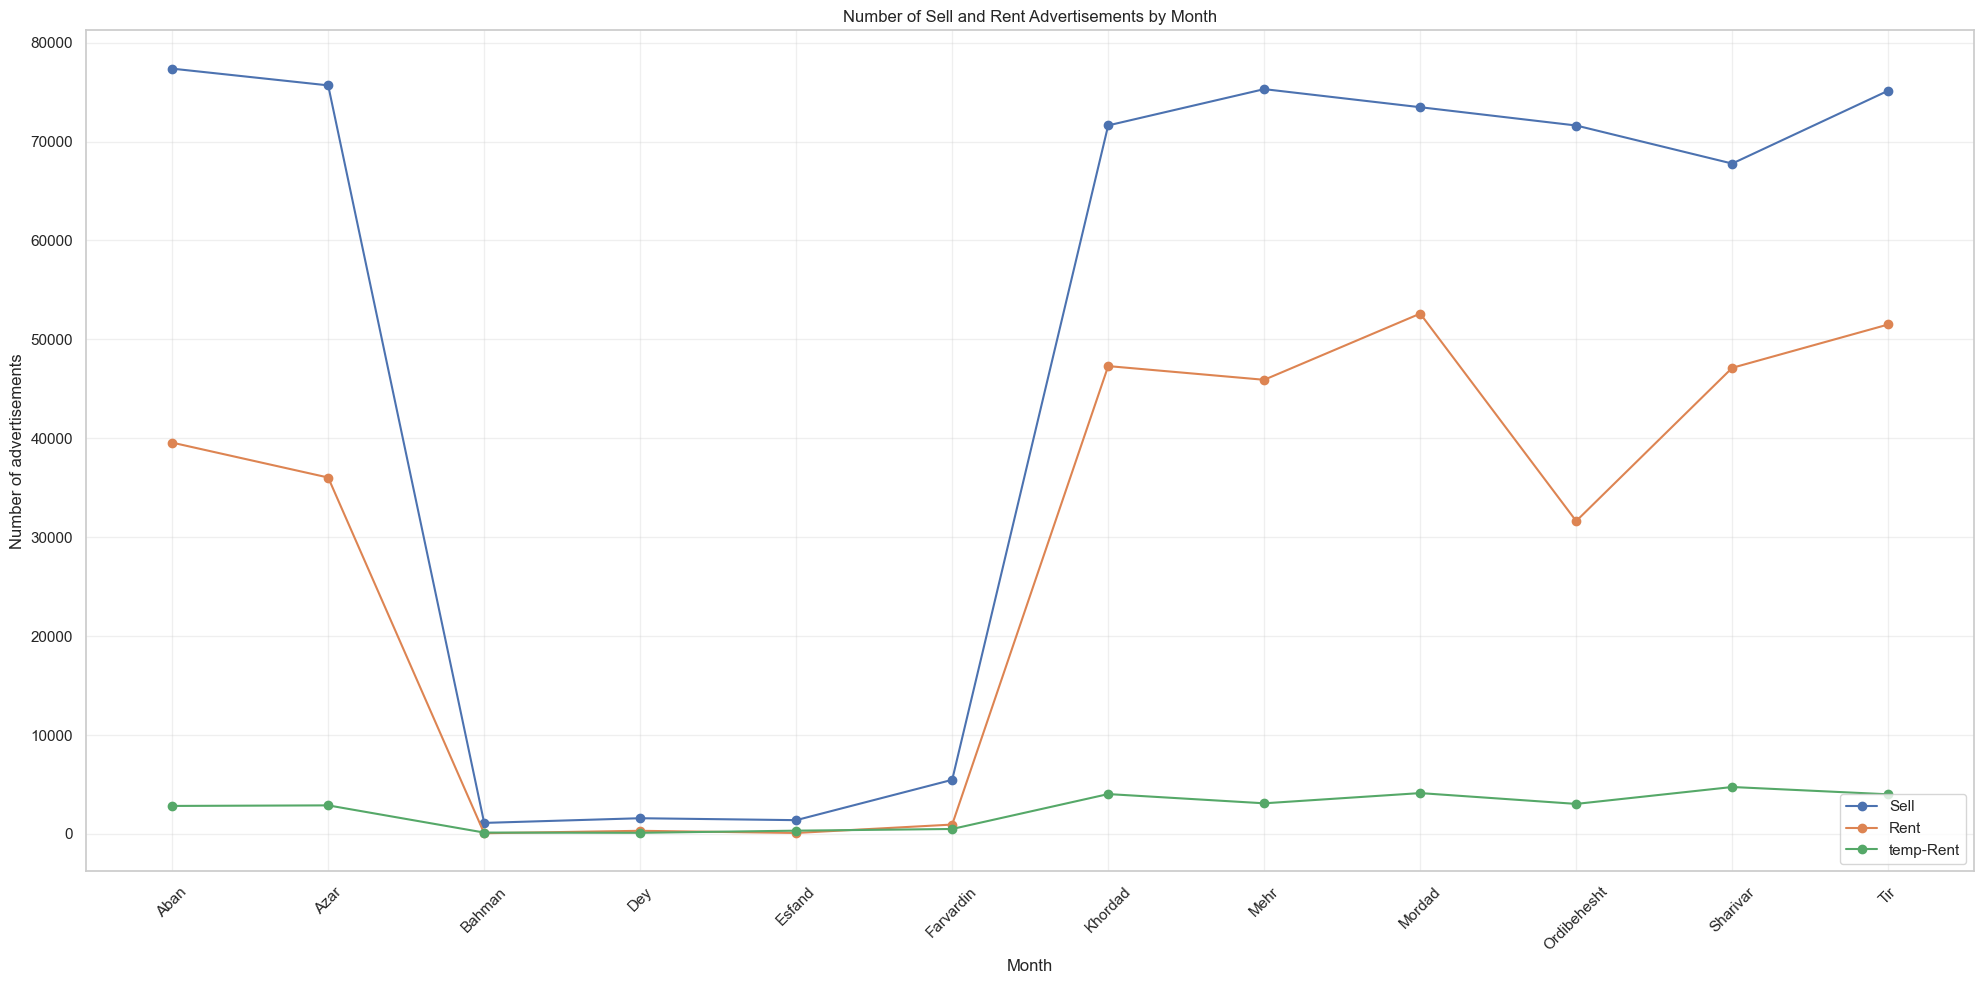

In [231]:
plt.figure(figsize=(20, 10))

plt.plot(main_sell_data.index, main_sell_data.values, marker='o', label='Sell')
plt.plot(main_rent_no_temp.index, main_rent_no_temp.values, marker='o', label='Rent')
plt.plot(main_rent_temp.index, main_rent_temp.values, marker='o', label='temp-Rent')

plt.xlabel('Month')
plt.ylabel('Number of advertisements')
plt.title('Number of Sell and Rent Advertisements by Month')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=0))
plt.tight_layout()
plt.show()

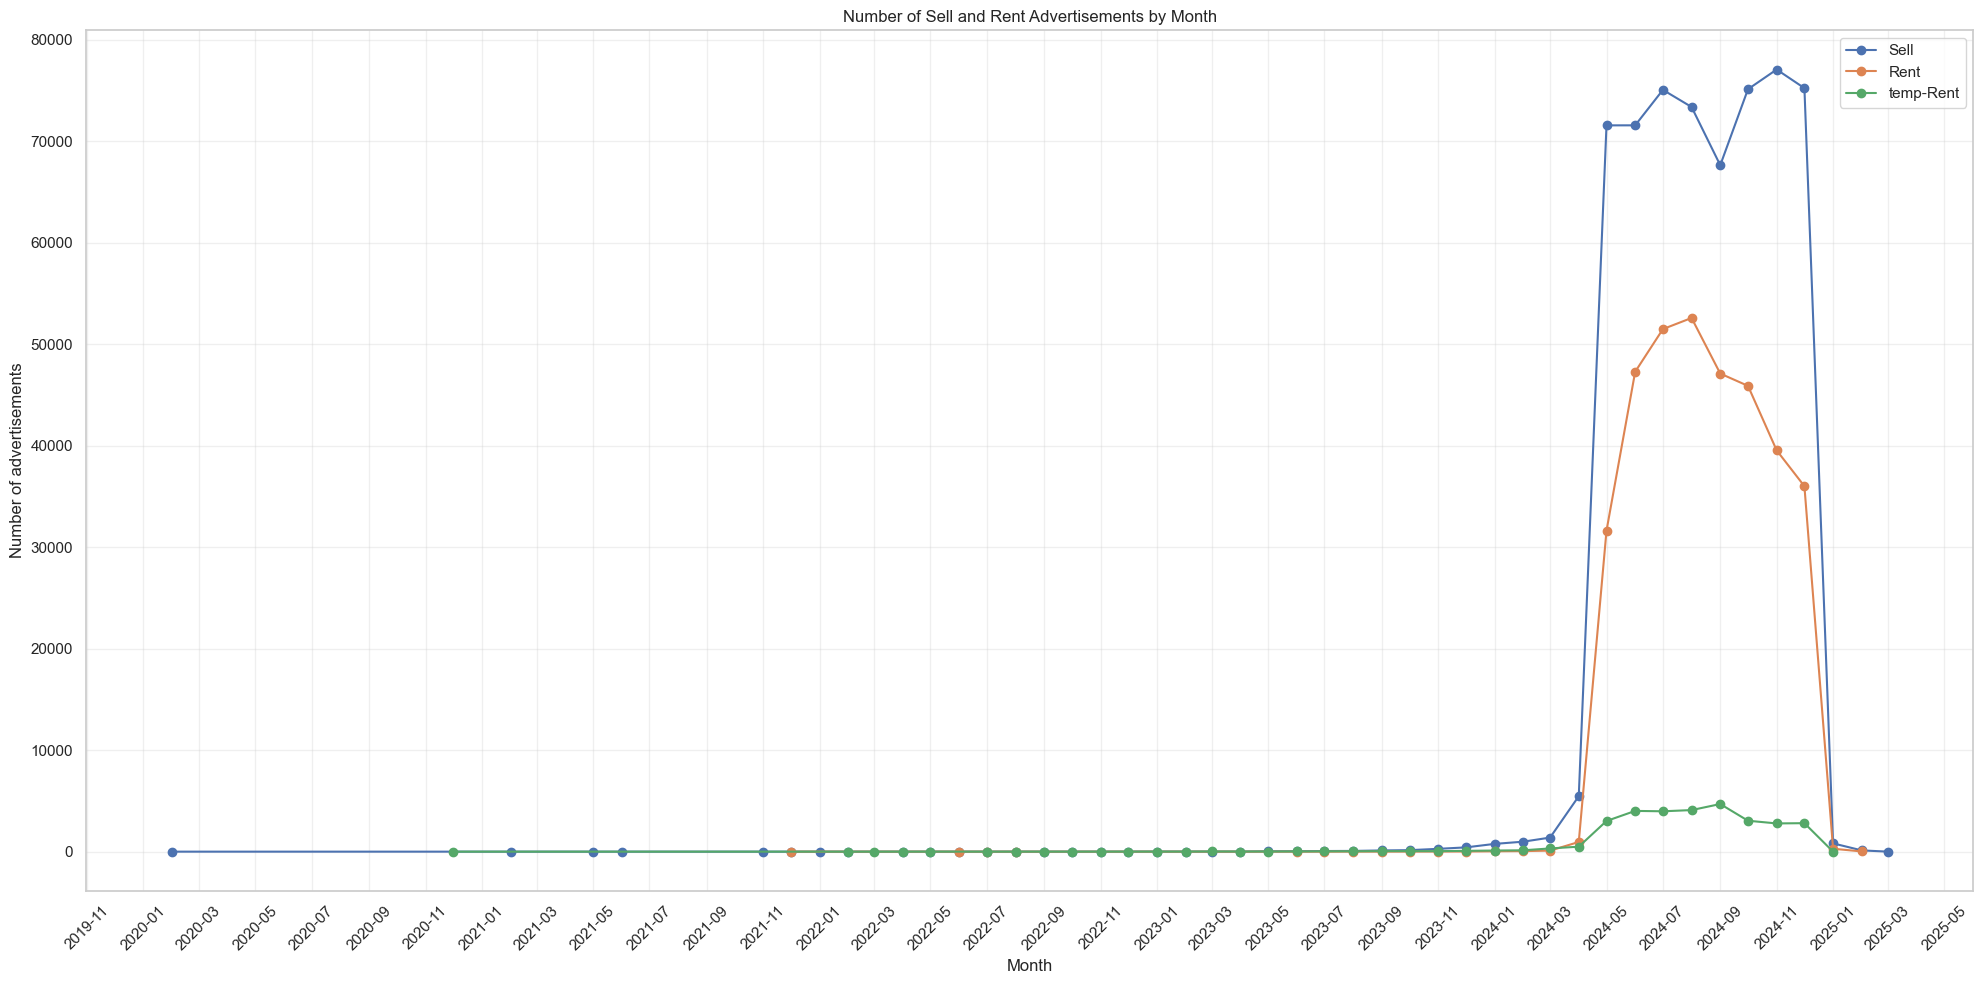

In [232]:
plt.figure(figsize=(20, 10))

plt.plot(sell_data.index, sell_data.values, marker='o', label='Sell')
plt.plot(rent_no_temp.index, rent_no_temp.values, marker='o', label='Rent')
plt.plot(rent_temp.index, rent_temp.values, marker='o', label='temp-Rent')

plt.xlabel('Month')
plt.ylabel('Number of advertisements')
plt.title('Number of Sell and Rent Advertisements by Month')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.show()

نمودارای جزئی سوال ۳:

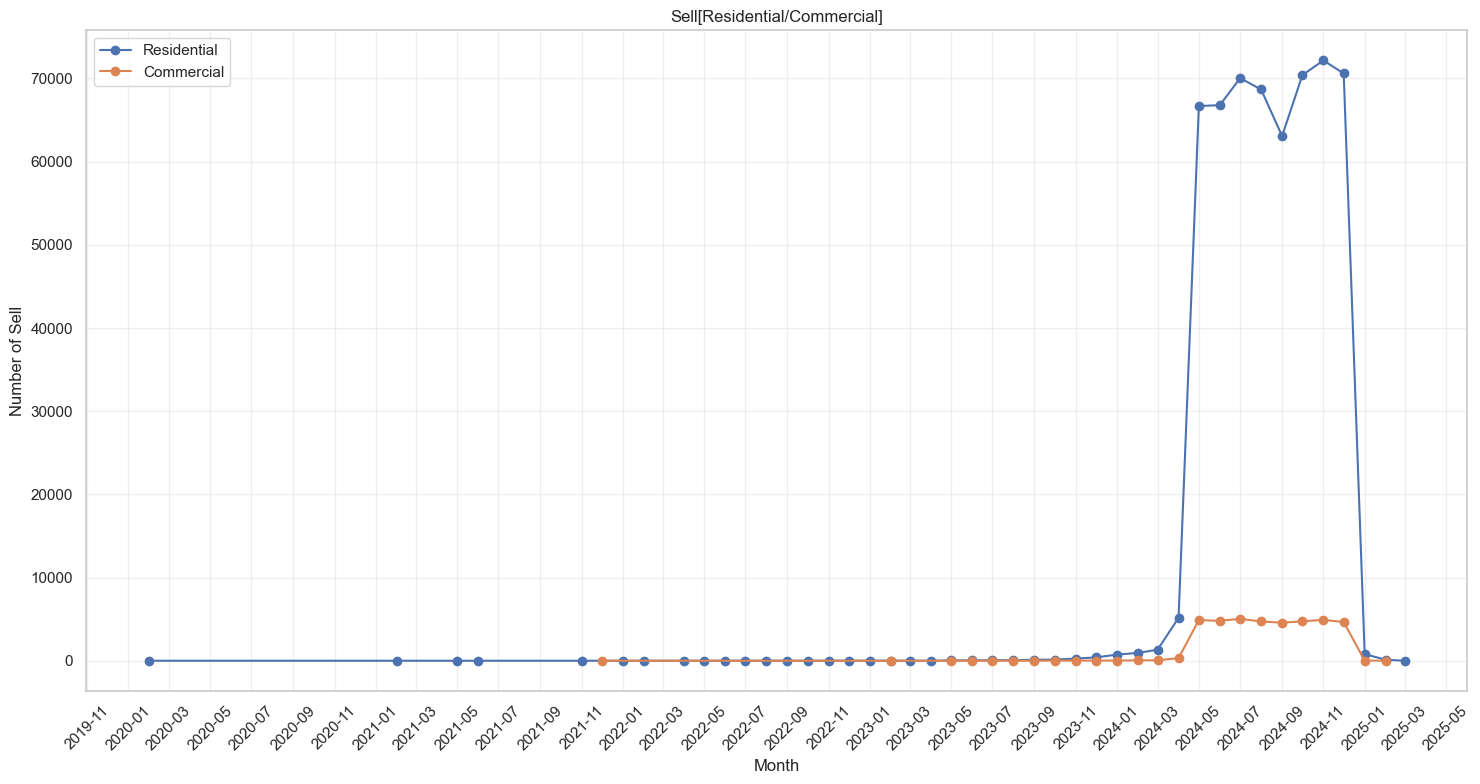

In [233]:
plt.figure(figsize=(15, 8))

plt.plot(res_sell.index, res_sell.values, marker='o', label='Residential')
plt.plot(com_sell.index, com_sell.values, marker='o', label='Commercial')

plt.xlabel('Month')
plt.ylabel('Number of Sell')
plt.title('Sell[Residential/Commercial]')
plt.xticks(rotation=45)
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

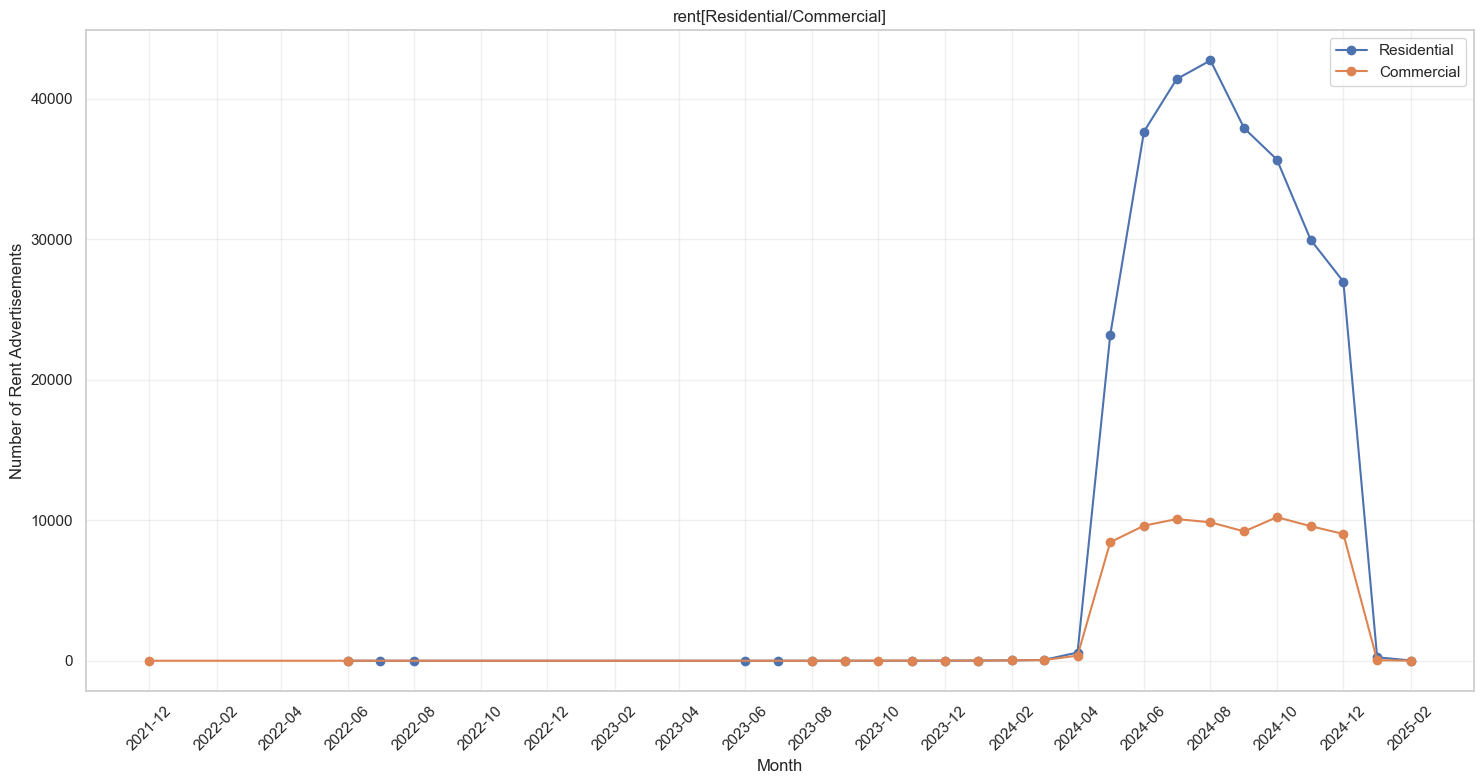

In [234]:
plt.figure(figsize=(15, 8))

plt.plot(res_rent.index, res_rent.values, marker='o', label='Residential')
plt.plot(com_rent.index, com_rent.values, marker='o', label='Commercial')

plt.xlabel('Month')
plt.ylabel('Number of Rent Advertisements')
plt.title('rent[Residential/Commercial]')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.show()

#### ۴. توزیع قیمت فروش بر اساس دسته‌بندی (cat3_slug)

حدود ۴۵۰ هزارتا مقدار price_value خالیه؛ این یه انتخاب طراحیه (بخاطر اجاره و بقیه نوع آگهیا)، پس فعلا دست‌نخورده نگهشون میداریم.

In [235]:
value_price_nonull = df.dropna(subset=['price_value'])
value_price_nonull['price_value'].isnull().sum()

np.int64(0)

از لگاریتم پایه ۱۰ قیمت استفاده کردیم که نمودار بهتر دیده بشه.

In [236]:
value_price_nonull['log_price'] = np.log10(value_price_nonull['price_value'])

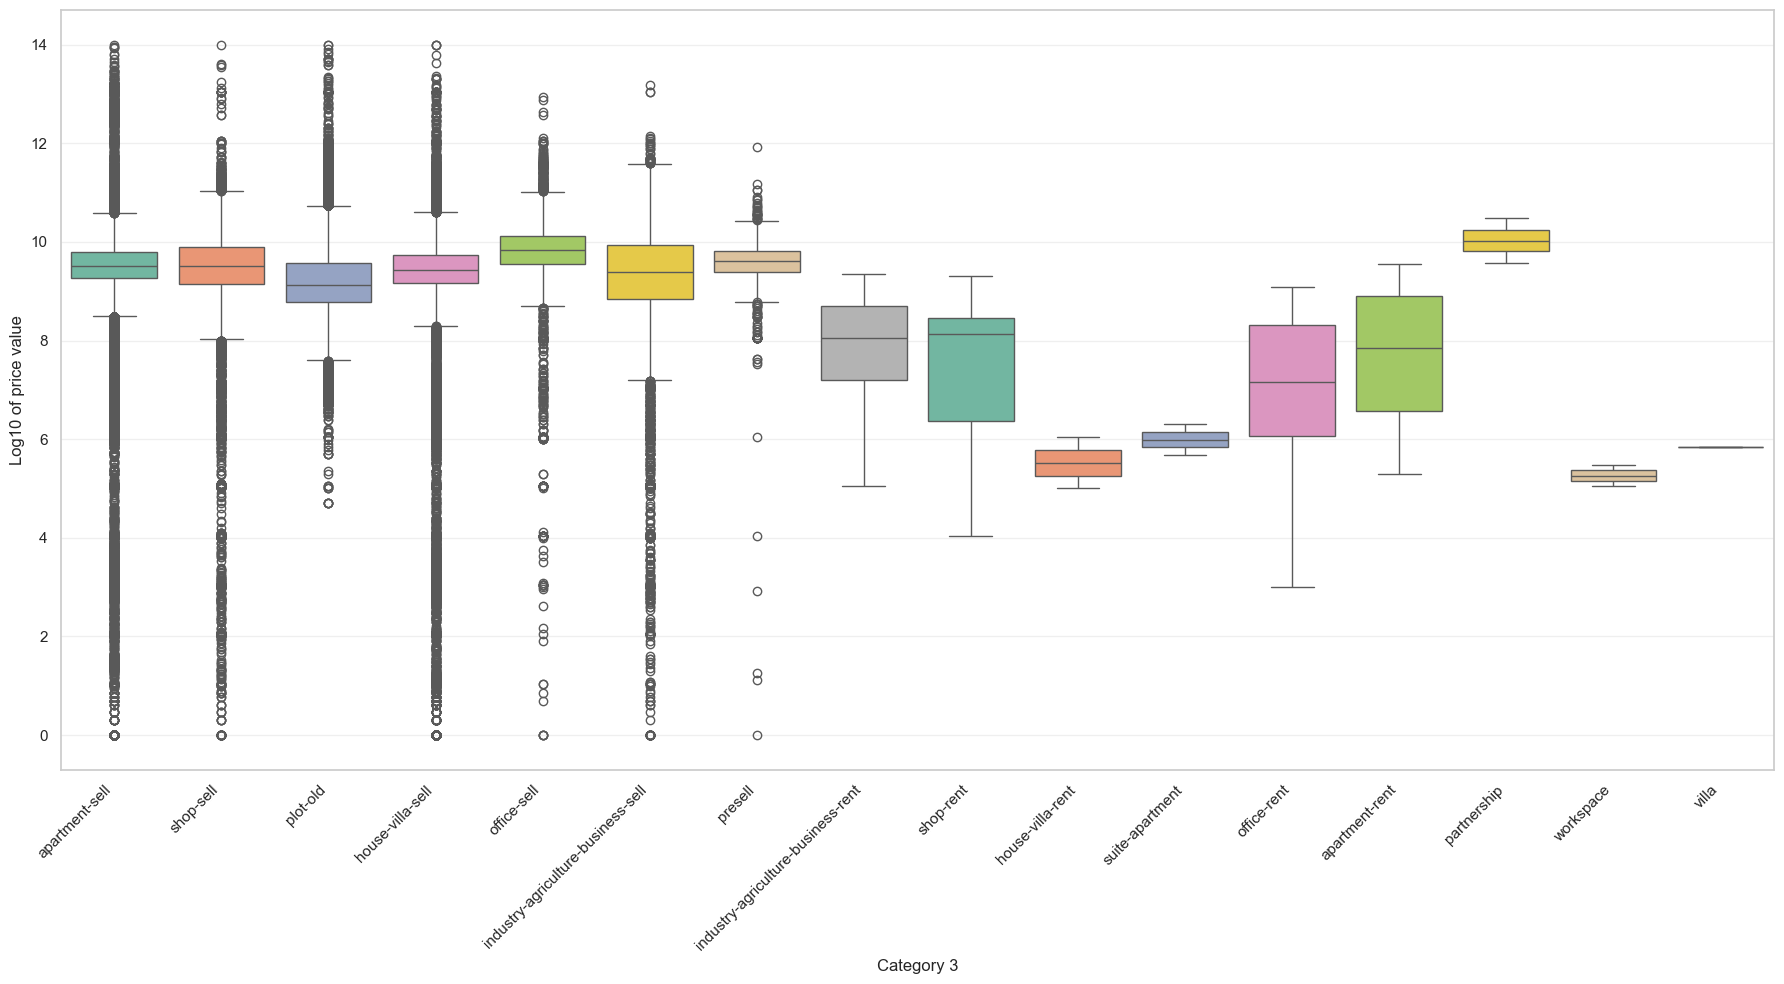

In [237]:
plt.figure(figsize=(18, 10))
sns.boxplot(
    data= value_price_nonull,
    x= 'cat3_slug',
    y= 'log_price',
    palette= 'Set2'
)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.ylabel('Log10 of price value')
plt.xlabel('Category 3')
plt.tight_layout()
plt.show()

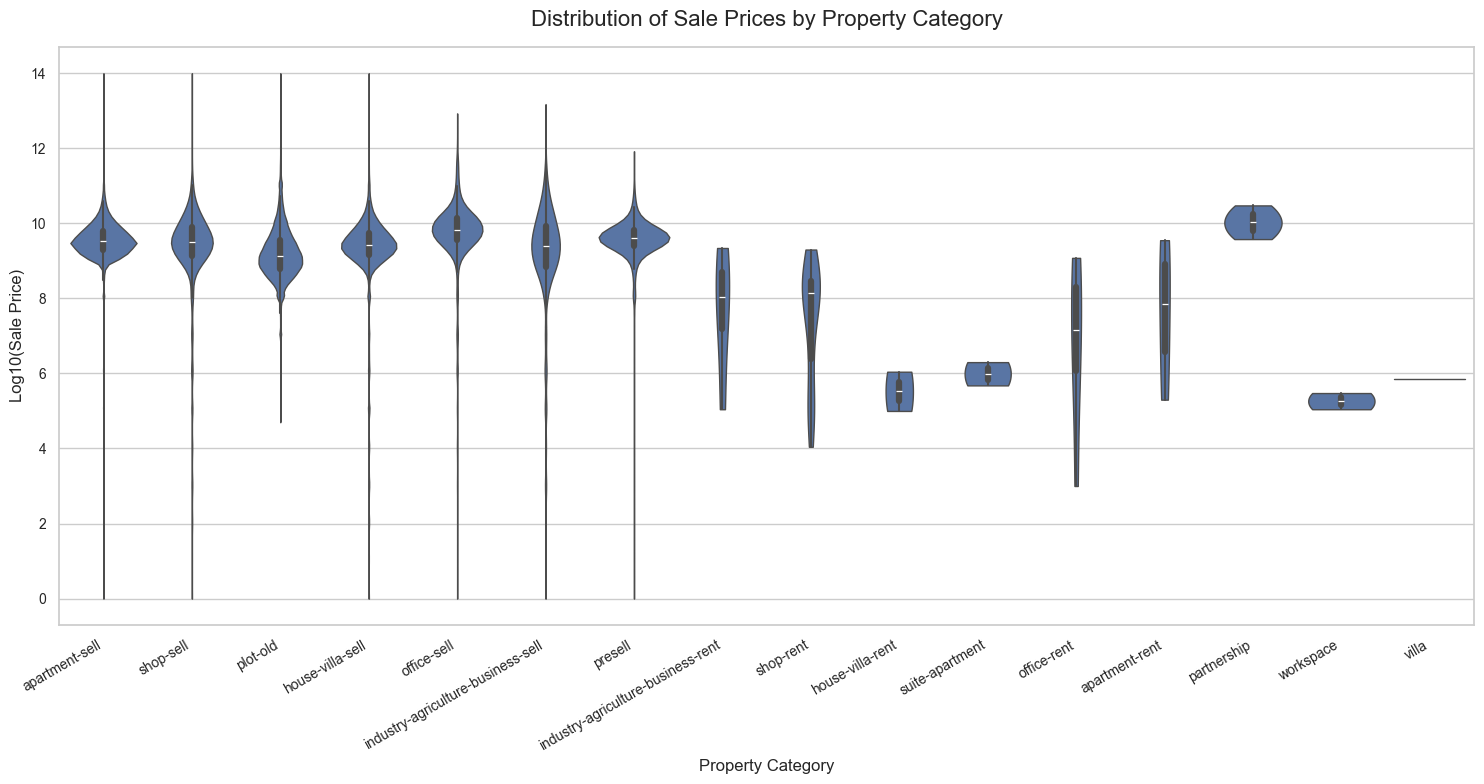

In [238]:
plt.figure(figsize=(15, 8))

sns.set_theme(style='whitegrid')

sns.violinplot(
    data=value_price_nonull,
    x='cat3_slug',
    y='log_price',
    inner='box',
    cut=0,
    linewidth=1
)

plt.title('Distribution of Sale Prices by Property Category', fontsize=16, pad=15)
plt.xlabel('Property Category', fontsize=12)
plt.ylabel('Log10(Sale Price)', fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#### ۵. نقشه‌ی حرارتی جغرافیایی آگهی‌ها

In [239]:
bad_locations = df[
    (df['location_latitude'] < 25) |
    (df['location_latitude'] > 40) |
    (df['location_longitude'] < 44) |
    (df['location_longitude'] > 64)
]

print(len(bad_locations)) # 47 locations are out of iran so we will remove them

47


344392 missing value for lat and lng

In [240]:
len(df[(df['location_latitude'].isna() == True) & (df['location_longitude'].isna() == True)]) # 344392 missing value for lat and lng

344392

In [241]:
geo_no_null = df[(df['location_latitude'].isna() == False) & (df['location_longitude'].isna() == False)].copy()

In [242]:
geo_no_null = geo_no_null[
    (geo_no_null['location_latitude'] >= 25) &
    (geo_no_null['location_latitude'] <= 40) &
    (geo_no_null['location_longitude'] >= 44) &
    (geo_no_null['location_longitude'] <= 64)
]
len(geo_no_null)

655561

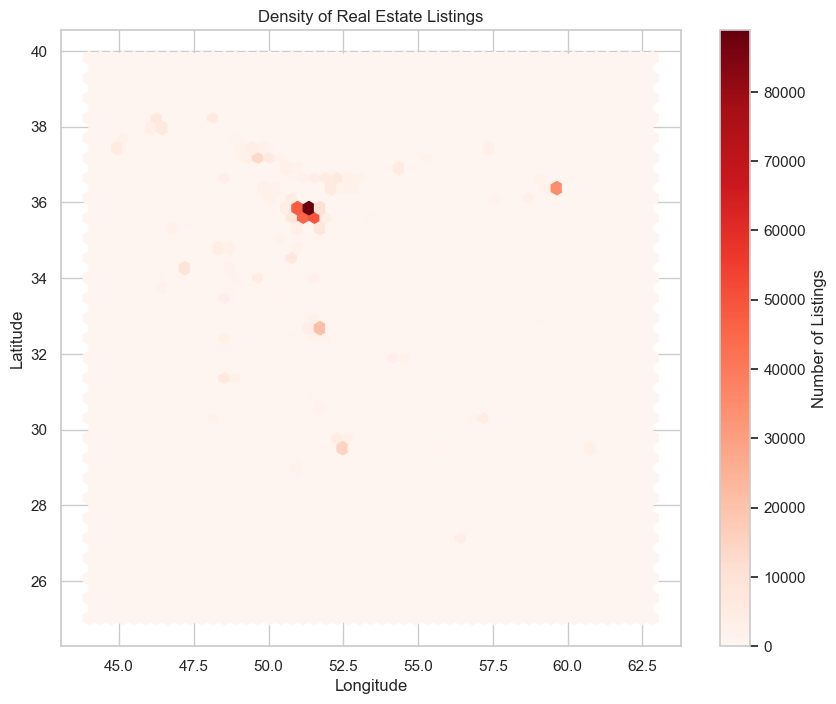

In [243]:
plt.figure(figsize=(10, 8))

plt.hexbin(
    geo_no_null['location_longitude'],
    geo_no_null['location_latitude'],
    gridsize=50,
    cmap='Reds'
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Density of Real Estate Listings')

plt.colorbar(label='Number of Listings')
plt.show()

In [244]:
m = folium.Map(
    location=[
        geo_no_null['location_latitude'].mean(),
        geo_no_null['location_longitude'].mean()
    ],
    zoom_start=11
)

In [245]:
"""heat_data = geo_no_null[
    ['location_latitude', 'location_longitude']
].values.tolist()

HeatMap(heat_data).add_to(m)

m"""

"heat_data = geo_no_null[\n    ['location_latitude', 'location_longitude']\n].values.tolist()\n\nHeatMap(heat_data).add_to(m)\n\nm"

> **نکته:** کد HeatMap مربوط به folium بالا عمدا کامنت شده که فقط نمودار hexbin فعال بمونه؛ نقشه پایه‌ی folium (متغیر m) ساخته شده ولی هیچ لایه حرارتی روش اضافه نشده.

<div dir="rtl" style="text-align:right">

#### ۶. روند میانگین اجاره در ماه‌های شمسی


</div>

In [246]:
# ده تا بزرگ‌ترین مقدار اجاره
df['rent_value'].sort_values(ascending=False).head(10)

463475    1.000000e+15
235489    1.000000e+15
340850    1.000000e+15
149254    8.888889e+14
906064    3.333333e+14
554385    3.333333e+14
538272    2.222222e+14
577251    1.444146e+14
881457    1.200000e+14
358419    1.111111e+14
Name: rent_value, dtype: float64

In [247]:
# صدک‌های بالایی اجاره
df['rent_value'].quantile([0.98,0.985,0.99,0.995, 0.999, 0.9999, 1.0])

0.9800    1.200000e+08
0.9850    1.500000e+08
0.9900    2.200000e+08
0.9950    4.000000e+08
0.9990    1.111111e+10
0.9999    1.111111e+14
1.0000    1.000000e+15
Name: rent_value, dtype: float64

In [248]:
# صدک‌های پایین (فقط مقدارهای مثبت)
df[df['rent_value'] > 0]['rent_value'].quantile([0.0001, 0.001, 0.01, 0.05])

0.0001     50000.0
0.0010    100000.0
0.0100    100000.0
0.0500    100000.0
Name: rent_value, dtype: float64

In [249]:
# NANفقط اجاره‌ی بین ۱۰۰ هزار و ۵۰۰ میلیون تومان می‌مونه، بقیه می‌شه 
df['rent_value_clean'] = df['rent_value'].where(
    (df['rent_value'] >= 100_000) & (df['rent_value'] <= 500_000_000)
)

In [250]:
# چند تا داده حذف شد؟
print("Number of removed rows:", df['rent_value_clean'].isnull().sum() - df['rent_value'].isnull().sum())
print(df['rent_value_clean'].describe())

Number of removed rows: 60712
count    2.906100e+05
mean     1.626538e+07
std      3.566265e+07
min      1.000000e+05
25%      3.000000e+06
50%      6.000000e+06
75%      1.500000e+07
max      5.000000e+08
Name: rent_value_clean, dtype: float64


In [251]:
# میانگین اجاره توی هر ماه شمسی
rent_mean_m = (
    df.dropna(subset=['created_at_month_jalali', 'rent_value_clean'])
      .groupby('created_at_month_jalali')['rent_value_clean']
      .mean()
      .sort_index()
)
print(rent_mean_m)

created_at_month_jalali
1401-03    3.503333e+07
1401-04    4.500000e+07
1401-05    7.000000e+07
1402-05    6.500000e+07
1402-06    2.250000e+07
1402-07    4.558333e+07
1402-08    5.855000e+07
1402-09    3.491818e+07
1402-10    3.983081e+07
1402-11    2.895076e+07
1402-12    3.352450e+07
1403-01    3.138132e+07
1403-02    1.861312e+07
1403-03    1.468331e+07
1403-04    1.481116e+07
1403-05    1.474970e+07
1403-06    1.507850e+07
1403-07    1.697787e+07
1403-08    1.788241e+07
1403-09    1.884002e+07
1403-10    4.253367e+07
1403-11    3.390062e+07
Name: rent_value_clean, dtype: float64


<div dir="rtl" align="right">

«ماه‌های ۰۶-۱۴۰۱ تا ۰۴-۱۴۰۲ در این نمودار حضور ندارند، چون در این بازه، آگهی‌های ثبت‌شده به‌قدری کم بوده‌اند که پس از حذف مقادیر نامعتبر اجاره (صفر، یا خارج از بازه‌ی معقول)، هیچ داده‌ی معتبری برای محاسبه‌ی میانگین باقی نمانده است.»

</div>

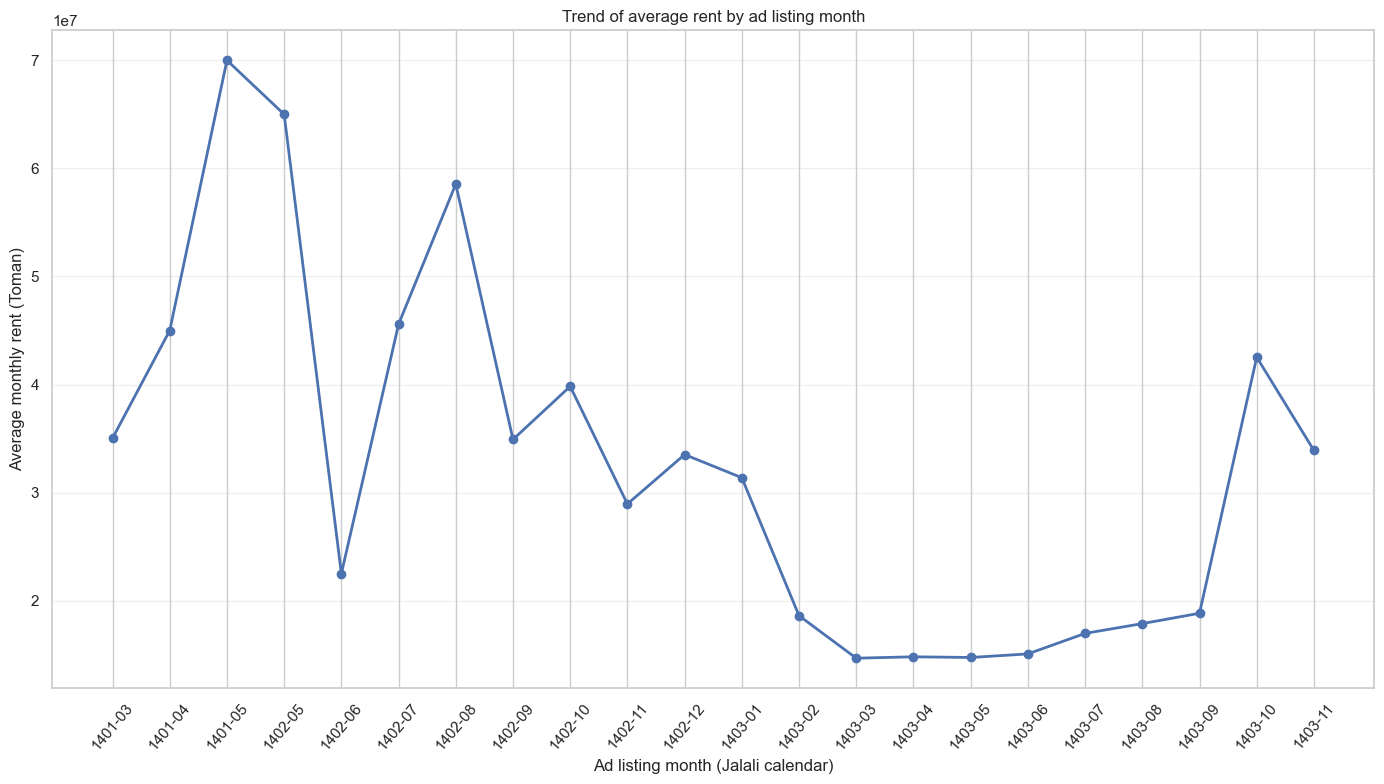

In [252]:
# نمودار میانگین اجاره
plt.figure(figsize=(14,8))
plt.plot(rent_mean_m.index, rent_mean_m.values, marker='o', linewidth=2)
plt.xlabel('Ad listing month (Jalali calendar)')
plt.ylabel('Average monthly rent (Toman)')
plt.title('Trend of average rent by ad listing month')
plt.xticks(rotation=50)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">
نوسانات شدید میانگین در بازه‌ی ۱۴۰۱ تا اواخر ۱۴۰۲ عمدتاً ناشی از حجم بسیار کم آگهی‌های ثبت‌شده در آن ماه‌ها (بین ۱ تا حدود صد آگهی) است، نه یک تغییر واقعی بازار؛ روند قابل‌اتکاتر از ماه ۰۲-۱۴۰۳ به بعد قابل مشاهده است، جایی که هر ماه دارای ده‌ها هزار مشاهده است
</div>

In [253]:
# همین کار با میانه
rent_median_m = (
    df.dropna(subset=['created_at_month_jalali', 'rent_value_clean'])
      .groupby('created_at_month_jalali')['rent_value_clean']
      .median()
      .sort_index()
)
print(rent_median_m)

created_at_month_jalali
1401-03    30000000.0
1401-04    45000000.0
1401-05    70000000.0
1402-05    65000000.0
1402-06    22500000.0
1402-07    15750000.0
1402-08    23500000.0
1402-09    25000000.0
1402-10    16500000.0
1402-11    15000000.0
1402-12    15500000.0
1403-01    12000000.0
1403-02     7000000.0
1403-03     6000000.0
1403-04     6000000.0
1403-05     6000000.0
1403-06     6000000.0
1403-07     7000000.0
1403-08     7000000.0
1403-09     7000000.0
1403-10    21000000.0
1403-11    16000000.0
Name: rent_value_clean, dtype: float64


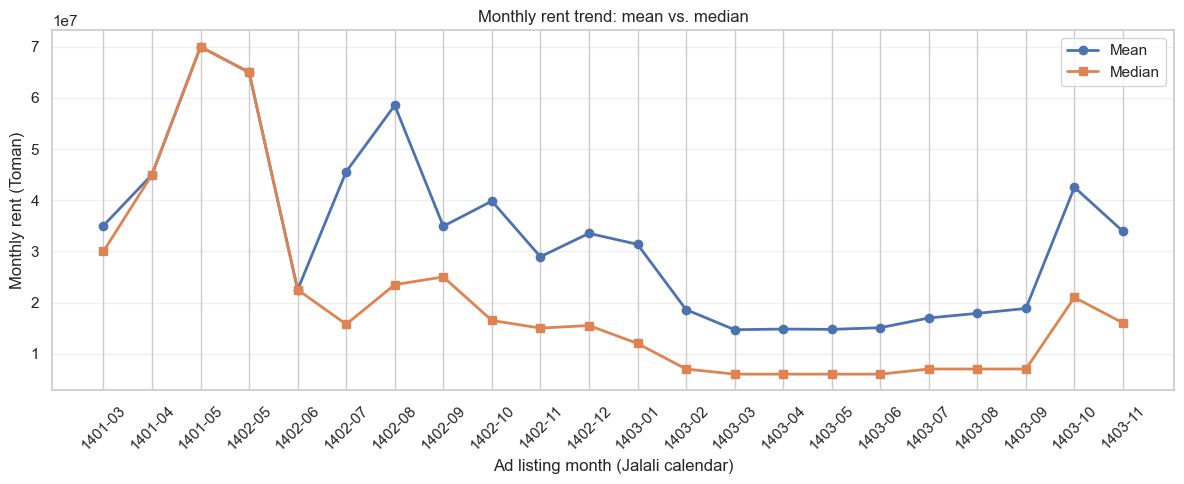

In [254]:
# میانگین و میانه کنار هم
plt.figure(figsize=(12, 5))
plt.plot(rent_mean_m.index, rent_mean_m.values, marker='o', linewidth=2, label='Mean')
plt.plot(rent_median_m.index, rent_median_m.values, marker='s', linewidth=2, label='Median')
plt.xlabel('Ad listing month (Jalali calendar)')
plt.ylabel('Monthly rent (Toman)')
plt.title('Monthly rent trend: mean vs. median')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right">

این نمودار میانگین و میانه‌ی اجاره‌ی ماهانه را در برابر هم نشان می‌دهد. در تمام ماه‌ها، خط میانگین بالاتر خط میانه قرار دارد — این فاصله در برخی ماه‌ها (مثل ۰۸-۱۴۰۲، با میانگین ۵۸.۶ میلیون در برابر میانه‌ی ۲۳.۵ میلیون) به بیش از دو برابر می‌رسد. این اختلاف پایدار نشان‌دهنده‌ی یک توزیع چوله به راست است: اکثریت آگهی‌ها اجاره‌ی نسبتاً پایینی دارند، در حالی که یک اقلیت کوچک خانه‌های گران‌قیمت، میانگین را به‌طور قابل توجهی بالاتر می‌کشد. به همین دلیل، میانه معیار قابل‌اعتمادتری برای توصیف «اجاره‌ی معمول بازار» است. همچنین، نوسانات شدید هر دو خط در بازه‌ی ۱۴۰۱ تا اواخر ۱۴۰۲ ناشی از حجم بسیار کم آگهی‌های ثبت‌شده در آن ماه‌ها (اغلب کمتر از صد آگهی) است، نه یک تغییر واقعی بازار؛ روند قابل اتکاتر از ماهِ ۰۲-۱۴۰۳ به بعد دیده می‌شود که هر ماه ده‌ها هزار مشاهده دارد و هر دو خط به‌طورِ پایدار همگرا و باثبات‌تر می‌شوند. ماه‌های ۰۶-۱۴۰۱ تا ۰۴-۱۴۰۲ در نمودار حضور ندارند، چون پس از حذف مقادیر نامعتبر اجاره، هیچ داده‌ی معتبری برای این بازه باقی نمانده بود.

</div>

<div dir="rtl" style="text-align:right">

#### ۷. قیمت حقیقی (حذف اثر تورم)



</div>

<div dir="rtl" style="text-align:right">

فقط آگهی‌های فروش مسکونی با قیمت مقطوع رو برمی‌داریم، چون توی حالت توافقی یا مجانی `price_value` قیمت واقعی نیست. اول توزیع قیمت خام رو نگاه می‌کنیم.

</div>

In [255]:
# فروش مسکونی با قیمت مقطوع
sale_mask = (df['cat2_slug'] == 'residential-sell') & (df['price_mode'] == 'مقطوع')

print("Number of residential-sale ads with a fixed price:", sale_mask.sum())
print("Rows with price_value:", df[sale_mask]['price_value'].notnull().sum())
print("Rows without price_value:", df[sale_mask]['price_value'].isnull().sum())

Number of residential-sale ads with a fixed price: 533261
Rows with price_value: 533261
Rows without price_value: 0


In [256]:
# توزیع قیمت خام
print(df[sale_mask]['price_value'].describe())
print()
print(df[sale_mask]['price_value'].quantile([0.001, 0.01, 0.05, 0.95, 0.99, 0.999, 1.0]))

count    5.332610e+05
mean     1.695065e+10
std      5.806223e+11
min      1.000000e+00
25%      1.420000e+09
50%      2.800000e+09
75%      5.800000e+09
max      1.000000e+14
Name: price_value, dtype: float64

0.001    1.000000e+01
0.010    1.111110e+05
0.050    3.100000e+08
0.950    2.000000e+10
0.990    7.965000e+10
0.999    1.111111e+12
1.000    1.000000e+14
Name: price_value, dtype: float64


<div dir="rtl" style="text-align:right">

دو تا مشکل توی قیمت‌ها هست: مقدارهای خیلی کوچیک (چند صد هزار تا چند میلیون تومان، احتمالاً اشتباه تایپی) و مقدارهای نجومی (تا ۱۰۰ هزار میلیارد که چند بار دقیقاً تکرار شده). برش درصدی کافی نبود، پس بازه‌ی ۱۰۰ میلیون تا ۱ هزار میلیارد تومان رو نگه داشتیم.

</div>

In [257]:
# قیمت معتبر: بین ۱۰۰ میلیون و ۱ هزار میلیارد تومان
df['price_value_clean'] = df['price_value'].where(
    sale_mask & (df['price_value'] >= 100_000_000) & (df['price_value'] <= 1_000_000_000_000)
)

In [258]:
# قبل و بعد از پاک‌سازی
print("Count before cleaning:", sale_mask.sum())
print("Count after cleaning: ", df['price_value_clean'].notnull().sum())
print(df['price_value_clean'].describe())

Count before cleaning: 533261
Count after cleaning:  519936
count    5.199360e+05
mean     6.846423e+09
std      2.362146e+10
min      1.000000e+08
25%      1.500000e+09
50%      2.900000e+09
75%      5.900000e+09
max      1.000000e+12
Name: price_value_clean, dtype: float64


In [259]:
# سال شمسی رو از ماه شمسی درمیاریم (چهار رقم اول)
df['created_at_year_jalali'] = df['created_at_month_jalali'].str.slice(0, 4)

In [260]:
# میانگین و میانه‌ی قیمت و تعداد آگهی برای هر سال
year_price = (
    df.dropna(subset=['created_at_year_jalali', 'price_value_clean'])
      .groupby('created_at_year_jalali')['price_value_clean']
      .agg(nominal_mean='mean', nominal_median='median', n='count')
)
year_price = year_price.loc[['1400', '1401', '1402', '1403']]
year_price

,nominal_mean,nominal_median,n
created_at_year_jalali,,,
1400,1.066667e+09,1.200000e+09,3
1401,1.787790e+10,2.325000e+09,46
1402,7.606310e+09,2.700000e+09,3903
1403,6.839685e+09,2.900000e+09,515983


<div dir="rtl" style="text-align:right">
همان‌طور که در بخش روند اجاره‌ی ماهانه هم دیدیم، مجموعه‌داده تقریباً
به‌طور کامل مربوط به سال ۱۴۰۳ است (بیش از ۵۱۲ هزار آگهی)، در حالی‌که سال‌های ۱۴۰۰ و ۱۴۰۱ به‌ترتیب
تنها ۳ و ۴۲ آگهی فروش مسکونی معتبر دارند. بنابراین میانگین/میانه‌ی این دو سال از نظر آماری قابل اتکا
نیست و هرگونه نتیجه‌گیری دربارهی روند قیمت حقیقی باید عمدتاً بر مبنای مقایسه‌ی ۱۴۰۲ در برابر ۱۴۰۳
باشد که هر دو نمونه‌ی به‌مراتب بزرگ‌تری دارند؛ مقادیر ۱۴۰۰ و ۱۴۰۱ فقط برای کامل‌بودن نمودار گزارش
می‌شوند.
</div>

<div dir="rtl" style="text-align:right">

##### فرمول تعدیل تورم

اول شاخص قیمت مصرف‌کننده (CPI) رو با پایه‌ی ۱۴۰۰ می‌سازیم ($CPI_{1400}=100$):

$$CPI_t = CPI_{t-1} \times (1 + \text{نرخ تورم}_t)$$

بعد قیمت هر سال رو به «تومانِ ۱۴۰۰» برمی‌گردونیم:

$$\text{قیمت حقیقی}_t = \text{قیمت اسمی}_t \times \dfrac{CPI_{1400}}{CPI_t}$$

نرخ تورم سالانه (مرکز آمار ایران، amar.org.ir):

| سال | نرخ تورم |
|---|---|
| ۱۴۰۰ | ۴۰٫۲٪ |
| ۱۴۰۱ | ۴۵٫۸٪ |
| ۱۴۰۲ | ۴۰٫۷٪ |
| ۱۴۰۳ | ۳۲٫۵٪ |

</div>

In [261]:
# شاخص قیمت (پایه ۱۴۰۰) و قیمت حقیقی = قیمت اسمی × CPI۱۴۰۰ / CPI سال
infl = {1400: 0.402, 1401: 0.458, 1402: 0.407, 1403: 0.325}

base_year = 1400
cpi = {base_year: 100.0}
for y in range(base_year + 1, 1404):
    cpi[y] = cpi[y - 1] * (1 + infl[y])

year_price['cpi'] = [cpi[int(y)] for y in year_price.index]
year_price['real_mean'] = year_price['nominal_mean'] * (cpi[base_year] / year_price['cpi'])
year_price['real_median'] = year_price['nominal_median'] * (cpi[base_year] / year_price['cpi'])
year_price['Nominal growth %'] = year_price['nominal_mean'].pct_change() * 100
year_price['Real growth %'] = year_price['real_mean'].pct_change() * 100

year_price.round(2)

,nominal_mean,nominal_median,n,cpi,real_mean,real_median,Nominal growth %,Real growth %
created_at_year_jalali,,,,,,,,
1400,1.066667e+09,1.200000e+09,3,100.00,1.066667e+09,1.200000e+09,NaN,NaN
1401,1.787790e+10,2.325000e+09,46,145.80,1.226193e+10,1.594650e+09,1576.05,1049.56
1402,7.606310e+09,2.700000e+09,3903,205.14,3.707852e+09,1.316170e+09,-57.45,-69.76
1403,6.839685e+09,2.900000e+09,515983,271.81,2.516336e+09,1.066917e+09,-10.08,-32.13


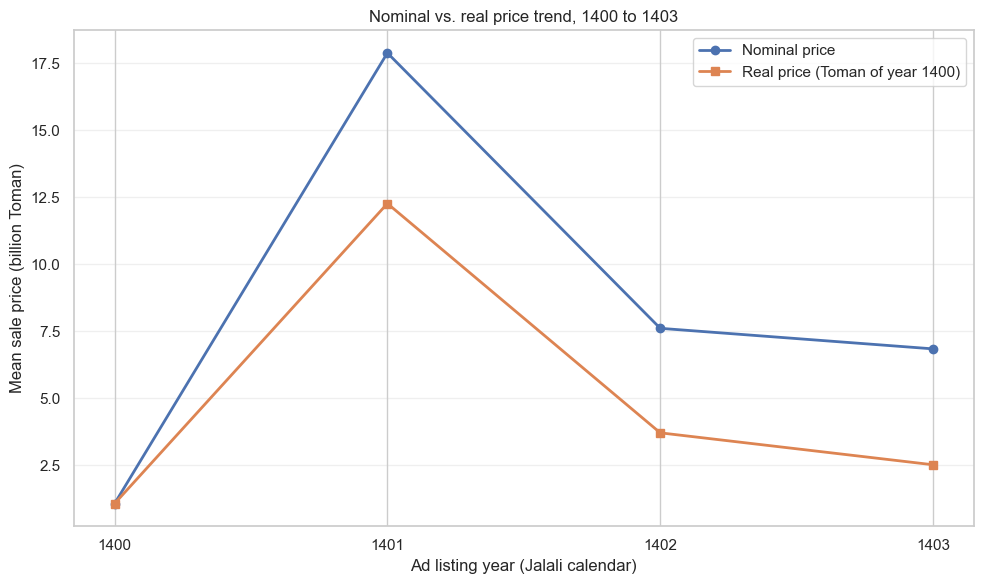

In [262]:
# نمودار قیمت اسمی و حقیقی
plt.figure(figsize=(10, 6))
plt.plot(year_price.index, year_price['nominal_mean'] / 1e9, marker='o', linewidth=2, label='Nominal price')
plt.plot(year_price.index, year_price['real_mean'] / 1e9, marker='s', linewidth=2,
         label=f'Real price (Toman of year {base_year})')
plt.xlabel('Ad listing year (Jalali calendar)')
plt.ylabel('Mean sale price (billion Toman)')
plt.title('Nominal vs. real price trend, 1400 to 1403')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right">

##### نتیجه

از ۱۴۰۲ به ۱۴۰۳ میانگین قیمت اسمی حدود ۱۰٪ کم شده، ولی قیمت حقیقی حدود ۳۲٪ پایین اومده؛ یعنی قیمت ملک از تورم عقب مونده. جهش ۱۴۰۰ به ۱۴۰۱ رو نمی‌شه تفسیر کرد چون فقط ۳ و ۴۶ آگهی داریم.

</div>

#### ۸. ماتریس همبستگی

از ستون rooms_count_num که توی بخش ۱ ساختیم استفاده میکنه (کدگذاری عددی تعداد اتاق و امکانات).

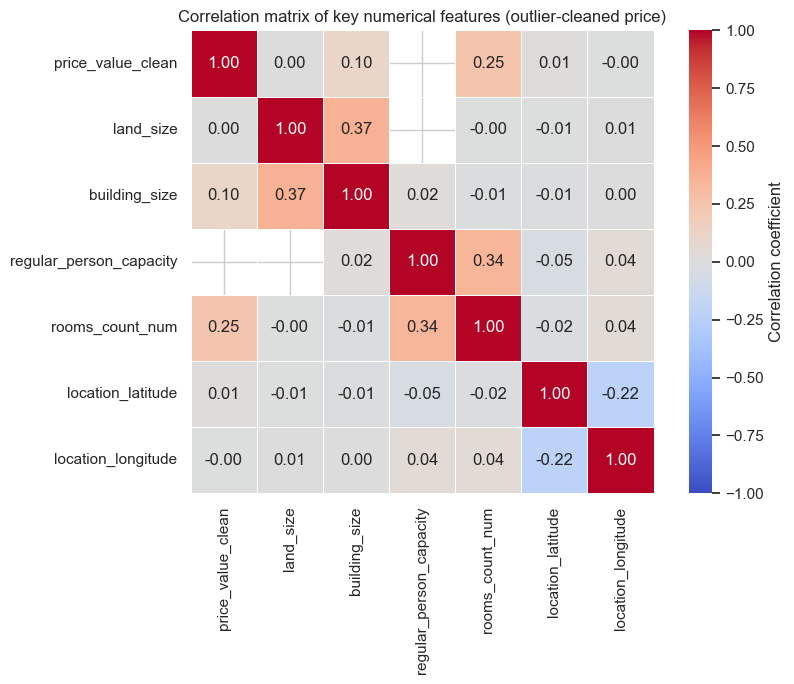

                         price_value_clean  land_size  building_size  \
price_value_clean                     1.00       0.00           0.10   
land_size                             0.00       1.00           0.37   
building_size                         0.10       0.37           1.00   
regular_person_capacity                NaN        NaN           0.02   
rooms_count_num                       0.25      -0.00          -0.01   
location_latitude                     0.01      -0.01          -0.01   
location_longitude                   -0.00       0.01           0.00   

                         regular_person_capacity  rooms_count_num  \
price_value_clean                            NaN             0.25   
land_size                                    NaN            -0.00   
building_size                               0.02            -0.01   
regular_person_capacity                     1.00             0.34   
rooms_count_num                             0.34             1.00   
location_

In [263]:
cols_corr = ["price_value_clean", "land_size", "building_size",
             "regular_person_capacity", "rooms_count_num",
             "location_latitude", "location_longitude"]

corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation coefficient"})
plt.title("Correlation matrix of key numerical features (outlier-cleaned price)")
plt.tight_layout()
plt.show()

print(corr_matrix.round(2))
print(df[cols_corr].notna().sum())

#### ۹. امکانات بر اساس منطقه

از ستون‌های _num مربوط به امکانات که توی بخش ۱ ساختیم استفاده میکنه.

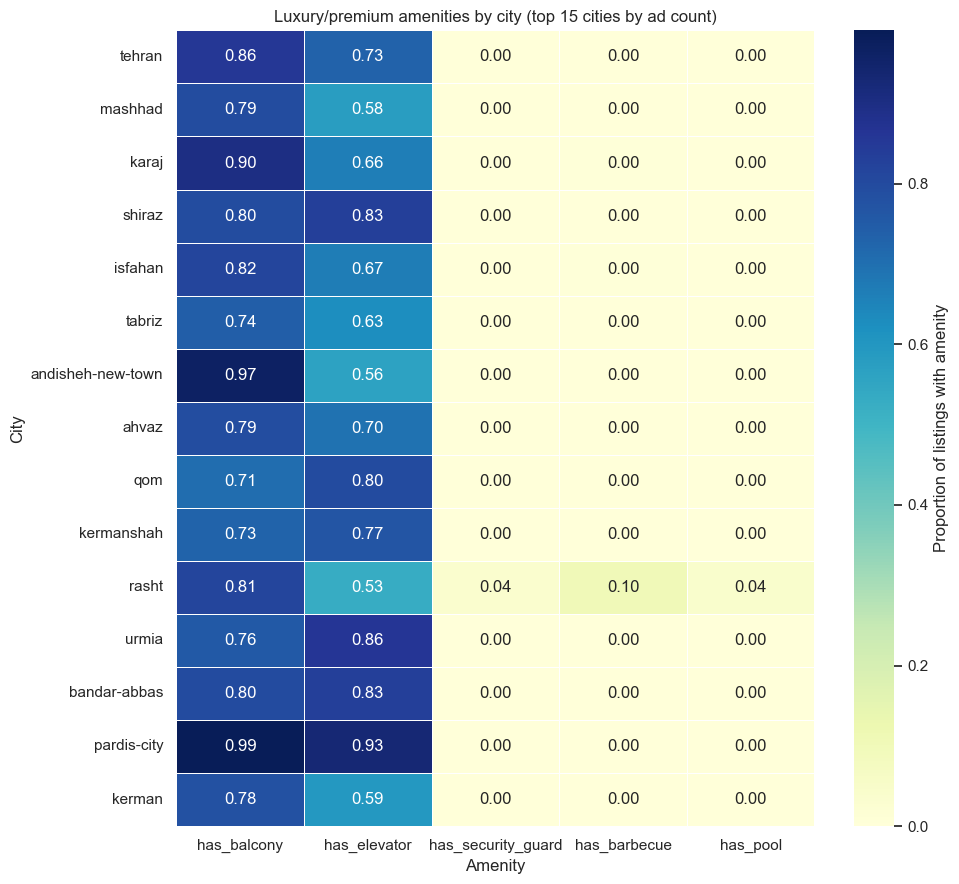

                   has_balcony  has_elevator  has_security_guard  \
city_slug                                                          
tehran                    0.86          0.73                0.00   
mashhad                   0.79          0.58                0.00   
karaj                     0.90          0.66                0.00   
shiraz                    0.80          0.83                0.00   
isfahan                   0.82          0.67                0.00   
tabriz                    0.74          0.63                0.00   
andisheh-new-town         0.97          0.56                0.00   
ahvaz                     0.79          0.70                0.00   
qom                       0.71          0.80                0.00   
kermanshah                0.73          0.77                0.00   
rasht                     0.81          0.53                0.04   
urmia                     0.76          0.86                0.00   
bandar-abbas              0.80          0.83    

In [264]:
amenities_num = [c + "_num" for c in amenities]
amenity_by_city = df.groupby("city_slug")[amenities_num].mean()
amenity_by_city.columns = amenities

top_cities = df["city_slug"].value_counts().head(15).index
amenity_by_city = amenity_by_city.loc[top_cities]
amenity_by_city = amenity_by_city.dropna(how="all")

plt.figure(figsize=(10, 9))
sns.heatmap(amenity_by_city, annot=True, fmt=".2f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "Proportion of listings with amenity"})
plt.title("Luxury/premium amenities by city (top 15 cities by ad count)")
plt.xlabel("Amenity")
plt.ylabel("City")
plt.tight_layout()
plt.show()

print(amenity_by_city.round(2))

### آزمون فرض

#### ۱. کلان‌شهر در برابر شهر کوچک (متراژ مسکونی)

In [265]:
city_class.columns

Index(['نام شهر', 'دسته‌بندی'], dtype='object')

In [266]:
if 'دسته‌بندی' not in df.columns:
    df = df.merge(
        city_class,
        left_on='city_slug',
        right_on='نام شهر',
        how='left'
    )

print(df['دسته‌بندی'].value_counts(dropna=False))

دسته‌بندی
شهر کوچک    498478
کلان‌شهر    464800
NaN          36722
Name: count, dtype: int64


In [267]:
residential_area = df[
    df['cat2_slug'].isin(['residential-sell', 'residential-rent'])
].dropna(subset=['building_size', 'دسته‌بندی', 'نام شهر']).copy()

residential_area = residential_area[
    residential_area['building_size'].between(20, 2000)
].copy()

print('Residential listings used:', len(residential_area))

Residential listings used: 789395


In [268]:
city_means = residential_area.groupby(
    ['نام شهر', 'دسته‌بندی'], as_index=False
)['building_size'].mean()

metro = city_means.loc[
    city_means['دسته‌بندی'] == 'کلان‌شهر', 'building_size'
]
small = city_means.loc[
    city_means['دسته‌بندی'] == 'شهر کوچک', 'building_size'
]

print('Metropolitan cities:', len(metro))
print('Small cities:', len(small))

city_stats = city_means.groupby('دسته‌بندی')['building_size'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
print(city_stats.round(2))

Metropolitan cities: 9
Small cities: 231
           count    mean  median    std     min     max
دسته‌بندی                                              
شهر کوچک     231  220.42  205.73  72.13   80.51  547.16
کلان‌شهر       9  152.38  143.89  24.92  115.79  197.53


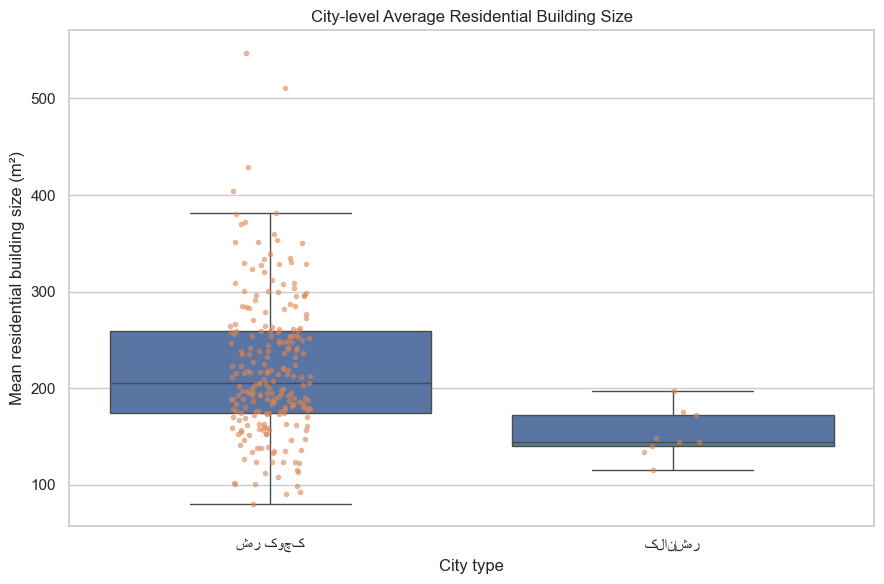

In [269]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=city_means,
    x='دسته‌بندی',
    y='building_size',
    showfliers=False
)
sns.stripplot(
    data=city_means,
    x='دسته‌بندی',
    y='building_size',
    size=4,
    alpha=0.6
)

plt.xlabel('City type')
plt.ylabel('Mean residential building size (m²)')
plt.title('City-level Average Residential Building Size')
plt.tight_layout()
plt.show()

In [270]:
ALPHA = 0.05

observed_difference = metro.mean() - small.mean()

welch = stats.ttest_ind(
    metro,
    small,
    equal_var=False,
    alternative='less'
)

print(f'Mean (metropolitan): {metro.mean():.2f} m²')
print(f'Mean (small cities): {small.mean():.2f} m²')
print(f'Observed difference (metro - small): {observed_difference:.2f} m²')
print(f"Welch t-test: t={welch.statistic:.3f}, p={welch.pvalue:.4g}")

Mean (metropolitan): 152.38 m²
Mean (small cities): 220.42 m²
Observed difference (metro - small): -68.04 m²
Welch t-test: t=-7.113, p=2.589e-06


In [271]:
rng = np.random.default_rng(42)
pooled = np.concatenate([metro.to_numpy(), small.to_numpy()])
observed = observed_difference
permutation_differences = np.empty(10000)

for i in range(10000):
    shuffled = rng.permutation(pooled)
    permutation_differences[i] = (
        shuffled[:len(metro)].mean() -
        shuffled[len(metro):].mean()
    )

permutation_p = (np.sum(permutation_differences <= observed) + 1) / (len(permutation_differences) + 1)

print(f'Permutation test p-value: {permutation_p:.4g}')

Permutation test p-value: 0.0007999


In [272]:
# 95% bootstrap confidence interval for the difference in city-level means
bootstrap_differences = np.empty(10000)

for i in range(10000):
    metro_sample = rng.choice(metro.to_numpy(), size=len(metro), replace=True)
    small_sample = rng.choice(small.to_numpy(), size=len(small), replace=True)
    bootstrap_differences[i] = metro_sample.mean() - small_sample.mean()

ci_low, ci_high = np.percentile(bootstrap_differences, [2.5, 97.5])
print(f'Observed mean difference: {observed_difference:.2f} m²')
print(f'95% bootstrap CI: [{ci_low:.2f}, {ci_high:.2f}] m²')

Observed mean difference: -68.04 m²
95% bootstrap CI: [-85.27, -50.17] m²


In [273]:
u_stat, p_mw = stats.mannwhitneyu(
    metro,
    small,
    alternative='less'
)

print(f'Mann-Whitney U: U={u_stat:,.1f}, p={p_mw:.4g}')
print()
print('Decision at alpha=0.05:')
print('Welch test:', 'evidence for H1' if welch.pvalue < ALPHA else 'insufficient evidence for H1')
print('Permutation test:', 'evidence for H1' if permutation_p < ALPHA else 'insufficient evidence for H1')

Mann-Whitney U: U=350.0, p=0.0003733

Decision at alpha=0.05:
Welch test: evidence for H1
Permutation test: evidence for H1


<div dir="rtl" style="text-align:right">

#### ۲. خونه‌های قدیمی یا جدید؟

<sub>در نوشتن کد این بخش از هوش مصنوعی کمک گرفته شده.</sub>

</div>

<div dir="rtl" style="text-align:right">

##### «قدیما خونه‌ها دلبازتر بود!»

فرضیه: میانگین زیربنای خونه‌های ساخت قبل از ۱۳۹۶ از خونه‌های ۱۳۹۶ به بعد بیشتره. فقط آگهی‌های مسکونی (فروش و اجاره) رو نگه می‌داریم و ردیف‌هایی که سال ساخت یا متراژ ندارن رو حذف می‌کنیم.

</div>

In [274]:
# فقط آگهی‌های مسکونی، بدون سال ساخت یا متراژ خالی
res_mask = df['cat2_slug'].isin(['residential-sell', 'residential-rent'])

home_df = df.loc[res_mask].dropna(subset=['construction_year_numeric', 'building_size']).copy()
print("Count before cleaning the area:", len(home_df))

home_df['building_size'].describe()

Count before cleaning the area: 688108


count    6.881080e+05
mean     1.259930e+03
std      6.960077e+04
min      1.000000e+00
25%      7.500000e+01
50%      1.000000e+02
75%      1.320000e+02
max      1.000000e+07
Name: building_size, dtype: float64

<div dir="rtl" style="text-align:right">

متراژ کمتر از ۲۰ و بیشتر از ۲۰۰۰ متر رو نامعتبر حساب می‌کنیم و حذف می‌کنیم.

</div>

In [275]:
# متراژ نامعتبر حذف می‌شه (کمتر از ۲۰ یا بیشتر از ۲۰۰۰)
n_before = len(home_df)
home_df = home_df[(home_df['building_size'] >= 20) & (home_df['building_size'] <= 2000)]
print(f"Removed {n_before - len(home_df):,} rows with invalid area out of {n_before:,} rows")

Removed 4,909 rows with invalid area out of 688,108 rows


In [276]:
# دو گروه: قبل از ۱۳۹۶ و ۱۳۹۶ به بعد
cutoff_year = 1396

old = home_df.loc[home_df['construction_year_numeric'] < cutoff_year, 'building_size']
new = home_df.loc[home_df['construction_year_numeric'] >= cutoff_year, 'building_size']

print(f"Old-built group (<{cutoff_year}):  n={len(old):,}")
print(f"New-built group (>={cutoff_year}): n={len(new):,}")

pd.DataFrame({'Old-built': old.describe(), 'New-built': new.describe()}).round(2)

Old-built group (<1396):  n=337,024
New-built group (>=1396): n=346,175


,Old-built,New-built
count,337024.00,346175.00
mean,106.42,128.46
std,81.56,96.67
min,20.00,20.00
25%,69.00,85.00
50%,86.00,109.00
75%,120.00,145.00
max,2000.00,2000.00


<div dir="rtl" style="text-align:right">

##### قبل از انتخاب آزمون، توزیع رو نگاه می‌کنیم

نمونه‌ها خیلی بزرگن، برای همین آزمون شاپیرو رو فقط روی یه زیرنمونه‌ی ۴۰۰۰تایی می‌گیریم.

</div>

In [277]:
# چولگی و شاپیرو روی یه زیرنمونه‌ی ۴۰۰۰ تایی
print(f"Skewness: old={old.skew():.2f}, new={new.skew():.2f}")

rng = np.random.default_rng(42)
shap_old = stats.shapiro(rng.choice(old, size=min(4000, len(old)), replace=False))
shap_new = stats.shapiro(rng.choice(new, size=min(4000, len(new)), replace=False))
print(f"Shapiro-Wilk (4000-sample subsample) old: statistic={shap_old.statistic:.3f}, p={shap_old.pvalue:.2e}")
print(f"Shapiro-Wilk (4000-sample subsample) new: statistic={shap_new.statistic:.3f}, p={shap_new.pvalue:.2e}")

Skewness: old=7.16, new=7.00
Shapiro-Wilk (4000-sample subsample) old: statistic=0.525, p=8.72e-74
Shapiro-Wilk (4000-sample subsample) new: statistic=0.504, p=1.07e-74


<div dir="rtl" style="text-align:right">

چولگی هر دو گروه حدود ۷هست و شاپیرو نرمال بودن رو رد می‌کنه. پس آزمون اصلی من‌ویتنی (Mann-Whitney U) رو می‌گیریم که روی رتبه‌ها کار می‌کنه و به داده‌ی پرت حساس نیست. برای اطمینان تی‌تست ولش (Welch) رو هم می‌گیریم.

</div>

In [278]:
# آزمون‌ها: من‌ویتنی (اصلی) و ولش (برای اطمینان)
ALPHA = 0.05

u_stat, p_mw = stats.mannwhitneyu(old, new, alternative='two-sided')
t_stat, p_t = stats.ttest_ind(old, new, equal_var=False)

print("--- Mann-Whitney U (main test) ---")
print(f"U = {u_stat:,.1f}, p-value = {p_mw:.4g}")
print(f"Result at alpha={ALPHA}: {'Reject H0 (significant difference)' if p_mw < ALPHA else 'Fail to reject H0'}")

print("\n--- Welch's t-test (sensitivity test) ---")
print(f"t = {t_stat:.2f}, p-value = {p_t:.4g}")

--- Mann-Whitney U (main test) ---
U = 42,780,260,990.5, p-value = 0
Result at alpha=0.05: Reject H0 (significant difference)

--- Welch's t-test (sensitivity test) ---
t = -101.99, p-value = 0


In [279]:

n1, n2 = len(old), len(new)


# رتبه-دوسویی: r > 0 یعنی گروهِ اول (old) سیستماتیک کوچک‌تر است | ۰.۱=کوچک، ۰.۳=متوسط، ۰.۵=بزرگ
rb_corr = 1 - (2 * u_stat) / (n1 * n2)

# احتمالِ این‌که یک خانه‌ی قدیمیِ تصادفی از یک خانه‌ی جدیدِ تصادفی بزرگ‌تر باشد
prob_old_gt_new = u_stat / (n1 * n2)

sd_pooled = np.sqrt(((n1 - 1) * old.std() ** 2 + (n2 - 1) * new.std() ** 2) / (n1 + n2 - 2))
cohen_d = (old.mean() - new.mean()) / sd_pooled

print(f"rank-biserial correlation r = {rb_corr:.3f}")
print(f"P(old > new) = {prob_old_gt_new:.3f}  (in {prob_old_gt_new*100:.1f}% of random comparisons, the old house is larger)")
print(f"Cohen's d = {cohen_d:.3f}")

rank-biserial correlation r = 0.267
P(old > new) = 0.367  (in 36.7% of random comparisons, the old house is larger)
Cohen's d = -0.246


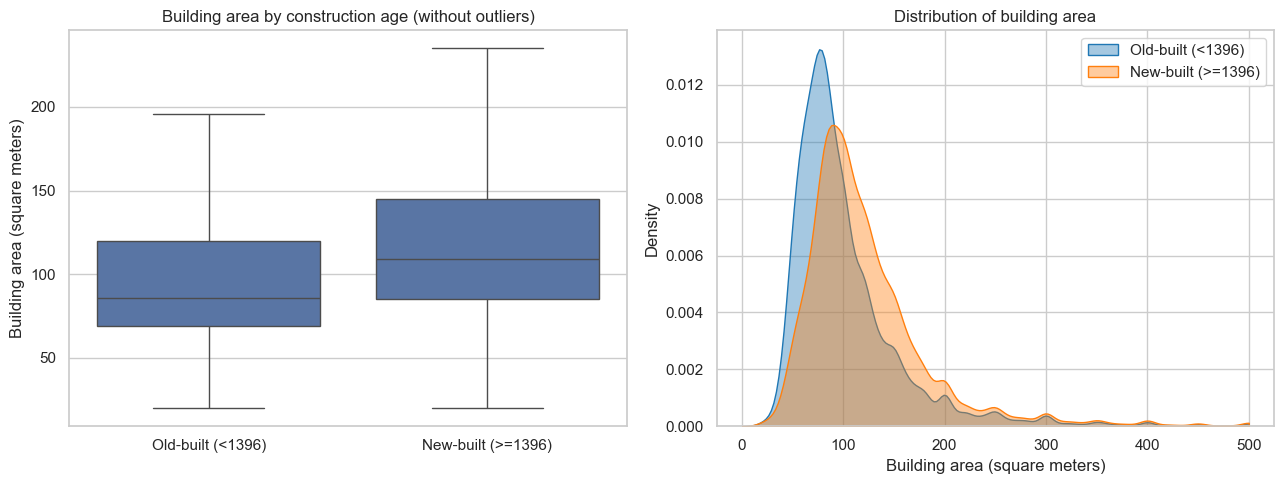

In [280]:
# نمودارها: باکس‌پلات و توزیع متراژ
home_df['Group'] = np.where(
    home_df['construction_year_numeric'] < cutoff_year,
    f'Old-built (<{cutoff_year})',
    f'New-built (>={cutoff_year})',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=home_df, x='Group', y='building_size', ax=axes[0], showfliers=False,
    order=[f'Old-built (<{cutoff_year})', f'New-built (>={cutoff_year})'],
)
axes[0].set_title('Building area by construction age (without outliers)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Building area (square meters)')

for grp, color in zip(home_df['Group'].unique(), ['tab:blue', 'tab:orange']):
    sns.kdeplot(
        home_df.loc[home_df['Group'] == grp, 'building_size'],
        ax=axes[1], label=grp, fill=True, alpha=0.4, clip=(0, 500), color=color,
    )
axes[1].set_title('Distribution of building area')
axes[1].set_xlabel('Building area (square meters)')
axes[1].legend()

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right">

##### نتیجه

میانه‌ی متراژ خونه‌های قدیمی ۸۶ و جدید ۱۰۹ متره (میانگین‌ها ۱۰۶٫۴ و ۱۲۸٫۵). هر دو آزمون می‌گن تفاوت معناداره (p تقریباً صفر)، ولی **خلاف فرضیه**: خونه‌های جدید بزرگ‌ترن. اندازه‌ی اثر کوچیک تا متوسطه (r ≈ ۰٫۲۷ و d ≈ ۰٫۲۵−) و تقریباً توی ۶۳٪ مقایسه‌های تصادفی خونه‌ی جدید بزرگ‌تره. پس فرضیه تأیید نمی‌شه.

</div>

#### ۳. سند تجاری و قیمت ملک تجاری

In [281]:
commercial_sell = df[df["cat2_slug"] == "commercial-sell"].copy()
commercial_sell = commercial_sell.dropna(subset=["has_business_deed", "price_value"])

group_with_deed = commercial_sell.loc[commercial_sell["has_business_deed"] == True, "price_value"]
group_without_deed = commercial_sell.loc[commercial_sell["has_business_deed"] == False, "price_value"]

print("With deed:", len(group_with_deed), "| Without deed:", len(group_without_deed))
print("Mean with deed:", group_with_deed.mean())
print("Mean without deed:", group_without_deed.mean())

With deed: 14228 | Without deed: 14359
Mean with deed: 27441239553.76954
Mean without deed: 26086390946.2067


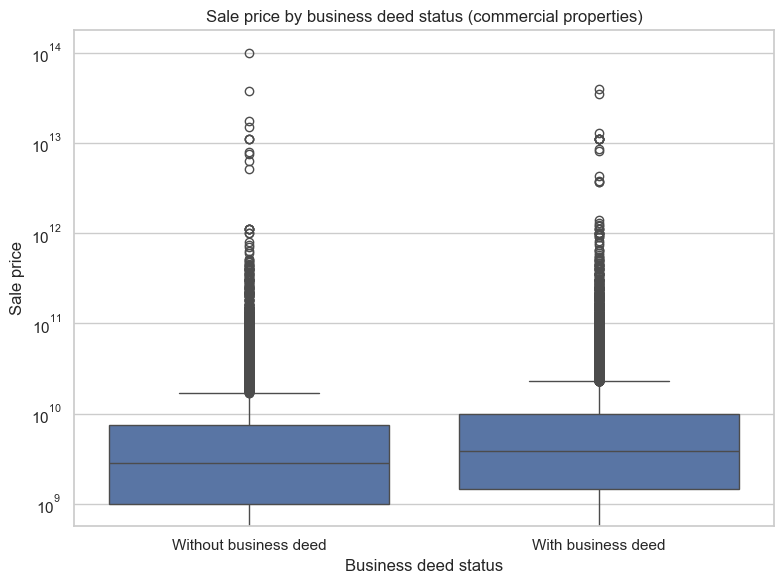

In [282]:
plot_data = commercial_sell.copy()
plot_data["deed_status"] = plot_data["has_business_deed"].map({True: "With business deed", False: "Without business deed"})

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_data, x="deed_status", y="price_value")
plt.title("Sale price by business deed status (commercial properties)")
plt.xlabel("Business deed status")
plt.ylabel("Sale price")
plt.yscale("log")
plt.tight_layout()
plt.show()

##### بررسی توزیع قبل از انتخاب آزمون

مث مقایسه‌ی متراژ قبلی، قبل اینکه فقط به تی‌تست اعتماد کنیم نرمال بودن رو چک می‌کنیم، چون price_value توی املاک معمولا خیلی چوله به راسته و داده‌ی پرت زیاد داره.

In [283]:
print(f"Skewness: with deed={group_with_deed.skew():.2f}, without deed={group_without_deed.skew():.2f}")

rng = np.random.default_rng(42)
sw_with = stats.shapiro(rng.choice(group_with_deed, size=min(4000, len(group_with_deed)), replace=False))
sw_without = stats.shapiro(rng.choice(group_without_deed, size=min(4000, len(group_without_deed)), replace=False))
print(f"Shapiro-Wilk (subsample) with deed: statistic={sw_with.statistic:.3f}, p={sw_with.pvalue:.2e}")
print(f"Shapiro-Wilk (subsample) without deed: statistic={sw_without.statistic:.3f}, p={sw_without.pvalue:.2e}")

Skewness: with deed=54.69, without deed=91.08
Shapiro-Wilk (subsample) with deed: statistic=0.020, p=1.82e-89
Shapiro-Wilk (subsample) without deed: statistic=0.186, p=2.54e-85


In [284]:
ALPHA = 0.05

u_stat, p_mw = stats.mannwhitneyu(group_with_deed, group_without_deed, alternative='two-sided')
t_stat, p_t = stats.ttest_ind(group_with_deed, group_without_deed, equal_var=False)

print("--- Mann-Whitney U (main test, on raw data) ---")
print(f"U = {u_stat:,.1f}, p-value = {p_mw:.4g}")
print(f"Result at alpha={ALPHA}: {'Reject H0 (significant difference)' if p_mw < ALPHA else 'Fail to reject H0'}")

print()
print("--- Welch's t-test (raw data, for comparison) ---")
print(f"t = {t_stat:.3f}, p-value = {p_t:.4g}")
print(f"Result at alpha={ALPHA}: {'Reject H0 (significant difference)' if p_t < ALPHA else 'Fail to reject H0'}")

--- Mann-Whitney U (main test, on raw data) ---
U = 113,571,227.0, p-value = 3.045e-60
Result at alpha=0.05: Reject H0 (significant difference)

--- Welch's t-test (raw data, for comparison) ---
t = 0.151, p-value = 0.8804
Result at alpha=0.05: Fail to reject H0


##### تفسیر نتیجه

چولگی هر دو گروه خیلی بالاست (۵۴.۶۹ برای گروه دارای سند و ۹۱.۰۸ برای بدون سند) و آزمون شاپیرو-ویلک هم تایید میکنه (p تقریبا صفر برای هردو) که توزیع قیمت خیلی از نرمال فاصله داره، چون قیمت ملک معمولا چندتا داده پرت نجومی داره. برای همین تی‌تست ولش نمیتونه تفاوت معناداری پیدا کنه (p = ۰.۸۸)، درحالیکه آزمون ناپارامتری من-ویتنی یو که به داده پرت حساس نیست و فرض نرمال بودن نداره، تفاوت رو درست و با اطمینان بالا معنادار تشخیص میده (p = ۳.۰×۱۰⁻⁶⁰). این دقیقا نشون میده چرا باید قبل انتخاب آزمون توزیع داده رو چک کرد؛ اگه فقط به تی‌تست اکتفا میکردیم نتیجه اشتباه میگرفتیم. بر اساس آزمون من-ویتنی نتیجه میگیریم داشتن سند تجاری با قیمت فروش بالاتر ملک تجاری رابطه معناداری داره (میانگین ۲۷.۴ میلیارد تومن با سند در برابر ۲۶.۱ میلیارد بدون سند، هرچند این میانگینا خودشون بخاطر داده پرت باید با احتیاط خونده بشن).

#### ۴. امکانات لوکس در برابر غیرلوکس

**فرضیه:** امکانات رو به دو گروه تقسیم میکنیم — لوکس (استخر، باربیکیو، سونا، جکوزی) و غیرلوکس (بالکن، آسانسور، پارکینگ، انباری، نگهبان) — و بررسی میکنیم آیا داشتن حداقل یه امکان لوکس با میانگین price_value بالاتر رابطه معنادار داره یا نه، و جدا همینو برای امکانات غیرلوکس هم میسنجیم.

In [285]:
luxury_cols = ['has_pool', 'has_barbecue', 'has_sauna', 'has_jacuzzi']
non_luxury_cols = ['has_balcony', 'has_elevator', 'has_parking', 'has_warehouse', 'has_security_guard']

sell_only = df[df['ad_type'] == 'sell'].copy()

sell_only['has_luxury'] = sell_only[luxury_cols].eq(True).any(axis=1)
sell_only['has_non_luxury'] = sell_only[non_luxury_cols].eq(True).any(axis=1)

price_data = sell_only.dropna(subset=['price_value'])
print("Total sell ads with price:", len(price_data))
print(price_data['has_luxury'].value_counts())
print(price_data['has_non_luxury'].value_counts())

Total sell ads with price: 567091
has_luxury
False    560800
True       6291
Name: count, dtype: int64
has_non_luxury
True     409521
False    157570
Name: count, dtype: int64


In [286]:
group_luxury = price_data.loc[price_data['has_luxury'] == True, 'price_value']
group_no_luxury = price_data.loc[price_data['has_luxury'] == False, 'price_value']
group_non_luxury = price_data.loc[price_data['has_non_luxury'] == True, 'price_value']
group_no_non_luxury = price_data.loc[price_data['has_non_luxury'] == False, 'price_value']

rng = np.random.default_rng(42)
for label, g_with, g_without in [("Luxury", group_luxury, group_no_luxury),
                                   ("Non-luxury", group_non_luxury, group_no_non_luxury)]:
    print(f"--- {label}: skewness with={g_with.skew():.2f}, without={g_without.skew():.2f} ---")
    sw_with = stats.shapiro(rng.choice(g_with, size=min(4000, len(g_with)), replace=False))
    sw_without = stats.shapiro(rng.choice(g_without, size=min(4000, len(g_without)), replace=False))
    print(f"Shapiro with: p={sw_with.pvalue:.2e} | without: p={sw_without.pvalue:.2e}")
    print()

--- Luxury: skewness with=60.85, without=111.65 ---
Shapiro with: p=9.55e-90 | without: p=9.85e-90

--- Non-luxury: skewness with=122.03, without=94.12 ---
Shapiro with: p=3.03e-89 | without: p=8.21e-90



In [287]:
ALPHA = 0.05

for label, col in [("Luxury", "has_luxury"), ("Non-luxury", "has_non_luxury")]:
    g_with = price_data.loc[price_data[col] == True, "price_value"]
    g_without = price_data.loc[price_data[col] == False, "price_value"]

    u_stat, p_mw = stats.mannwhitneyu(g_with, g_without, alternative='two-sided')
    t_stat, p_t = stats.ttest_ind(g_with, g_without, equal_var=False)

    print(f"=== {label} amenities ===")
    print(f"n with: {len(g_with):,} | n without: {len(g_without):,}")
    print(f"Mean with: {g_with.mean():,.0f} | Mean without: {g_without.mean():,.0f}")
    print(f"Mann-Whitney U: U={u_stat:,.1f}, p={p_mw:.4g} -> {'Significant' if p_mw < ALPHA else 'Not significant'}")
    print(f"Welch's t-test: t={t_stat:.3f}, p={p_t:.4g} -> {'Significant' if p_t < ALPHA else 'Not significant'}")
    print()

=== Luxury amenities ===
n with: 6,291 | n without: 560,800
Mean with: 11,612,414,796 | Mean without: 17,454,174,994
Mann-Whitney U: U=1,835,477,663.5, p=3.093e-08 -> Significant
Welch's t-test: t=-1.560, p=0.1187 -> Not significant

=== Non-luxury amenities ===
n with: 409,521 | n without: 157,570
Mean with: 15,956,756,483 | Mean without: 21,112,700,172
Mann-Whitney U: U=43,039,204,917.0, p=0 -> Significant
Welch's t-test: t=-2.623, p=0.008705 -> Significant



##### تفسیر نتیجه

هر دو گروه چولگی خیلی بالایی دارن (۶۰ تا ۱۲۲) و شاپیرو-ویلک هم به شدت نرمال بودن رو رد میکنه (p تقریبا صفر)، که نشون میده price_value حتی بعد از محدود کردن به آگهی‌های فروش دارای قیمت هم خیلی از نرمال فاصله داره. برای همین آزمون ناپارامتری من-ویتنی یو اینجا قابل اعتمادتره و تی‌تست ولش فقط برای مقایسه گزارش شده.

برای **امکانات لوکس** (استخر، باربیکیو، سونا، جکوزی)، من-ویتنی یو تفاوت خیلی معناداری نشون میده (p = ۳.۱×۱۰⁻⁸)، درحالیکه اگه فقط به تی‌تست ولش اکتفا میکردیم میگفتیم تفاوت معنادار نیست (p = ۰.۱۲). این ناهماهنگی مستقیما نتیجه‌ی داده پرت و چولگی شدید قیمته که واریانس مورد استفاده تی‌تست رو بزرگ میکنه و یه تفاوت واقعی توی رتبه‌ها رو پنهون میکنه. میانگینای خام (۱۱.۶ میلیارد با امکانات لوکس در برابر ۱۷.۵ میلیارد بدون) با توجه به این چولگی نباید عینا تفسیر بشن؛ علامت و اندازه این فاصله اینجا کم‌اهمیت‌تر از معنادار بودن آزمون رتبه‌ایه.

برای **امکانات غیرلوکس** (بالکن، آسانسور، پارکینگ، انباری، نگهبان)، هر دو آزمون روی معنادار بودن تفاوت توافق دارن (من-ویتنی p تقریبا صفر، تی‌تست ولش p = ۰.۰۰۸۷).

**نتیجه‌ی کلیدی:** اگه فقط به تی‌تست اکتفا میکردیم، برای امکانات لوکس نتیجه‌ی اشتباه (غلط "معنادار نیست") میگرفتیم. آزمون من-ویتنی یو که فرض نرمال بودن نداره و به داده پرت حساس نیست، آزمون اصلی مناسب برای این داده‌ی خیلی چوله‌ست و نشون میده **هم امکانات لوکس و هم غیرلوکس با تفاوت معنادار در قیمت فروش رابطه دارن**. این، مث آزمون سند تجاری قبلی، اهمیت چک کردن نرمال بودن قبل از اعتماد به نتیجه‌ی تی‌تست رو دوباره یادآوری میکنه.

### پاکسازی ویژگی‌های دودویی

این مرحله پاکسازی معمولا باید بلافاصله بعد از بارگذاری داده انجام بشه. اینجا گذاشتیمش چون تحلیل امکانات بر اساس منطقه و آزمون سند تجاری به مقادیر گمشده خام (NaN) این ستونای پرچمی وابسته‌ان؛ اگه زودتر با False پر میشدن، نتیجه‌ی اون دو تا تحلیل عوض میشد. هیچکدوم از تحلیل‌های بالا به این مرحله وابسته نیست، و این مرحله داده رو برای بخش ۳ آماده میکنه.

In [288]:
binary_amenity_cols = [
    'has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse',
    'has_parking', 'has_water', 'has_electricity', 'has_gas',
    'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna'
]

df[binary_amenity_cols] = df[binary_amenity_cols].fillna(False)

In [289]:
missed_binary_cols = [
    'has_heating_system', 'has_cooling_system',
    'has_restroom', 'has_warm_water_provider', 'is_rebuilt'
]

df[missed_binary_cols] = df[missed_binary_cols].fillna(False)

In [290]:
df[missed_binary_cols].isnull().sum()

has_heating_system         0
has_cooling_system         0
has_restroom               0
has_warm_water_provider    0
is_rebuilt                 0
dtype: int64

<div dir="rtl" style="text-align:right">

## بخش ۳: یادگیری ماشین

</div>

<div dir="rtl" style="text-align:right">

### مسئله‌ی ۱: سیستم توصیه‌گر

</div>

<div dir="rtl" style="text-align:right">

برای سیستم توصیه‌گر ۵ تا ویژگی انتخاب کردیم: قیمت یکسان‌شده، متراژ، تعداد اتاق و مختصات UTM (دو ستون). عمداً کمشون گرفتیم که دچار نفرین ابعاد نشیم.

قیمت یکسان‌شده برای فروش همون `price_value_clean`ه و برای اجاره «رهن + اجاره ÷ ۰٫۰۳» (هر ۱ میلیون رهن ≈ ۳۰ هزار اجاره). از `rent_value_clean` استفاده نکردیم چون اجاره‌ی صفر (رهن کامل) رو حذف می‌کنه، در حالی که این آگهی‌ها معتبرن. برای رهن هم فقط سقف رو محدود کردیم.

</div>

In [291]:
# قیمت یکسان‌شده: برای فروش همون قیمته و برای اجاره رهن + اجاره/۰٫۰۳
ads = df[df['cat2_slug'].isin(['residential-sell', 'residential-rent'])].copy()
rent_mask = ads['cat2_slug'] == 'residential-rent'

rent_value_ok = ads['rent_value'].where(ads['rent_value'].between(0, 500_000_000))

credit_f = ads['credit_value'].fillna(0)
credit_hi = credit_f[rent_mask].quantile(0.99)
credit_capped = credit_f.clip(upper=credit_hi)

rent_lump_sum = credit_capped + rent_value_ok / 0.03

ads['unified_price'] = np.where(
    ads['cat2_slug'] == 'residential-sell',
    ads['price_value_clean'],
    rent_lump_sum
)

rent_before = int(rent_mask.sum())

ads = ads.dropna(subset=['unified_price', 'building_size', 'rooms_count_num',
                        'location_latitude', 'location_longitude'])

ads = ads[ads['unified_price'].between(1e8, 1e12)]
ads = ads[ads['building_size'].between(20, 2000)]
ads = ads[ads['location_latitude'].between(25, 40) & ads['location_longitude'].between(44, 64)]

rent_after = int((ads['cat2_slug'] == 'residential-rent').sum())
print(f'Rent ads kept: {rent_after:,} of {rent_before:,} ({rent_after/rent_before:.1%})')
print('Rows available for clustering:', len(ads))
ads['unified_price'].describe()

Rent ads kept: 178,652 of 276,558 (64.6%)
Rows available for clustering: 448742


count    4.487420e+05
mean     4.151303e+09
std      1.299668e+10
min      1.000000e+08
25%      6.033333e+08
50%      1.800000e+09
75%      4.080000e+09
max      1.000000e+12
Name: unified_price, dtype: float64

<div dir="rtl" style="text-align:right">

از ۲۷۶٬۵۵۸ آگهی اجاره، ۱۷۸٬۶۵۲ تا (۶۴٫۶٪) موند.

</div>

In [292]:
to_utm = Transformer.from_crs('EPSG:4326', 'EPSG:32639', always_xy=True)
ads['utm_x'], ads['utm_y'] = to_utm.transform(
    ads['location_longitude'].values, ads['location_latitude'].values
)
ads['log_price'] = np.log10(ads['unified_price'])

In [293]:
ads['is_sell'] = (ads['cat2_slug'] == 'residential-sell').astype(int)
X_purity = RobustScaler().fit_transform(ads[['log_price', 'building_size', 'rooms_count_num', 'utm_x', 'utm_y']])
km_test = KMeans(n_clusters=10, random_state=42, n_init=10).fit(X_purity)
ads['test_label'] = km_test.labels_

purity = ads.groupby('test_label')['is_sell'].agg(['mean', 'count']).round(3)
purity.columns = ['sell_share', 'size']
print(purity)
print("میانگین خلوص (purity):", np.maximum(purity['sell_share'], 1 - purity['sell_share']).mean().round(3))

            sell_share    size
test_label                    
0                0.673   65694
1                0.553   45991
2                0.567   36532
3                0.649   29527
4                0.587  186720
5                0.573   39014
6                0.652   19287
7                0.808    1349
8                0.780    9777
9                0.489   14851
میانگین خلوص (purity): 0.635


<div dir="rtl" style="text-align:right">

پیش از خوشه‌بندی نهایی، بررسی کردیم که آیا ترکیب آگهی‌های فروش و اجاره در یک فضا باعث می‌شه خوشه‌ها فقط نوع معامله رو جدا کنن یا نه. میانگین خلوص (purity) خوشه‌ها ها نسبت به نوع معامله فقط ۰.۶۳۵ شد (در صورت تفکیک کامل باید نزدیک ۱ می‌بود)، یعنی ترکیب فروش و اجاره مشکلی ایجاد نمی‌کنه و می‌تونیم ادامه بدیم
</div>

<div dir="rtl" style="text-align:right">

#### بخش ۱: K-Means با ۱۰ خوشه

</div>

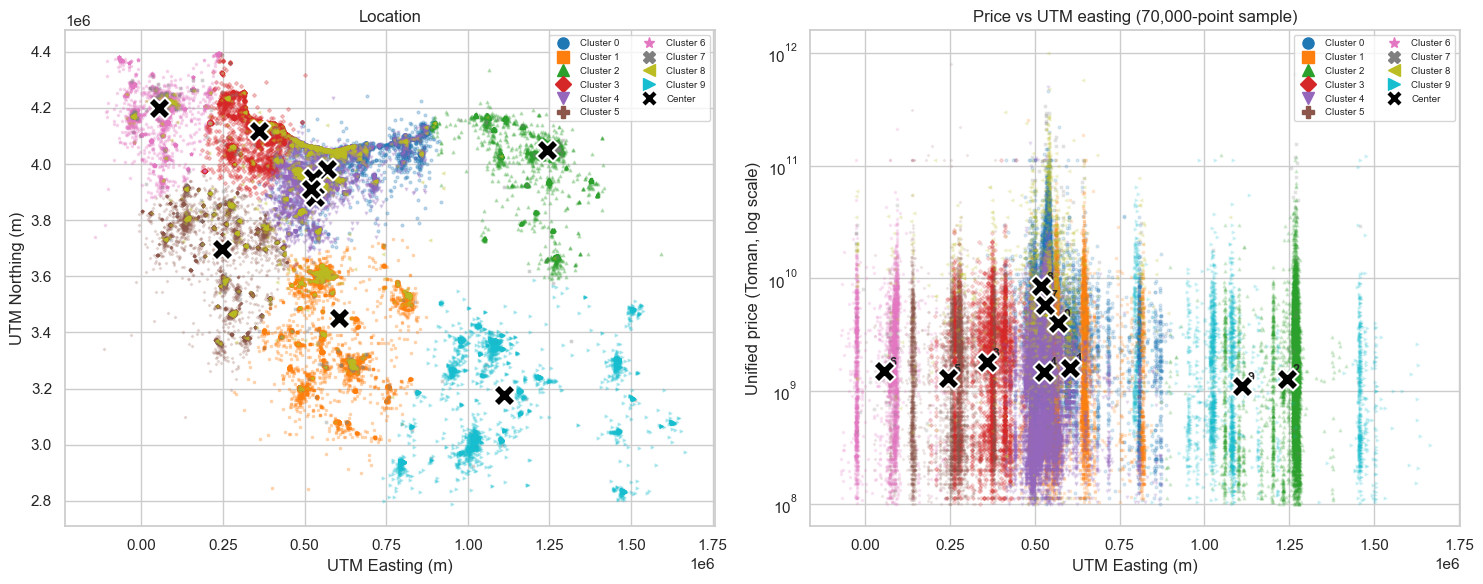

In [294]:
# K-Means با ۱۰ خوشه و نمودارهاش
km_cols = ['log_price', 'building_size', 'rooms_count_num', 'utm_x', 'utm_y']
X_km = RobustScaler().fit_transform(ads[km_cols])

km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
ads['cluster_10'] = km10.fit_predict(X_km)

markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', '<', '>']
cmap = plt.get_cmap('tab10')
cent_geo = ads.groupby('cluster_10')[['utm_x', 'utm_y']].mean()
cent_price = ads.groupby('cluster_10')['unified_price'].median()

from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], marker=markers[c], color=cmap(c), linestyle='',
                          markersize=8, alpha=1.0, label=f'Cluster {c}') for c in range(10)]
center_handle = Line2D([0], [0], marker='X', color='black', linestyle='',
                        markersize=12, markeredgecolor='white', label='Center')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for c in range(10):
    sub = ads[ads['cluster_10'] == c]
    ax.scatter(sub['utm_x'], sub['utm_y'], s=4, alpha=0.25, color=cmap(c), marker=markers[c])
ax.scatter(cent_geo['utm_x'], cent_geo['utm_y'], c='black', marker='X', s=250,
           edgecolors='white', linewidths=1.5, zorder=5)
ax.set_xlabel('UTM Easting (m)'); ax.set_ylabel('UTM Northing (m)')
ax.set_title('Location')
ax.legend(handles=legend_handles + [center_handle], fontsize=7, ncol=2, loc='upper right')

sample = ads.sample(min(70_000, len(ads)), random_state=42)
ax2 = axes[1]
for c in range(10):
    sub = sample[sample['cluster_10'] == c]
    ax2.scatter(sub['utm_x'], sub['unified_price'], s=4, alpha=0.15, color=cmap(c), marker=markers[c])
ax2.scatter(cent_geo['utm_x'], cent_price, c='black', marker='X', s=250,
            edgecolors='white', linewidths=1.5, zorder=5)
for c in range(10):
    ax2.annotate(str(c), (cent_geo.loc[c, 'utm_x'], cent_price.loc[c]),
                 fontsize=9, fontweight='bold', xytext=(4, 4), textcoords='offset points')
ax2.set_yscale('log')
ax2.set_xlabel('UTM Easting (m)'); ax2.set_ylabel('Unified price (Toman, log scale)')
ax2.set_title(f'Price vs UTM easting ({len(sample):,}-point sample)')
ax2.legend(handles=legend_handles + [center_handle], fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

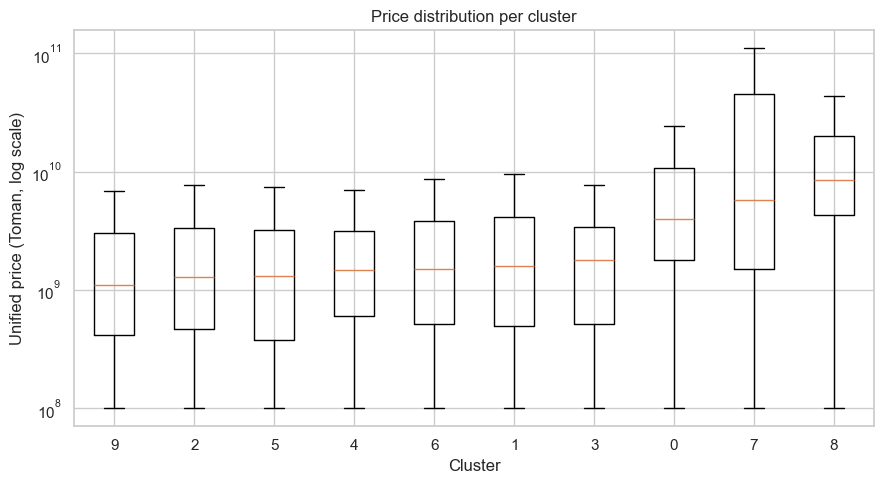

,n,median_price,median_size,median_rooms,lat_std,lon_std
cluster_10,,,,,,
0,65694,4.000000e+09,144.0,3.0,0.49,1.00
1,45991,1.600000e+09,118.0,2.0,1.50,0.84
2,36532,1.280000e+09,100.0,2.0,0.64,0.67
3,29527,1.800000e+09,94.0,2.0,0.59,0.64
4,186720,1.480000e+09,77.0,2.0,0.33,0.43
5,39014,1.300000e+09,100.0,2.0,1.42,0.93
6,19287,1.500000e+09,105.0,2.0,0.52,0.64
7,1349,5.800000e+09,1000.0,3.0,2.56,3.46
8,9777,8.500000e+09,350.0,4.0,1.68,1.38


In [295]:
# مشخصات هر خوشه (تعداد، قیمت میانه، متراژ و ...)
order = ads.groupby('cluster_10')['unified_price'].median().sort_values().index
data = [ads[ads['cluster_10'] == c]['unified_price'] for c in order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=[str(c) for c in order], showfliers=False)
ax.set_yscale('log')
ax.set_xlabel('Cluster'); ax.set_ylabel('Unified price (Toman, log scale)')
ax.set_title('Price distribution per cluster')
plt.tight_layout()
plt.show()

ads.groupby('cluster_10').agg(
    n=('unified_price', 'size'), median_price=('unified_price', 'median'),
    median_size=('building_size', 'median'), median_rooms=('rooms_count_num', 'median'),
    lat_std=('location_latitude', 'std'), lon_std=('location_longitude', 'std'),
).round(2)

<div dir="rtl" style="text-align:right">

##### نتیجه

بیشتر خوشه‌ها یه منطقه‌ی جغرافیایی مشخصن. دو تاشون بیشتر به نوع ملک مربوطن تا مکان: بزرگ‌ترین خوشه (۱۸۶٬۷۲۰ آگهی، حدود ۷۷ متر) خونه‌ی کوچیک و ارزون شهریه که توی شهرهای مختلف هست، و کوچیک‌ترین (حدود ۱٬۳۴۹ آگهی، حدود ۱۰۰۰ متر) ملک خیلی بزرگ و پراکنده‌ست. شماره‌ی خوشه‌ها قراردادیه و ممکنه توی اجرای بعدی عوض بشه.

</div>

In [296]:
feat_noloc = ['log_price', 'building_size', 'rooms_count_num']
X_noloc = RobustScaler().fit_transform(ads[feat_noloc])

km_noloc = KMeans(n_clusters=10, random_state=42, n_init=10).fit(X_noloc)
ads['cluster_noloc'] = km_noloc.labels_

profile_noloc = ads.groupby('cluster_noloc').agg(
    size=('cluster_noloc', 'size'),
    median_price=('unified_price', 'median'),
    median_area=('building_size', 'median'),
    mean_rooms=('rooms_count_num', 'mean'),
    sell_share=('is_sell', 'mean'),
    tehran_share=('city_slug', lambda s: (s == 'tehran').mean()),
).round(2)
print(profile_noloc)

                 size  median_price  median_area  mean_rooms  sell_share  \
cluster_noloc                                                              
0              102014  5.333333e+08         90.0        2.01        0.19   
1               39124  1.100000e+09        152.0        2.77        0.24   
2               54047  1.980000e+09         60.0        0.97        0.95   
3                1052  5.125000e+09       1000.0        2.74        0.79   
4              132972  3.200000e+09         95.0        2.00        0.94   
5                3634  1.124167e+10        500.0        3.71        0.83   
6               17811  6.500000e+09        280.0        3.48        0.75   
7               49146  3.000000e+08         64.0        0.94        0.07   
8                 229  6.000000e+09       1600.0        2.28        0.91   
9               48713  7.000000e+09        155.0        2.99        0.91   

               tehran_share  
cluster_noloc                
0                      0.16

<div dir="rtl" style="text-align:right">

##### آزمایش: خوشه‌بندی بدون مختصات

برای اینکه مطمئن بشیم خوشه‌های بالا واقعا جغرافیاییان، همون K-Means (k=۱۰) رو فقط با قیمت، متراژ و تعداد اتاق (بدون UTM) دوباره اجرا کردیم. اینبار تیپای واقعی ملک ظاهر شدن، مثلا یه خوشه استودیو/یک‌خوابه‌ی کوچیک که تقریبا همش فروشیه، یه خوشه اجاره‌ای ارزون، و یه خوشه لوکس با متراژ بالا و قیمت خیلی بالا. سهم تهران هم توی همه‌ی خوشه‌ها تقریبا یکسون موند (بین ۱۵٪ تا ۳۹٪). این نشون میده وقتی UTM توی ویژگیاست، تنوع مکانی بر تنوع تیپ ملک غلبه میکنه و خوشه‌هارو بیشتر بر اساس شهر جدا میکنه تا بر اساس سلیقه‌ی واقعی کاربر.

</div>


<div dir="rtl" style="text-align:right">

#### بخش ۲: انتخاب k

</div>

<div dir="rtl" style="text-align:right">

k رو با سه معیار انتخاب می‌کنیم، نه فقط با نگاه کردن به نمودار:

1. **زانوی WCSS:** دورترین نقطه از خط بین k=1 و k=20. فقط برای اطلاع گزارش می‌شه.
2. **حداقل ۲٪:** بزرگ‌ترین k که کوچیک‌ترین خوشه‌ش هنوز دست‌کم ۲٪ داده رو داشته باشه. تصمیم اصلی با این معیاره.
3. **پایداری:** چند بار با seed مختلف اجرا می‌کنیم و ARI می‌گیریم.

</div>

Knee (k=1..20 scan): 6
 k  silhouette  min_cluster_share
 2       0.600              0.126
 3       0.480              0.102
 4       0.499              0.099
 5       0.508              0.033
 6       0.516              0.015
 7       0.518              0.015
 8       0.417              0.007
 9       0.415              0.007
10       0.389              0.003
11       0.390              0.003
12       0.395              0.003
13       0.350              0.002
14       0.351              0.003
15       0.365              0.002
16       0.366              0.002
17       0.342              0.003
18       0.368              0.001
19       0.344              0.001
20       0.330              0.001


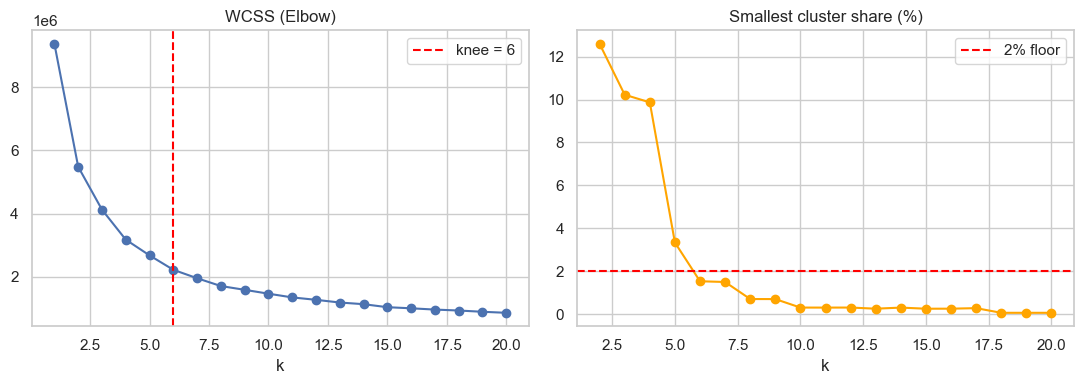

In [297]:
def find_knee(x, y):
    """Kneedle-style knee: point of maximum perpendicular distance from the line joining
    the first and last point of a decreasing convex curve."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y - y.min()) / (y.max() - y.min())
    x0, y0, x1, y1 = xn[0], yn[0], xn[-1], yn[-1]
    dxl, dyl = x1 - x0, y1 - y0
    dist = np.abs(dyl * (xn - x0) - dxl * (yn - y0)) / np.hypot(dxl, dyl)
    return int(x[np.argmax(dist)])

k_max = 20
X_sample = X_km
wcss, sil, min_share = [], [], []
for k in range(1, k_max + 1):
    m = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_sample)
    wcss.append(m.inertia_)
    if k >= 2:
        sil.append(silhouette_score(X_sample, m.labels_, sample_size=5000, random_state=42))
        min_share.append(pd.Series(m.labels_).value_counts(normalize=True).min())

k_knee = find_knee(list(range(1, k_max + 1)), wcss)
summary = pd.DataFrame({'k': list(range(2, k_max + 1)), 'silhouette': sil, 'min_cluster_share': min_share})
print('Knee (k=1..%d scan):' % k_max, k_knee)
print(summary.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, k_max + 1), wcss, marker='o')
axes[0].axvline(k_knee, color='red', linestyle='--', label=f'knee = {k_knee}')
axes[0].set_title('WCSS (Elbow)'); axes[0].set_xlabel('k'); axes[0].legend()
axes[1].plot(summary['k'], summary['min_cluster_share'] * 100, marker='o', color='orange')
axes[1].axhline(2, color='red', linestyle='--', label='2% floor')
axes[1].set_title('Smallest cluster share (%)'); axes[1].set_xlabel('k'); axes[1].legend()
plt.tight_layout()
plt.show()

In [298]:

ok_ks = summary.loc[summary['min_cluster_share'] >= 0.02, 'k']
best_k = int(ok_ks.max()) if len(ok_ks) else k_knee
print('Chosen k:', best_k)

seed_labels = [KMeans(n_clusters=best_k, random_state=s, n_init=10).fit(X_sample).labels_ for s in range(5)]
ari_list = [adjusted_rand_score(seed_labels[i], seed_labels[j]) for i in range(5) for j in range(i+1, 5)]
print('Mean ARI across 5 seeds:', round(np.mean(ari_list), 3), '| min:', round(min(ari_list), 3))

Chosen k: 5
Mean ARI across 5 seeds: 1.0 | min: 0.999


<div dir="rtl" style="text-align:right">

زانو k=۶ شد، ولی از k=۶ به بعد کوچیک‌ترین خوشه کمتر از ۲٪ه (۳٫۳٪ توی k=۵ و ۱٫۵٪ توی k=۶ و ۷). پس **k = ۵** رو انتخاب کردیم. با seedهای مختلف هم نتیجه ثابته (ARI میانگین ۱٫۰ و کمینه ۰٫۹۹۹).

</div>

<div dir="rtl" style="text-align:right">

#### بخش ۳: DBSCAN روی UTM و قیمت

</div>

<div dir="rtl" style="text-align:right">

DBSCAN رو فقط روی تهران اجرا می‌کنیم. دلیلش خراب شدن فاصله‌ها توی UTM نیست: خطای مقیاس یک زون میانه ۰٫۰۴٪ و حداکثر ۲٪هست.

مشکل اصلی چگالیه. DBSCAN برای کل داده فقط یک `eps` و یک `min_samples` داره، ولی تهران حدود ۲۵٫۷٪ آگهی‌هاست و کرج و مشهد هر کدوم حدود ۶٪. روی کل کشور حدود ۴۵٪ نویز می‌شد و فقط یه بازه‌ی خیلی باریک ۳ خوشه می‌داد. K-Means (بخش ۱ و ۲) این مشکل رو نداره و ملی موند.

</div>

In [299]:
ads_teh = ads[ads['city_slug'] == 'tehran'].copy()
before_box = len(ads_teh)
ads_teh = ads_teh[ads_teh['location_latitude'].between(35.35, 35.95) &
                ads_teh['location_longitude'].between(50.85, 51.75)]
print(f'Tehran ads: {before_box:,} -> {len(ads_teh):,} after dropping mislabeled coordinates')

db_cols = ['utm_x', 'utm_y', 'log_price']
X_dbscan = StandardScaler().fit_transform(ads_teh[db_cols])

Tehran ads: 115,638 -> 115,316 after dropping mislabeled coordinates


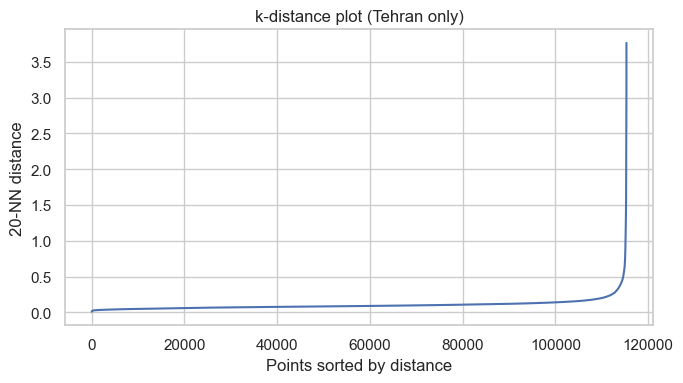

In [300]:
nn = NearestNeighbors(n_neighbors=k).fit(X_dbscan)
k_dist = np.sort(nn.kneighbors(X_dbscan)[0][:, -1])
plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.ylabel(f'{k}-NN distance'); plt.xlabel('Points sorted by distance')
plt.title('k-distance plot (Tehran only)')
plt.tight_layout()
plt.show()

In [301]:
results = []
for eps in [0.09, 0.10, 0.11, 0.12, 0.14, 0.16, 0.18, 0.20]:
    for ms in [15, 20, 25, 30, 40, 60]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_dbscan)
        sizes = pd.Series(labels[labels >= 0]).value_counts()
        big = sizes[sizes >= 0.02 * len(labels)]
        results.append({'eps': eps, 'min_samples': ms,
                         'n_big_clusters': len(big),
                         'raw_noise_%': round((labels == -1).mean() * 100, 1)})
pd.DataFrame(results)

,eps,min_samples,n_big_clusters,raw_noise_%
0,0.09,15,5,19.1
1,0.09,20,3,27.2
2,0.09,25,4,35.4
3,0.09,30,7,43.8
4,0.09,40,4,57.4
5,0.09,60,3,73.9
6,0.10,15,1,13.1
7,0.10,20,4,19.0
8,0.10,25,3,25.2
9,0.10,30,5,31.6


<div dir="rtl" style="text-align:right">

سه تا تنظیم از گرید بدون هیچ دست‌کاری دقیقاً ۳ خوشه‌ی بزرگ (بالای ۲٪) می‌دن:

| eps | min_samples | نویز خام | بزرگ‌ترین خوشه | پوشش ۳ خوشه |
|---|---|---|---|---|
| 0.10 | 25 | 25.2% | 34.1% | 60.2% |
| 0.11 | 25 | 17.9% | 39.9% | 74.4% |
| 0.12 | 30 | 16.2% | 41.0% | 77.5% |

`eps=0.12` و `min_samples=30` کمترین نویز و بیشترین پوشش رو داره، پس همین رو برمی‌داریم. این تنظیم توی یه پنجره‌ی باریکه: تنظیم‌های کناریش یا ۱ خوشه می‌دن یا ۴ تا.

**اثر پارامترها:** eps بزرگ‌تر خوشه‌ها رو به هم می‌چسبونه (آخرش یه خوشه‌ی غول)، eps کوچیک‌تر نویز و خوشه‌ی ریز زیاد می‌کنه. min_samples بزرگ‌تر چگالی بیشتری می‌خواد، پس خوشه‌ها کمتر و نویز بیشتر می‌شه.

</div>

3 clusters clear the 2% floor.
Final noise %: 22.5
                    n  median_price  median_lon  median_lat
cluster_dbscan                                             
0               47323  3.050000e+09       51.35       35.72
1               38808  3.233333e+09       51.47       35.74
3                3192  3.040000e+09       51.21       35.75


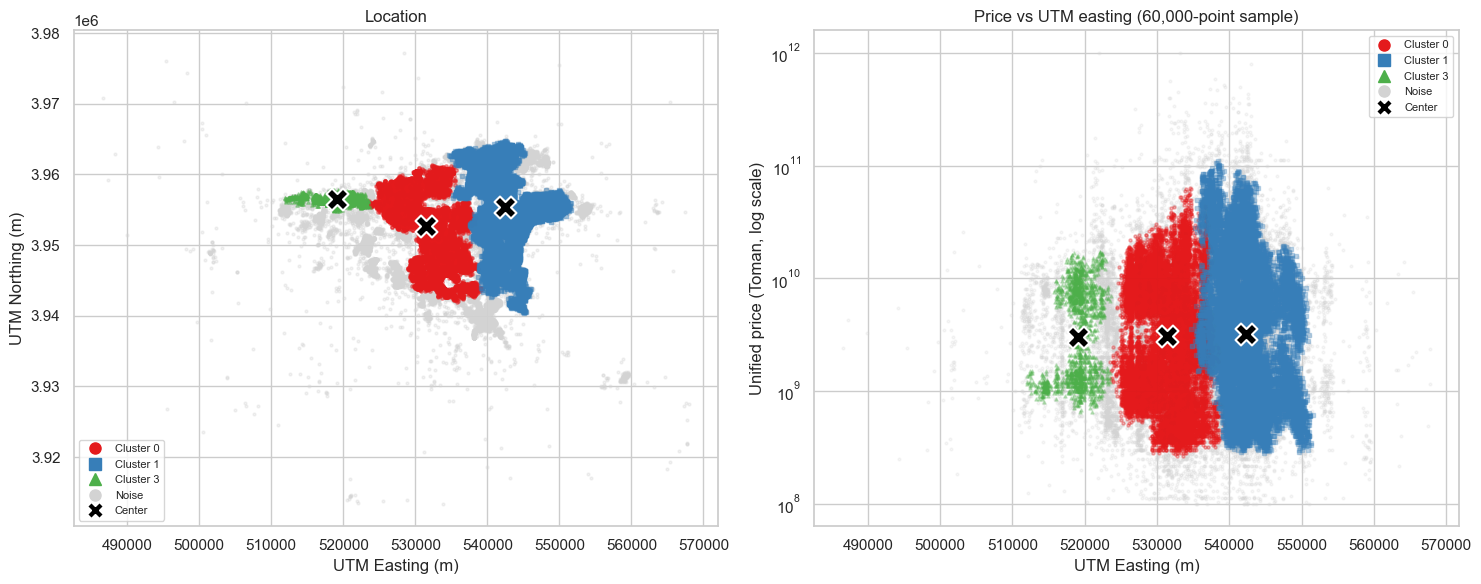

In [302]:
eps_final, ms_final = 0.12, 30

raw_labels = DBSCAN(eps=eps_final, min_samples=ms_final).fit_predict(X_dbscan)
sizes = pd.Series(raw_labels[raw_labels >= 0]).value_counts()
big = sizes[sizes >= 0.02 * len(raw_labels)]
print(f'{len(big)} clusters clear the 2% floor.')

labels_final = raw_labels.copy()
labels_final[~np.isin(labels_final, big.index) & (labels_final != -1)] = -1
ads_teh['cluster_dbscan'] = labels_final
noise_pct = (labels_final == -1).mean() * 100
print('Final noise %:', round(noise_pct, 1))

core_mask = ads_teh[ads_teh['cluster_dbscan'] >= 0]
profile = core_mask.groupby('cluster_dbscan').agg(
    n=('unified_price', 'size'), median_price=('unified_price', 'median'),
    median_lon=('location_longitude', 'median'), median_lat=('location_latitude', 'median'),
).round(2)
print(profile)

top_clusters = big.index
markers = ['o', 's', '^']
cmap = plt.get_cmap('Set1')

cent_geo = core_mask.groupby('cluster_dbscan')[['utm_x', 'utm_y']].mean()
cent_price = core_mask.groupby('cluster_dbscan')['unified_price'].median()

from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], marker=markers[i % 3], color=cmap(i), linestyle='',
                          markersize=8, alpha=1.0, label=f'Cluster {c}')
                  for i, c in enumerate(top_clusters)]
noise_handle = Line2D([0], [0], marker='o', color='lightgray', linestyle='', markersize=8, label='Noise')
center_handle = Line2D([0], [0], marker='X', color='black', linestyle='',
                        markersize=12, markeredgecolor='white', label='Center')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax = axes[0]
noise_mask = ads_teh['cluster_dbscan'] == -1
ax.scatter(ads_teh.loc[noise_mask, 'utm_x'], ads_teh.loc[noise_mask, 'utm_y'], c='lightgray', s=4, alpha=0.3)
for i, c in enumerate(top_clusters):
    sub = ads_teh[ads_teh['cluster_dbscan'] == c]
    ax.scatter(sub['utm_x'], sub['utm_y'], s=6, alpha=0.4, color=cmap(i), marker=markers[i % 3])
ax.scatter(cent_geo['utm_x'], cent_geo['utm_y'], c='black', marker='X', s=250,
           edgecolors='white', linewidths=1.5, zorder=5)
ax.set_xlabel('UTM Easting (m)'); ax.set_ylabel('UTM Northing (m)')
ax.set_title('Location')
ax.legend(handles=legend_handles + [noise_handle, center_handle], fontsize=8)

sample = ads_teh.sample(min(60_000, len(ads_teh)), random_state=42)
ax2 = axes[1]
ax2.scatter(sample.loc[sample['cluster_dbscan'] == -1, 'utm_x'], sample.loc[sample['cluster_dbscan'] == -1, 'unified_price'],
            c='lightgray', s=4, alpha=0.2)
for i, c in enumerate(top_clusters):
    sub = sample[sample['cluster_dbscan'] == c]
    ax2.scatter(sub['utm_x'], sub['unified_price'], s=5, alpha=0.3, color=cmap(i), marker=markers[i % 3])
ax2.scatter(cent_geo['utm_x'], cent_price, c='black', marker='X', s=250,
            edgecolors='white', linewidths=1.5, zorder=5)
ax2.set_yscale('log')
ax2.set_xlabel('UTM Easting (m)'); ax2.set_ylabel('Unified price (Toman, log scale)')
ax2.set_title(f'Price vs UTM easting ({len(sample):,}-point sample)')
ax2.legend(handles=legend_handles + [noise_handle, center_handle], fontsize=8)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right">

##### نتیجه

| خوشه | تعداد | سهم | میانه‌ی قیمت | میانه‌ی طول جغرافیایی |
|---|---|---|---|---|
| 0 | 47,323 | 41.0% | 3.05B | 51.35 |
| 1 | 38,808 | 33.7% | 3.23B | 51.47 |
| 3 | 3,192 | 2.8% | 3.04B | 51.21 |

قیمت سه خوشه تقریباً یکیه (۳٫۰۴ تا ۳٫۲۳ میلیارد)، پس DBSCAN تهران رو فقط جغرافیایی تقسیم کرده: خوشه‌ی ۱ شرق، خوشه‌ی ۰ مرکز و غرب و خوشه‌ی ۳ یه جیب باریک توی غرب. خوشه‌ی ۰ دو تیکه‌ی جدا داره، یعنی محدب نیست. خوشه‌ی ۲ زیر ۲٪ بود و نویز شد، برای همین برچسب‌ها ۰ و ۱ و ۳ان. نویز نهایی ۲۲٫۵٪ه.

</div>

<div dir="rtl" style="text-align:right">

**بررسی حساسیت:** همون زانو رو روی تهران و با همون بازه‌ی ۱ تا ۲۰ حساب می‌کنیم که با نتیجه‌ی ملی قابل مقایسه باشه.

</div>

In [303]:
X_teh = RobustScaler().fit_transform(ads_teh[km_cols])
wcss_teh = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_teh).inertia_
            for k in range(1, k_max + 1)]
k_knee_teh = find_knee(list(range(1, k_max + 1)), wcss_teh)
print(f'National knee (k=1..{k_max}):', k_knee, '| Tehran-only knee (same range):', k_knee_teh)

National knee (k=1..20): 6 | Tehran-only knee (same range): 6


<div dir="rtl" style="text-align:right">

زانوی ملی و تهران هر دو ۶ شد؛ پس دو مقیاس با هم جور درمیان.

</div>

<div dir="rtl" style="text-align:right">

### رگرسیون پارت 1
</div>

#### Dict

In [304]:
# FA_TO_SLUG: normalized Persian name -> English slug
FA_TO_SLUG = {
    # ==================== TEHRAN ====================
    'ولنجک': 'velenjak',
    'تجریش': 'tajrish',
    'دروس': 'darrous',
    'جردن': 'jordan',
    'سعادت آباد': 'saadat-abad',
    'شهرک غرب': 'shahrak-e-gharb',
    'اکباتان': 'ekbatan',
    'پونک': 'poonak',
    'نارمک': 'narmak',
    'تهرانپارس': 'tehranpars',
    'افسریه': 'afsariyeh',
    'ایوانک': 'eivanak',
    'چیتگر': 'chitgar',
    'گیشا': 'gisha',
    'امیرآباد': 'amir-abad',
    'یوسف آباد': 'yousef-abad',
    'ونک': 'vanak',
    'پاسداران': 'pasdaran',
    'فرمانیه': 'farmaniyeh',
    'زعفرانیه': 'zafaraniyeh',
    'الهیه': 'elahiyeh',
    'کامرانیه': 'kamraniyeh',
    'دولت آباد': 'dolat-abad',
    'هفت تیر': 'haftetir',
    'بهارستان': 'baharestan',
    'مولوی': 'molavi',
    'شوش': 'shoosh',
    'جیحون': 'jeyhoon',
    'بهمن': 'bahman',
    'یافت آباد': 'yaftabad',
    'آزادی': 'azadi',
    'اسلام آباد': 'eslamabad',
    'مهرآباد': 'mehrabad',
    'صادقیه': 'sadeghiyeh',
    'فدک': 'fadak',
    'حکمت': 'hekmat',
    'لاله': 'laleh',
    'گمرک': 'gomrok',
    'پامنار': 'pamenar',
    'ستارخان': 'sattarkhan',
    'انقلاب': 'enqelab',
    'فلسطین': 'felestin',
    'جمهوری': 'jomhoori',
    'قلهک': 'gholhak',
    'ابوذر': 'abouzar',
    'جنت آباد': 'janat-abad',
    'کوهک': 'kuhak',
    'تختی': 'takhti',
    'مجیدیه': 'majidiyeh',
    'ظفر': 'zafar',
    'تهرانسر': 'tehransar',
    'ملارد': 'malard',
    'اندیشه': 'andisheh',
    'شهریار': 'shahriar',
    'کیانشهر': 'kianshahr',
    'وصال': 'vesal',
    'میرداماد': 'mirdamad',
    'مطهری': 'motahari',
    'دربند': 'darband',
    'جلفا': 'jolfa',
    'زرگنده': 'zargandeh',
    'سید خندان': 'seyed-khandan',
    'احمدآباد': 'ahmadabad',
    'حشمتیه': 'heshamatiyeh',
    'امیرکبیر': 'amirkabirblvd',
    'آرژانتین': 'arjantin',
    'آذربایجان': 'azarbaijan',
    'حکیمیه': 'hakimiyeh',
    'لویزان': 'lavizan',
    'عطاران': 'attaran',
    'درکه': 'darakeh',
    'فرحزاد': 'farahzad',
    'پونک': 'poonak',
    'سازمان برنامه': 'sazamn-barnameh',
    'دردشت': 'dardasht',
    'عباس آباد': 'abbas-abad',
    'هفت حوض': 'haft-hoz',
    'شهرک ولیعصر': 'shahrak-valiasr',
    'شهرک چشمه': 'shahrak-e-cheshmeh',
    'شهرک امید': 'shahrak-e-omid',
    'شهرک کوهسار': 'shahrak-e-koohsar',
    'شهرک دانشگاه': 'shahrak-daneshgah',
    'شهرک آزادی': 'shahrak-e-azadi',
    'شهرک طالقانی': 'shahrak-e-taleghani',
    'شهرک شهید محلاتی': 'shahrak-e-mahalati',
    'شهرک کوثر': 'shahrak-kowsar',
    'شهرک ابوذر': 'shahrak-e-aboozar',
    'شهرک کاوه': 'shahrak-kaveh',
    'شهرک فردوس': 'shahrak-e-ferdows',
    'شهرک والفجر': 'shahrak-valfajr',
    'شهرک دریا': 'shahrak-e-darya',
    'شهرک ژاندارمری': 'shahrak-e-jandarmeri',
    'کوی فردوس': 'kooy-e-ferdos',
    'کوی کوثر': 'kuy-e-kowsar',
    'کوی مهر': 'kuy-mehr',
    'کوی رضوان': 'kooyramezan',   # (check spelling)
    'خواجه ربیع': 'khaje-rabi',
    'نواب صفوی': 'shahid-navab-safavi',
    'شهید دستغیب': 'shahid-dastgheyb',
    'شهید قربانی': 'shahid-qorbani',
    'شهید منتظری': 'shahid-montazeri',
    'شهید باقری': 'shahid-bagheri',
    'شهید بروجردی': 'shahid-borujerdi',

    # ==================== MASHHAD ====================
    'سجاد': 'sajjad',
    'وحید': 'vahid',
    'هنرستان': 'honarestan',
    'کوهسنگی': 'koohsangi',
    'شاندیز': 'tehran-shandiz',   # note: slug in your list is 'tehran-shandiz'
    'طبرسی': 'tabarsi',
    'امیریه': 'amiriyeh-mashhad',
    'وکیل آباد': 'vakilabad',
    'قاسم آباد': 'ghasemabad',
    'مهدی آباد': 'mahdi-abad',
    'صیاد شیرازی': 'sayyadshirazi',
    'امام رضا': 'emamreza',
    'طرق': 'toroq',
    'رضاشهر': 'rezashahr',
    'احمدآباد': 'ahmadabad',
    'خواجه ربیع': 'khaje-rabi',
    'رضا شهر': 'rezashahr',
    'مهدیآباد': 'mahdi-abad',
    'ابوذر': 'abouzar-mashhad',
    'الهیه': 'shahrak-elahiyeh',

    # ==================== ISFAHAN ====================
    'صفه': 'soffeh',
    'جلفا': 'jolfa',
    'چهارباغ': 'chaharbagh',
    'شهشهان': 'shahshahan',
    'بزرگمهر': 'bozorgmehr',
    'سلیمانیه': 'soleymanieh',
    'کاوه': 'shahrak-kaveh',
    'سپاهانشهر': 'sepahanshahr',
    'رهنان': 'rehnan',
    'مرداویج': 'mardavich',
    'جویباره': 'joubareh',
    'آپادانا': 'shahrak-e-apadana',
    'ملکشهر': 'malekshahr',
    'زینبیه': 'zeynabieh',
    'خمینی شهر': 'khomeinishahr',
    'شاهین شهر': 'shahin',
    'دولت آباد': 'dolat-abad-isfahan',
    'احمدآباد': 'ahmad-abad-isfahan',
    'خانه اصفهان': 'khaneesfahan',
    'چهارصد دستگاه': 'chaharsad-dastgah-karaj',  # (verify)
    'امیریه': 'amiriyeh-isfahan',
    'گلستان': 'golestan-isfahan',
    'فرهنگ': 'farhang-isfahan',
    'ملک شهر': 'malekshahr',
    'شاهین شهر': 'shahin',
    'بهرام آباد': 'bahram-abad',

    # ==================== SHIRAZ ====================
    'زند': 'zand',
    'قصرالدشت': 'qasrdasht',
    'پردیس': 'pardis',
    'معالی آباد': 'goldasht-moaliabad',
    'سعدی': 'saadi',
    'حافظیه': 'hafeziyeh',
    'چوگیا': 'chogiah',
    'ارم': 'eram-shiraz',
    'زرگری': 'zargari',
    'شاهزاده قاسم': 'shahzyed',   # approximate
    'نی ریز': None,               # skip
    'پودنک': 'pdonak',
    'نشاط': 'neshat-shiraz',
    'مهدی آباد': 'mahdiabad',
    'شهرک گلها': 'shahrak-golha-shiraz',
    'کوی زهرا': 'kuyezahra',
    'شهرک سعدی': 'sharak-e-sadi',
    'گلستان': 'golestan',
    'مهدیآباد': 'mahdiabad',
    'شهرک پرواز': 'parvaztown',
    'شهرک امام': 'kuy-emam',
    'قلعه شاهزاده': 'ghaleh-shahzadeh-bagom',

    # ==================== KARAJ ====================
    'گوهردشت': 'gohardasht',
    'عظیمیه': 'azimieh',
    'مهرشهر': 'mehrshahr',
    'جهانشهر': 'jahanshahr',
    'باغستان': 'baghestan',
    'حصار': 'hesarak',    # close to 'hesarak'
    'کلاک': 'kalak',
    'خرمدشت': 'khorramdasht',
    'مشکین دشت': 'meshkindasht',
    'کوی کارمندان': 'kuy-modarres-karaj',
    'رجایی شهر': 'rajaee',
    'فردیس': 'fardovan',
    'گرمدره': 'fardovan',
    'شهرک الهیه': 'golestan-karaj',
    'شهرک گلستان': 'golestan-karaj',
    'کمال شهر': 'kamalshahr',
    'محمدشهر': 'mohammadabad',
    'ماهدشت': 'malekabad-karaj',
    'اشتهارد': None,   # not in list

    # ==================== AHVAZ ====================
    'کیانپارس': 'kianpars',
    'زیتون کارمندی': 'zeytunkarmandi',
    'زیتون کارگری': 'zeytunkargari',
    'امانیه': 'amaniyeh-ahvaz',
    'کیان آباد': 'kianabad',
    'پادادشهر': 'padadshahr',
    'کمپلو': 'camplojonoobi',
    'لشکرآباد': 'lashkarabad',
    'گلستان': 'golestan-ahvaz',
    'کیان': 'kian',
    'کوی ملت': 'mellirah',
    'شهرک نفت': 'shahrak-naft',
    'کوروش': 'koorosh',
    'زیتون': 'zeytunkargari',
    'پردیس': 'pardis-ahvaz',

    # ==================== RASHT ====================
    'گلسار': 'golsar',
    'منظریه': 'manzarieh',
    'معلم': 'moalem',
    'پیربازار': 'pir-bazar' if False else None,  # skip if unsure
    'سعدی': 'saadi',
    'فلسطین': 'rasht-felestin',
    'بازار': 'rasht-bazaar',
    'میدان شهرداری': None,
    'گلستان': 'golestan',
    'مطهری': 'rasht-motahari',
    'امام حسین': 'rasht-emam-hossein',
    'رشتیان': 'rasht-rashtian',
    'پورسینا': 'rasht-poursina',

    # ==================== QOM ====================
    'انقلاب': 'enqelab-ghom',
    'هنرستان': 'honarestan-ghom',
    'صدف': 'sadaf',
    'توحید': 'tohid-ghom',
    'هفت تیر': 'haftetir-ghom',
    'آزادگان': 'azadegan-qom',
    'پردیسان': 'pardisan-ghom',
    'قمر بنی هاشم': 'shahrak-e-qamar' if False else None,
    'نیروگاه': 'nirou-entezamie' if False else None,

    # ==================== GENERIC / MULTI-CITY ====================
    'پاسداران': 'pasdaran',
    'شهید رجایی': 'shahid-rajaee',
    'ولیعصر': 'valiasr',            # NOTE: ambiguous, only match with prefix
    'اقدسیه': 'aghdasieh',
    'نیاوران': 'niavaran',
    'فرمانیه': 'farmaniyeh',
    'محمدیه': 'mohammadiyeh-shiraz',
    'شهرک شهید بهشتی': 'shahrakebeheshti',
    'شهرک شهید کشوری': 'kuy-shahid-keshvari',
    'سرآسیاب': 'sarasiab-doolab',
    'حمزه آباد': 'hamzeh-abad',
    'نظام آباد': 'nezam-abad',
    'ملک آباد': 'malek-abad',
    'کاظم آباد': 'kazem-abad',
    'عبدل آباد': 'abdol-abad',
    'سلطان آباد': 'soltan-abad',
    'یوسف آباد': 'yousef-abad',
    'عباس آباد': 'abbas-abad',
    'حسن آباد': 'hasan-abad-baqer-far',
    'حسین آباد': 'hosein-abad',
    'علی آباد': 'ali-abad',
    'امیر آباد': 'amir-abad',
    'ملت': 'mellirah',
    'هاشم آباد': 'hashem-abad',
    'شمس آباد': 'shams-abad',
    'فاطمیه': 'fatemiye',
    'صفا': None,
    'بهار': 'bahar',
    'بهاران': 'baharan',
    'لاله': 'laleh',
    'پیروزی': 'pirouzi',
    'شهدا': 'shohada',
    'طالقانی': 'taleghani',
    'صداقت': None,
    'شریعتی': 'shariatijonoobi',
    'کارگر': 'north-karegar',
    'توحید': 'tohid',
    'مطهری': 'motahari',
    'بهشتی': 'beheshti',
    'آزادگان': 'azadegan',
    'فرهنگ': 'farhang',
    'دانشجو': 'daneshjoo',
    'دانشگاه': 'danesh',
    'فرهنگیان': 'farhangian',
    'معلم': 'moalem',
    'کشاورز': 'bolvar-e-keshavarz',
    'امام خمینی': 'emamkhomeini',
    'امام حسین': 'emam-hosein',
    'امام رضا': 'emamreza',
    'سجاد': 'sajjad',
    'صاحب الزمان': 'saheb-al-zaman',
    'صاحبزمان': 'saheb-al-zaman-shiraz',
    'زهرا': 'kuyezahra',
    'معصوم': None,
    'کوثر': 'kosar',
    'رضوان': 'rezvan',
    'یاس': 'shahrak-yas',
    'بهارستان': 'baharestan',
    'گلستان': 'golestan',
    'گلشن': 'golshan',
    'گلزار': 'golzar',
    'گلبهار': 'golbahar-isfahan',
    'بنفشه': 'banafsheh',
    'نیلوفر': 'niloufar',
    'شقایق': 'shaqayeq',
    'سحر': None,
    'سپیده': None,
    'ماهان': None,
    'ایرانشهر': 'iranshahr',
    'ایران': 'tehran-iran',
    'جمهوری': 'jomhoori',
    'آزادشهر': 'azad-shahr',
    'قائمیه': 'ghaemiyeh',
    'احمدیه': 'ahmadi',
    'عبدالله': None,

    # ==================== NOTORIOUS STREETS THAT ARE NEIGHBORHOOD SLUGS ====================
    'ولیعصر': 'valiasr',
    'شریعتی': 'shariatijonoobi',
    'جمهوری': 'jomhoori',
    'انقلاب': 'enqelab',
    'آزادی': 'azadi',
    'کارگر شمالی': 'north-karegar',
    'کارگر جنوبی': 'north-karegar',   # verify
    'ستارخان': 'sattarkhan',
    'نواب': 'shahid-navab-safavi',
    'صیاد': 'sayyadshirazi',
    'صیاد شیرازی': 'sayyadshirazi',
    'همت': None,
    'چمران': None,
    'مدرس': 'modarres',
    'مطهری': 'motahari',
    'بهشتی': 'beheshti',
    'مفتح': 'mofatteh',
    'فلسطین': 'felestin',
    'قدس': 'qods',
    'وحدت': 'vahdattown',
    'فجر': 'valfajr',
    'صدف': 'sadaf',
    'دریا': 'darya',
    'کوهسار': 'shahrak-e-koohsar',
    'کوه سنگی': 'koohsangi',
    'کوهک': 'kuhak',
    'کوهک': 'dokuhak',
}

# Drop entries with None values (unverified)
FA_TO_SLUG = {k: v for k, v in FA_TO_SLUG.items() if v}

#### preprocessing

only credit value -> 903 rows

In [305]:
df_inves = df.copy()
df_inves = df_inves[['price_value', 'rent_value', 'credit_value']]
df_inves[(df_inves['price_value'].isna() == True) & (df_inves['rent_value'].isna() == True) & (df_inves['credit_value'].isna() == False)]

,price_value,rent_value,credit_value
843,NaN,NaN,2.000000e+06
1602,NaN,NaN,2.300000e+09
2302,NaN,NaN,7.000000e+08
2373,NaN,NaN,2.000000e+08
2878,NaN,NaN,1.400000e+09
...,...,...,...
991980,NaN,NaN,2.300000e+08
993517,NaN,NaN,2.500000e+09
994950,NaN,NaN,9.000000e+08
996399,NaN,NaN,3.500000e+08


only rent value -> 130 rows

In [306]:
df_inves[(df_inves['price_value'].isna() == True) & (df_inves['rent_value'].isna() == False) & (df_inves['credit_value'].isna() == True)]

,price_value,rent_value,credit_value
6756,NaN,5.919256e+07,NaN
7527,NaN,0.000000e+00,NaN
13290,NaN,1.000000e+06,NaN
15528,NaN,2.000000e+06,NaN
27919,NaN,2.400000e+08,NaN
...,...,...,...
962530,NaN,2.000000e+08,NaN
964481,NaN,2.700000e+09,NaN
969643,NaN,6.000000e+06,NaN
981155,NaN,3.000000e+08,NaN


Full credit is considered 20% of the property's price and 1,000,000 Toman credit ≈ 30,000 Toman monthly rent
so we calculate full price using rent and credit value we have for properties with missing values for price value

In [307]:
df['final_price'] = df['price_value']

credit = df['credit_value'].fillna(0)
rent = df['rent_value'].fillna(0)

converted_price = (
    credit + (rent / 30000) * 1000000
) / 0.20

df.loc[
    df['price_value'].isna() &
    ((df['credit_value'].notna()) |
     (df['rent_value'].notna())),
    'final_price'
] = converted_price

we have 79429 data which we cant find out the value in almost any way so we just drop them

In [308]:
df['final_price'].isna().sum()

np.int64(79429)

filling neighbor_hood slug using des/title

In [309]:
PERSIAN_DIGITS = '۰۱۲۳۴۵۶۷۸۹'
LATIN_DIGITS   = '0123456789'
DIGIT_TABLE = str.maketrans(PERSIAN_DIGITS, LATIN_DIGITS)

def normalize_fa(text):
    if not isinstance(text, str):
        return ''
    # 1) ZWNJ -> space so 'سعادتآباد' == 'سعادت آباد'
    text = text.replace('\u200c', ' ')
    # 2) Arabic yeh / kaf -> Persian
    text = text.replace('ي', 'ی').replace('ك', 'ک')
    # 3) Arabic alef variants -> bare alef
    text = text.replace('أ', 'ا').replace('إ', 'ا').replace('آ', 'ا')
    # 4) Persian digits -> Latin
    text = text.translate(DIGIT_TABLE)
    # 5) Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalize_slug(slug):
    if not isinstance(slug, str):
        return ''
    s = slug.strip().lower()
    s = s.replace('_', '-')
    s = re.sub(r'-+', '-', s).strip('-')
    return s


# Apply to dict keys once
FA_TO_SLUG_NORM = {normalize_fa(k): normalize_slug(v) for k, v in FA_TO_SLUG.items()}

# And build a lookup for the *existing* slugs in your data so we return
# the exact spelling your dataframe uses.
existing_slugs = df['neighborhood_slug'].dropna().unique().tolist()
existing_lookup = {normalize_slug(s): s for s in existing_slugs}

In [310]:
PERSIAN = '\u0600-\u06FF'

# Sort longest first so 'شهرک غرب' beats 'غرب' if both were present
FA_NAMES = sorted(FA_TO_SLUG_NORM.keys(), key=len, reverse=True)

# For each name: escape, turn spaces into flexible whitespace, wrap in
# negative lookarounds so we don't match inside a longer Persian word.
parts = []
for name in FA_NAMES:
    esc = re.escape(name)
    esc = esc.replace(r'\ ', r'\s+')      # a space in the key = 1+ whitespace
    parts.append(esc)

BIG_RE = re.compile(
    r'(?<![' + PERSIAN + r'])(' + '|'.join(parts) + r')(?![' + PERSIAN + r'])'
)

def find_slug(text_norm):
    """text_norm must already be run through normalize_fa()."""
    if not text_norm:
        return None
    hits = BIG_RE.findall(text_norm)
    if not hits:
        return None
    # Prefer the longest matched name (most specific).
    best_fa = max(set(hits), key=len)
    slug = FA_TO_SLUG_NORM.get(best_fa)
    if slug is None:
        return None
    # Return the exact spelling that already exists in the dataframe, if any.
    return existing_lookup.get(normalize_slug(slug), slug)

In [311]:
# Build normalized text once (title + description)
title_n = df['title'].map(normalize_fa)
desc_n  = df['description'].map(normalize_fa)
text_n  = (title_n + ' ' + desc_n).str.strip()

missing = df['neighborhood_slug'].isna()
print(f"Missing before: {missing.sum()}")

# Pass 1 — try to match from title first (strongest signal)
from_title = title_n[missing].map(find_slug)

# Pass 2 — for whatever's still unmatched, try description
still = missing & from_title.isna()
from_desc = desc_n[still].map(find_slug)

# Combine
matched = from_title.fillna(from_desc)

# Write back only to the rows that were missing
df.loc[missing, 'neighborhood_slug'] = matched

# Report
print(f"Matched from title:       {from_title.notna().sum()}")
print(f"Matched from description: {from_desc.notna().sum()}")
print(f"Still missing:            {df['neighborhood_slug'].isna().sum()}")
print(f"Coverage:                 {df['neighborhood_slug'].notna().mean():.1%}")

Missing before: 562861
Matched from title:       103223
Matched from description: 113123
Still missing:            346515
Coverage:                 65.3%


we can use location_longitude and location_latitude to fill almost 222k of the 346k missing left after preprocess later

In [312]:
bro = df[(df['neighborhood_slug'].isna() == True) & (df['location_latitude'].isna() == False) & (df['location_longitude'].isna() == False)][['location_longitude', 'location_latitude']]
bro

,location_longitude,location_latitude
10,51.757549,35.778664
19,58.655319,34.333435
20,49.465981,33.454094
28,47.181553,34.368042
30,51.733246,35.313835
...,...,...
999977,46.386959,38.022659
999978,49.581680,35.987911
999988,51.696510,36.520672
999989,51.107094,35.580193


In [313]:
df['neighborhood_slug'] = (
    df['neighborhood_slug'].fillna('unknown')
)

In [314]:
df_model = df[(df['price_value_clean'].isna() == False) & (df['neighborhood_slug'].isna() == False) & (df['cat2_slug'] != 'temporary-rent') & (df['building_size'].isna() == False)]
len(df_model)

519919

In [315]:
df_model.loc[df_model['has_balcony'] == 'true', 'has_balcony'] = True
df_model.loc[df_model['has_balcony'] == 'false', 'has_balcony'] = False
df_model.loc[df_model['has_balcony'] == 'unselect', 'has_balcony'] = False
df_model.loc[df_model['has_cooling_system'] == 'unselect', 'has_cooling_system'] = False
df_model.loc[df_model['has_restroom'] == 'unselect', 'has_restroom'] = False
df_model.loc[df_model['has_warm_water_provider'] == 'unselect', 'has_warm_water_provider'] = False
df_model.loc[df_model['has_heating_system'] == 'unselect', 'has_heating_system'] = False

df_model.loc[df_model['has_heating_system'] == False, 'has_heating_system'] = 'None'
df_model.loc[df_model['has_cooling_system'] == False, 'has_cooling_system'] = 'None'
df_model.loc[df_model['has_restroom'] == False, 'has_restroom'] = 'None'
df_model.loc[df_model['has_warm_water_provider'] == False, 'has_warm_water_provider'] = 'None'

df_model['has_balcony'] = df_model['has_balcony'].astype(bool)

In [316]:
to_change_numeric = ['has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse',
    'has_parking', 'has_water', 'has_electricity', 'has_gas',
    'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna', 'is_rebuilt']

for cols in to_change_numeric:
    df_model.loc[df_model[cols] == True, cols] = 1
    df_model.loc[df_model[cols] == False, cols] = 0
    print(df_model[cols].unique())

[0]
[0 1]
[1 0]
[1 0]
[1 0]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1]
[0 1]


future engineering and handeling contruction year

In [317]:
df_model.loc[df_model['construction_year'] == 'قبل از 1370', 'construction_year'] = 1370
df_model['farsi_year'] = df_model['farsi_date'].apply(lambda date: date.year)
df_model['construction_year'] = df_model['construction_year'].fillna(df_model['construction_year'].median())
df_model['age'] = df_model['farsi_year'] - df_model['construction_year'].astype(int)
df_model['age']

1         19
4          0
7         10
8          7
9         16
          ..
999990     2
999991    15
999992     2
999995     0
999997    33
Name: age, Length: 519919, dtype: int64

#### Model

In [318]:
feature_columns = [
    'cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'building_size' ,'has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse',
    'has_parking', 'has_water', 'has_electricity', 'has_gas',
    'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna','has_heating_system', 'has_cooling_system',
    'has_restroom', 'has_warm_water_provider', 'is_rebuilt', 'age'
    
]

X = df_model[feature_columns].copy()
y = df_model['final_price'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.10, random_state=7)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/9, random_state=7)


y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

print('Train:', len(X_train))
print('Validation:', len(X_val))
print('Test:', len(X_test))

Train: 415935
Validation: 51992
Test: 51992


In [319]:
numeric_cols = ['building_size', 'age']

cat_cols = ['has_heating_system', 'has_cooling_system',
    'has_restroom', 'has_warm_water_provider', 'cat2_slug', 'cat3_slug']

bool_cols = ['has_business_deed', 'has_balcony', 'has_elevator', 'has_warehouse',
    'has_parking', 'has_water', 'has_electricity', 'has_gas',
    'has_security_guard', 'has_barbecue', 'has_pool', 'has_jacuzzi', 'has_sauna', 'is_rebuilt']

spc_cols = ['city_slug', 'neighborhood_slug']

bool_preprocess = Pipeline([
    ('scaler', StandardScaler())
])

cat_preprocess = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=20))
])

numeric_preprocess = Pipeline([
    ('scaler', StandardScaler())
])

city_neighbor_preprocess = Pipeline([
    ('target_encode', TargetEncoder(cv=5, smooth='auto', random_state=27))
])

preprocesses = ColumnTransformer(transformers=[
    ('bool', bool_preprocess, bool_cols),
    ('numerical', numeric_preprocess, numeric_cols),
    ('cat', cat_preprocess, cat_cols),
    ('spc', city_neighbor_preprocess, spc_cols)
])

Ridge Model

In [324]:
model_pipeline = Pipeline([
    ('preproc', preprocesses),
    ('model', Ridge(solver='auto', fit_intercept= True, random_state=7))
    
], memory="./sk_cache")

alphas = np.logspace(-4, 4, 17) 

param_grid = {"model__alpha": alphas}

cv = KFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(
    model_pipeline,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

gs.fit(X_train, y_train_log)
print("Best alpha   :", gs.best_params_["model__alpha"])
print("Best CV RMSE :", -gs.best_score_)

pred_log = gs.predict(X_test)

pred = np.expm1(pred_log)

print("Test R²:", r2_score(y_test, pred))
print("Test MAE:", mean_absolute_error(y_test, pred))
print("Test MSE:", np.mean((y_test - pred) ** 2))

Fitting 5 folds for each of 17 candidates, totalling 85 fits
Best alpha   : 100.0
Best CV RMSE : 0.8768707147178952
Test R²: 0.05130519797806843
Test MAE: 4281557412.2724476
Test MSE: 5.7032949761383216e+20


XGboost Model

In [325]:
xgb_pipeline = Pipeline([
    ('preprocess', preprocesses),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=7,
        n_jobs=-1
    ))
])

param_grid = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [5, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8, 1.0]
}

y_train_log = np.log1p(y_train)

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train,
    y_train_log
)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:",-grid_search.best_score_)

best_model = grid_search.best_estimator_

validation_pred_log = best_model.predict(X_val)

validation_pred = np.expm1(validation_pred_log)

validation_r2 = r2_score(
    y_val,
    validation_pred
)

validation_mae = mean_absolute_error(
    y_val,
    validation_pred
)

validation_mse = mean_squared_error(
    y_val,
    validation_pred
)

print("Validation R²:", validation_r2)
print("Validation MAE:", validation_mae)
print("Validation MSE:", validation_mse)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV RMSE: -0.6002815394713907
Validation R²: 0.26970218966401294
Validation MAE: 3073533743.5957265
Validation MSE: 3.838981724125823e+20


<div dir="rtl" style="text-align:right">

### رگرسیون پارت 2
</div>

Problem 2: Price Prediction (Regression) — one model for sale **and** rent

**Task (from the brief):** given a property's features and its **deal type**, predict its price: the sale price for sale ads, and the converted deposit (`رهن تبدیل‌شده`) for rent ads.

 Design decisions (and why)

| Decision | Choice | Reason |
|---|---|---|
| **Target** | Sale ads → `price_value`. Rent ads → `credit_value + rent_value × (1,000,000 / 30,000)` | Exactly the "converted price" convention in the brief: *sale → price, rent → converted deposit*. This puts sale and rent on one comparable scale so one model can serve both. |
| **Which ads** | `residential-sell`, `commercial-sell`, `residential-rent`, `commercial-rent` | `temporary-rent` is a per-night price and `real-estate-services` is not a property price. |
| **Loss on** | `log(target)` | Prices are heavily right-skewed and span 4+ orders of magnitude (rent vs. sale). |
| **Deal type as input** | `deal_type` + `ad_type` features, and neighbourhood/city target-encoding **per ad type** | A neighbourhood's *sale* level and *rent* level are different; mixing them in one encoding would be confounded by the sale/rent mix. |
| **Leakage rules** | `price_value`, `rent_value`, `credit_value`, all `*_mode`, `transformable_*`, `transformed_*`, `comparable_rent`, `rent_price_*`, `title`, `description` are **never** model inputs | They are the target itself, a direct function of it, or free text that often quotes the price. |
| **Evaluation protocol** | 80 / 10 / 10 split. All model & hyper-parameter selection uses **validation only**. Test is used **once**, at the end. | Required by the brief. |
| **Metrics** | R², MAE, MSE (raw Toman, as required) + log-scale R²/RMSE + median % error + per-deal-type breakdown | Raw-scale metrics are dominated by a few very expensive properties, so log-scale and % metrics show the typical error honestly. |

In [326]:
DATA_PATH = "Divar.csv"                  # <- path to the full dataset (500k - 1M rows)
SEED = 7
CREDIT_PER_RENT = 1_000_000 / 30_000     # brief: 1M Toman credit ~ 30k Toman monthly rent
DEAL_TYPES = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent",
]
SEARCH_N = 150_000                       # rows used while searching hyper-parameters (speed)
N_ITER = {"ridge": 11, "rf": 6, "hgb": 12, "xgb": 12}   # random-search budget per model

np.random.seed(SEED)

#### 1. Load only the columns we may legitimately use
Loading a subset of columns keeps memory low for 1M rows. Note that the price/rent/credit columns are loaded **only to build the target and filter bad ads**; they are not features.

In [327]:
RAW_COLS = [
    "cat2_slug",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
    "created_at_month",
    "user_type",
    "price_mode",
    "price_value",
    "rent_mode",
    "rent_value",
    "credit_mode",
    "credit_value",     # target construction only
    "land_size",
    "building_size",
    "deed_type",
    "has_business_deed",
    "floor",
    "rooms_count",
    "total_floors_count",
    "unit_per_floor",
    "has_balcony",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "construction_year",
    "is_rebuilt",
    "has_water",
    "has_warm_water_provider",
    "has_electricity",
    "has_gas",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "has_security_guard",
    "has_barbecue",
    "building_direction",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
    "floor_material",
    "location_latitude",
    "location_longitude",
]

raw = pd.read_csv(DATA_PATH, usecols=lambda c: c in RAW_COLS, low_memory=False)

for c in RAW_COLS:                      # be robust to a missing column
    if c not in raw.columns:
        raw[c] = np.nan

print("rows loaded:", len(raw))
raw["cat2_slug"].value_counts()

rows loaded: 1000000


cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

#### 2. Build the target (sale price / converted rent-deposit) and clean it

* **Sale ads:** keep only `price_mode == "مقطوع"` (a fixed price; in "توافقی"/"مجانی" modes the number is not a real price) and a plausible range.
* **Rent ads:** each of rent and credit is a *component*:
  * missing value **and** missing mode → the component is simply absent → `0` (e.g. full-deposit ads have no rent);
  * `مجانی` → `0`; `توافقی` (negotiable) → ad is dropped; a value outside the plausible range (typo/placeholder such as 10¹⁴) → ad is dropped.
  * Then `target = credit + rent × (1,000,000 / 30,000)`.

In [328]:
df = raw[raw["cat2_slug"].isin(DEAL_TYPES)].copy()
df["ad_type"] = np.where(df["cat2_slug"].str.contains("sell"), "sell", "rent")
n0 = len(df)

num = lambda s: pd.to_numeric(s, errors="coerce")


def clean_component(value, mode, lo, hi):
    # Return a cleaned rent/credit amount. NaN means 'invalid ad' (typo, placeholder, negotiable).
    value = num(value)
    out = pd.Series(np.nan, index=value.index)
    ok = (mode.isna() | (mode == "مقطوع")) & value.between(lo, hi)
    out[ok] = value[ok]
    out[(value.isna() & mode.isna()) | (mode == "مجانی")] = 0.0     # absent or free component

    return out


# --- sale ---
price = num(df["price_value"])
sell_ok = (
    (df["ad_type"] == "sell")
    & (df["price_mode"] == "مقطوع")
    & price.between(1e8, 1e12)
)

# --- rent (+ credit) converted to a single comparable number ---
rent_c = clean_component(
    df["rent_value"],
    df["rent_mode"],
    100_000,
    500_000_000,
)
cred_c = clean_component(
    df["credit_value"],
    df["credit_mode"],
    1_000_000,
    1_000_000_000_000,
)
conv = cred_c + rent_c * CREDIT_PER_RENT
rent_ok = (df["ad_type"] == "rent") & conv.between(2e7, 1e12)

df["target"] = np.where(sell_ok, price, np.where(rent_ok, conv, np.nan))
df = df[df["target"].notna()].copy()

print(f"ads with a usable target: {len(df):,} of {n0:,}  ({len(df)/n0:.1%})")


# --- building size is the strongest physical feature: keep only plausible values ---
bs = num(df["building_size"])
df["building_size"] = bs.where(bs.between(10, 5000))
df = df[df["building_size"].notna()].copy()

print(f"after dropping missing/implausible building_size: {len(df):,}")
print(
    df.groupby("cat2_slug")["target"]
    .describe(percentiles=[.05, .5, .95])
    .round(0)
    .T
)

ads with a usable target: 894,937 of 950,694  (94.1%)
after dropping missing/implausible building_size: 882,630
cat2_slug  commercial-rent  commercial-sell  residential-rent  \
count         7.027200e+04     2.693700e+04      2.709840e+05   
mean          1.451672e+09     1.151086e+10      9.325051e+08   
std           5.271493e+09     3.595892e+10      5.509962e+09   
min           2.000000e+07     1.000000e+08      2.000000e+07   
5%            8.333333e+07     4.500000e+08      1.466667e+08   
50%           5.833333e+08     4.000000e+09      4.833333e+08   
95%           5.000000e+09     3.800000e+10      2.666667e+09   
max           5.017667e+11     1.000000e+12      9.008889e+11   

cat2_slug  residential-sell  
count          5.144370e+05  
mean           6.579676e+09  
std            2.105616e+10  
min            1.000000e+08  
5%             5.000000e+08  
50%            2.900000e+09  
95%            2.000000e+10  
max            1.000000e+12  


#### 3. Feature engineering (row-level only, no target statistics → no leakage)

Neighbourhood/city are high-cardinality, so they are **target-encoded inside the modelling pipeline** (cross-fitted on the training data only), not here.
Rooms, floors, age, geo coordinates and the listing month are cleaned and bounded; unknown values stay `NaN` and are imputed inside the pipeline.

In [329]:
FLAG_COLS = [
    "has_business_deed",
    "has_balcony",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "has_water",
    "has_electricity",
    "has_gas",
    "has_security_guard",
    "has_barbecue",
    "has_pool",
    "has_jacuzzi",
    "has_sauna",
    "is_rebuilt",
]

CAT_COLS = [
    "deal_type",
    "ad_type",
    "cat3_slug",
    "user_type",
    "deed_type",
    "building_direction",
    "floor_material",
    "has_heating_system",
    "has_cooling_system",
    "has_restroom",
    "has_warm_water_provider",
]

NUM_COLS = [
    "log_building_size",
    "log_land_size",
    "rooms",
    "floor",
    "total_floors",
    "unit_per_floor",
    "floor_ratio",
    "age",
    "lat",
    "lon",
    "t_month",
    "cal_month",
]

BIN_COLS = FLAG_COLS + ["has_geo"]
TE_COLS = ["city_ad", "city_nbh_ad"]          # city / neighbourhood level, *separately per ad type*
FEATURES = NUM_COLS + BIN_COLS + CAT_COLS + TE_COLS

ROOMS_MAP = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج": 5,
    "پنج یا بیشتر": 5,
}


def to_binary(s):
    # handles bool, 0/1, 'true'/'false', 'unselect', NaN
    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["1", "1.0", "true", "yes"])
        .astype(int)
    )


def engineer(d):
    o = pd.DataFrame(index=d.index)

    o["deal_type"] = d["cat2_slug"]
    o["ad_type"] = d["ad_type"]
    o["cat3_slug"] = d["cat3_slug"]

    # size
    o["log_building_size"] = np.log(d["building_size"])
    land = num(d["land_size"])
    o["log_land_size"] = np.log(land.where(land.between(10, 50_000)))

    # rooms / floors
    r = d["rooms_count"].astype(str).str.strip()
    o["rooms"] = r.map(ROOMS_MAP).astype(float).fillna(
        pd.to_numeric(r, errors="coerce")
    )

    fl = num(d["floor"])
    tot = num(d["total_floors_count"])
    fl = fl.where(fl.between(-2, 60))
    tot = tot.where(tot.between(1, 60))

    o["floor"] = fl
    o["total_floors"] = tot
    o["floor_ratio"] = (fl / tot).where(
        (tot > 0) & (fl >= 0) & (fl <= tot)
    )

    upf = num(d["unit_per_floor"])
    o["unit_per_floor"] = upf.where(upf.between(1, 20))

    # time: Jalali year from the (first-of-month) Gregorian date, so we do not need jdatetime
    dt = pd.to_datetime(d["created_at_month"], errors="coerce")
    jy = dt.dt.year - np.where(dt.dt.month >= 4, 621, 622)
    o["t_month"] = dt.dt.year * 12 + dt.dt.month
    o["cal_month"] = dt.dt.month

    cy = num(d["construction_year"].replace("قبل از 1370", 1369))
    cy = cy.where(cy.between(1300, 1410))
    o["age"] = (jy - cy).clip(0, 100)

    # geo
    lat = num(d["location_latitude"])
    lon = num(d["location_longitude"])
    lat = lat.where(lat.between(24, 40))
    lon = lon.where(lon.between(44, 64))

    o["lat"] = lat
    o["lon"] = lon
    o["has_geo"] = (lat.notna() & lon.notna()).astype(int)

    # flags + categoricals
    for c in FLAG_COLS:
        o[c] = to_binary(d[c])

    for c in [
        "user_type",
        "deed_type",
        "building_direction",
        "floor_material",
        "has_heating_system",
        "has_cooling_system",
        "has_restroom",
        "has_warm_water_provider",
    ]:
        o[c] = (
            d[c]
            .fillna("missing")
            .astype(str)
            .replace({"unselect": "missing"})
        )

    # location keys (encoded later, inside the pipeline)
    city = d["city_slug"].fillna("unknown").astype(str)
    nbh = d["neighborhood_slug"].fillna("unknown").astype(str)

    o["city_ad"] = city + "|" + d["ad_type"]
    o["city_nbh_ad"] = city + "|" + nbh + "|" + d["ad_type"]

    return o


data = engineer(df)
data["target"] = df["target"]
data["target_log"] = np.log(df["target"])

# re-posted ads would otherwise land in train AND test (an easy form of leakage): drop exact repeats
dedup_cols = [
    c for c in FEATURES if c not in ("t_month", "cal_month")
] + ["target"]

before = len(data)
data = data.drop_duplicates(subset=dedup_cols)

print(f"removed {before-len(data):,} duplicate ads; {len(data):,} rows remain")

data[FEATURES].isna().mean().round(2).loc[lambda s: s > 0]

removed 4,949 duplicate ads; 877,681 rows remain


log_land_size     0.80
rooms             0.12
floor             0.40
total_floors      0.66
unit_per_floor    0.66
floor_ratio       0.66
age               1.00
lat               0.34
lon               0.34
dtype: float64

#### 4. Train / validation / test split (80 / 10 / 10, stratified by deal type)

In [330]:
strat = lambda d: d["deal_type"] if d["deal_type"].value_counts().min() >= 10 else None

train_val, test = train_test_split(
    data,
    test_size=0.10,
    random_state=SEED,
    stratify=strat(data),
)

train, val = train_test_split(
    train_val,
    test_size=1 / 9,
    random_state=SEED,
    stratify=strat(train_val),
)

X_train = train[FEATURES]
y_train = train["target_log"].values

X_val = val[FEATURES]
y_val = val["target_log"].values

print(
    f"train {len(train):,} | validation {len(val):,} | test {len(test):,}  "
    "(test stays untouched until Section 9)"
)
print(train["deal_type"].value_counts(normalize=True).round(3))

train 702,144 | validation 87,768 | test 87,769  (test stays untouched until Section 9)
deal_type
residential-sell    0.582
residential-rent    0.308
commercial-rent     0.080
commercial-sell     0.031
Name: proportion, dtype: float64


#### 5. Preprocessing + metrics

* numeric → median imputation (+ missing-indicator), scaling only for the linear model
* binary flags → as is
* low-cardinality categoricals → one-hot (rare levels grouped)
* city / neighbourhood (per ad type) → **TargetEncoder with internal 5-fold cross-fitting**, fitted on the training rows only

In [331]:
def make_preprocessor(scale=False):
    num_steps = [
        (
            "imp",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True,
            ),
        )
    ]

    te_steps = [
        (
            "te",
            TargetEncoder(
                target_type="continuous",
                cv=5,
                smooth="auto",
                random_state=SEED,
            ),
        )
    ]

    if scale:
        num_steps.append(("sc", StandardScaler()))
        te_steps.append(("sc", StandardScaler()))

    return ColumnTransformer(
        [
            ("num", Pipeline(num_steps), NUM_COLS),
            ("bin", "passthrough", BIN_COLS),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=100,
                    sparse_output=False,
                    dtype=np.float32,
                ),
                CAT_COLS,
            ),
            ("te", Pipeline(te_steps), TE_COLS),
        ],
        sparse_threshold=0,
    )


def report(y_log, p_log, smear=1.0):
    # metrics in raw Toman (as the brief requires) + log scale + median % error
    y = np.exp(y_log)
    p = np.exp(p_log) * smear

    return {
        "R2": r2_score(y, p),
        "MAE": mean_absolute_error(y, p),
        "MSE": mean_squared_error(y, p),
        "R2_log": r2_score(y_log, p_log),
        "RMSE_log": np.sqrt(mean_squared_error(y_log, p_log)),
        "MedAPE_%": 100 * np.median(np.abs(p - y) / y),
    }


# fit preprocessors on TRAIN only; transform validation with the train-fitted encoders
prep_tree = make_preprocessor(False)
prep_lin = make_preprocessor(True)

Xtr_t = prep_tree.fit_transform(X_train, y_train).astype(np.float32)
Xva_t = prep_tree.transform(X_val).astype(np.float32)

Xtr_l = prep_lin.fit_transform(X_train, y_train).astype(np.float32)
Xva_l = prep_lin.transform(X_val).astype(np.float32)

print("design matrix:", Xtr_t.shape)


# ---- baseline: median log-price per deal type ----
med = train.groupby("deal_type")["target_log"].median()
base_val = val["deal_type"].map(med).values

print("Baseline (median per deal type) on validation:")
pd.Series(report(y_val, base_val)).round(3)

design matrix: (702144, 98)
Baseline (median per deal type) on validation:


R2         -4.000000e-03
MAE         3.553495e+09
MSE         2.843482e+20
R2_log      3.790000e-01
RMSE_log    1.088000e+00
MedAPE_%    5.964100e+01
dtype: float64

#### 6. Compare models and tune hyper-parameters — **validation set only**

Each candidate gets a random search on a training sub-sample (for speed) and is scored on the validation set; the best configuration is then refitted on the **full** training set. Models: Ridge (linear baseline), Random Forest, Gradient Boosting (sklearn `HistGradientBoostingRegressor`) and, if installed, XGBoost.

In [332]:
SPACES = {
    "ridge": {
        "alpha": list(np.logspace(-2, 3, 11))
    },
    "rf": {
        "n_estimators": [100, 200],
        "max_depth": [None, 20, 30],
        "min_samples_leaf": [2, 5, 10],
        "max_features": [0.3, 0.5, 0.8],
        "max_samples": [0.5, 0.8],
    },
    "hgb": {
        "learning_rate": [0.05, 0.1, 0.15],
        "max_iter": [400, 800],
        "max_leaf_nodes": [31, 63, 127, 255],
        "min_samples_leaf": [20, 50, 100],
        "l2_regularization": [0.0, 1.0, 10.0],
        "max_features": [0.5, 0.8, 1.0],
    },
    "xgb": {
        "n_estimators": [800],
        "learning_rate": [0.03, 0.06, 0.1],
        "max_depth": [6, 8, 10],
        "subsample": [0.7, 0.9],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 5, 20],
        "reg_lambda": [1, 5, 20],
    },
}


def make_model(name, params, early_stop=True):
    p = dict(params)

    if name == "ridge":
        return Ridge(**p)

    if name == "rf":
        return RandomForestRegressor(
            n_jobs=-1,
            random_state=SEED,
            **p,
        )

    if name == "hgb":
        return HistGradientBoostingRegressor(
            random_state=SEED,
            early_stopping=True,
            n_iter_no_change=20,
            **p,
        )

    if name == "xgb":
        return XGBRegressor(
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
            early_stopping_rounds=30 if early_stop else None,
            **p,
        )


def fit_model(name, model, X, y, X_eval=None, y_eval=None):
    if name == "xgb" and X_eval is not None:
        model.fit(
            X,
            y,
            eval_set=[(X_eval, y_eval)],
            verbose=False,
        )      # validation set used for early stopping
    else:
        model.fit(X, y)

    return model


candidates = ["ridge", "rf", "hgb"] + (["xgb"] if HAS_XGB else [])

sub = np.random.RandomState(SEED).choice(
    len(Xtr_t),
    min(SEARCH_N, len(Xtr_t)),
    replace=False,
)

best = {}
val_pred = {}
rows = []

for name in candidates:
    Xa, Xv = (Xtr_l, Xva_l) if name == "ridge" else (Xtr_t, Xva_t)
    idx = slice(None) if name == "ridge" else sub
    grid = int(np.prod([len(v) for v in SPACES[name].values()]))

    top_rmse = np.inf
    top_params = None

    for params in ParameterSampler(
        SPACES[name],
        n_iter=min(N_ITER[name], grid),
        random_state=SEED,
    ):
        m = fit_model(
            name,
            make_model(name, params),
            Xa[idx],
            y_train[idx],
            Xv,
            y_val,
        )

        rmse = np.sqrt(mean_squared_error(y_val, m.predict(Xv)))

        if rmse < top_rmse:
            top_rmse = rmse
            top_params = params

    # refit the winning configuration on the FULL training set
    m = fit_model(
        name,
        make_model(name, top_params),
        Xa,
        y_train,
        Xv,
        y_val,
    )

    val_pred[name] = m.predict(Xv)
    best[name] = {"params": top_params, "model": m}

    rows.append(
        {
            "model": name,
            **report(y_val, val_pred[name]),
            "params": top_params,
        }
    )

    print(
        f"{name:6s} done  | validation RMSE(log) = "
        f"{rows[-1]['RMSE_log']:.4f}"
    )

val_table = (
    pd.DataFrame(rows)
    .set_index("model")
    .sort_values("RMSE_log")
)

val_table.drop(columns="params").round(3)

ridge  done  | validation RMSE(log) = 0.7095
rf     done  | validation RMSE(log) = 0.6262
hgb    done  | validation RMSE(log) = 0.6259
xgb    done  | validation RMSE(log) = 0.6256


,R2,MAE,MSE,R2_log,RMSE_log,MedAPE_%
model,,,,,,
xgb,0.446,1.844111e+09,1.569511e+20,0.795,0.626,19.916
hgb,0.446,1.841779e+09,1.569619e+20,0.795,0.626,20.133
rf,0.428,1.843014e+09,1.618332e+20,0.794,0.626,19.430
ridge,0.243,2.321192e+09,2.144272e+20,0.736,0.710,26.493


In [333]:
best_name = val_table.index[0]

print("Selected model (lowest validation RMSE on log-price):", best_name)
print("Hyper-parameters:", best[best_name]["params"])


# --- back-transformation: exp(E[log y]) underestimates the mean price. Duan's smearing factor fixes that. ---
p_val = val_pred[best_name]
smear = float(np.mean(np.exp(y_val - p_val)))

plain = report(y_val, p_val)
smeared = report(y_val, p_val, smear)

USE_SMEAR = smeared["MSE"] < plain["MSE"]            # decided on VALIDATION
SMEAR = smear if USE_SMEAR else 1.0

print(
    f"smearing factor = {smear:.3f} -> "
    f"{'used' if USE_SMEAR else 'not used'}"
)

pd.DataFrame(
    {
        "no smearing": plain,
        "with smearing": smeared,
    }
).round(3)


Selected model (lowest validation RMSE on log-price): xgb
Hyper-parameters: {'subsample': 0.9, 'reg_lambda': 5, 'n_estimators': 800, 'min_child_weight': 20, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
smearing factor = 1.358 -> used


,no smearing,with smearing
R2,4.460000e-01,4.470000e-01
MAE,1.844111e+09,2.239999e+09
MSE,1.569511e+20,1.566123e+20
R2_log,7.950000e-01,7.950000e-01
RMSE_log,6.260000e-01,6.260000e-01
MedAPE_%,1.991600e+01,3.884600e+01


#### 7. Validation error analysis (still no test data)
Where does the chosen model fail? This guides the discussion in the presentation (and any further feature work).

In [334]:
ev = val[["deal_type", "cat3_slug"]].copy()

ev["y_log"] = y_val
ev["p_log"] = p_val
ev["y"] = np.exp(y_val)
ev["p"] = np.exp(p_val) * SMEAR
ev["ape"] = np.abs(ev["p"] - ev["y"]) / ev["y"]

ev["size_bucket"] = pd.cut(
    np.exp(val["log_building_size"]),
    [0, 60, 90, 120, 180, 300, 5000],
)

print("Validation metrics per deal type:")
print(
    pd.DataFrame(
        {
            k: report(g["y_log"].values, g["p_log"].values, SMEAR)
            for k, g in ev.groupby("deal_type")
        }
    )
    .T
    .round(3)
)

print("\nMedian % error by building-size bucket:")
print(
    (
        ev.groupby("size_bucket", observed=True)["ape"]
        .agg(["median", "count"])
        * [100, 1]
    ).round(1)
)

print("\nWorst 10 validation errors (absolute, Toman):")
ev.assign(
    abs_err=(ev.p - ev.y).abs()
).nlargest(
    10,
    "abs_err",
)[["deal_type", "cat3_slug", "y", "p", "abs_err"]]

Validation metrics per deal type:
                     R2           MAE           MSE  R2_log  RMSE_log  \
commercial-rent   0.420  7.673340e+08  1.053376e+19   0.546     0.841   
commercial-sell   0.404  6.565758e+09  4.574491e+20   0.515     0.925   
residential-rent  0.039  4.013901e+08  4.516602e+19   0.810     0.401   
residential-sell  0.456  3.187609e+09  2.198011e+20   0.650     0.668   

                  MedAPE_%  
commercial-rent     46.705  
commercial-sell     54.417  
residential-rent    35.494  
residential-sell    39.531  

Median % error by building-size bucket:
             median  count
size_bucket               
(0, 60]        40.1  13842
(60, 90]       35.1  23328
(90, 120]      35.7  18365
(120, 180]     38.2  16153
(180, 300]     48.1   9353
(300, 5000]    60.6   6645

Worst 10 validation errors (absolute, Toman):


,deal_type,cat3_slug,y,p,abs_err
994603,residential-sell,house-villa-sell,9.000000e+11,5.549861e+09,8.944501e+11
702219,residential-sell,apartment-sell,9.000000e+11,1.602778e+10,8.839722e+11
394173,residential-rent,apartment-rent,8.008000e+11,2.079313e+09,7.987207e+11
267286,residential-sell,apartment-sell,9.990000e+11,2.624843e+11,7.365157e+11
352307,residential-rent,apartment-rent,7.000000e+11,9.108240e+08,6.990892e+11
120637,residential-sell,plot-old,1.111111e+08,6.210614e+11,6.209503e+11
627783,residential-sell,plot-old,6.150000e+11,3.552204e+10,5.794780e+11
994989,residential-sell,apartment-sell,7.000000e+11,1.285621e+11,5.714379e+11
838213,residential-sell,house-villa-sell,5.555556e+11,4.810201e+09,5.507454e+11
790834,residential-sell,plot-old,6.000000e+11,6.410935e+10,5.358906e+11


#### 8. Final model: refit on train + validation with the chosen hyper-parameters
The hyper-parameters are frozen; we only use the extra 10% of data for fitting. The test set is **still untouched**.

In [335]:
trainval = pd.concat([train, val])
params_final = dict(best[best_name]["params"])

if best_name == "xgb":                                  # no validation set left for early stopping -> fix the tree count
    params_final["n_estimators"] = int(best[best_name]["model"].best_iteration) + 1

prep_final = make_preprocessor(scale=(best_name == "ridge"))

Xtv = prep_final.fit_transform(
    trainval[FEATURES],
    trainval["target_log"].values,
).astype(np.float32)

final_model = make_model(
    best_name,
    params_final,
    early_stop=False,
).fit(
    Xtv,
    trainval["target_log"].values,
)

final_pipe = Pipeline([
    ("prep", prep_final),
    ("model", final_model),
])

print("final model fitted on", f"{len(trainval):,}", "rows")

final model fitted on 789,912 rows


#### 9. One-time evaluation on the TEST set

In [336]:
X_test = test[FEATURES]
y_test = test["target_log"].values

p_test = final_pipe.predict(X_test)

test_report = pd.Series(report(y_test, p_test, SMEAR))

print("=== TEST RESULTS (raw Toman) ===")
print(f"R2  : {test_report['R2']:.4f}")
print(
    f"MAE : {test_report['MAE']:,.0f}   "
    f"({test_report['MAE']/1e9:.3f} billion Toman)"
)
print(
    f"MSE : {test_report['MSE']:.4e}  "
    f"({test_report['MSE']/1e18:.3f} (billion Toman)^2)"
)

print(
    f"\nlog-scale R2 : {test_report['R2_log']:.4f} | "
    f"RMSE(log): {test_report['RMSE_log']:.4f} | "
    f"median % error: {test_report['MedAPE_%']:.1f}%"
)

print("\nValidation vs test (a large gap would mean over-fitting to validation):")

pd.DataFrame(
    {
        "validation": report(y_val, p_val, SMEAR),
        "test": report(y_test, p_test, SMEAR),
    }
).round(3)

=== TEST RESULTS (raw Toman) ===
R2  : 0.3836
MAE : 2,291,652,208   (2.292 billion Toman)
MSE : 1.8710e+20  (187.103 (billion Toman)^2)

log-scale R2 : 0.7893 | RMSE(log): 0.6340 | median % error: 38.9%

Validation vs test (a large gap would mean over-fitting to validation):


,validation,test
R2,4.470000e-01,3.840000e-01
MAE,2.239999e+09,2.291652e+09
MSE,1.566123e+20,1.871026e+20
R2_log,7.950000e-01,7.890000e-01
RMSE_log,6.260000e-01,6.340000e-01
MedAPE_%,3.884600e+01,3.887000e+01


In [337]:
# per deal type, on the test set
et = test[["deal_type", "cat3_slug"]].copy()

et["y_log"] = y_test
et["p_log"] = p_test

per_type = pd.DataFrame(
    {
        k: report(g["y_log"].values, g["p_log"].values, SMEAR)
        for k, g in et.groupby("deal_type")
    }
).T

per_type.insert(0, "n_test", et["deal_type"].value_counts())

per_type.round(3)

,n_test,R2,MAE,MSE,R2_log,RMSE_log,MedAPE_%
commercial-rent,6991,0.207,7.705768e+08,1.243216e+19,0.538,0.837,45.522
commercial-sell,2680,0.458,6.855854e+09,4.872752e+20,0.494,0.970,53.832
residential-rent,27027,0.058,3.705358e+08,2.561134e+19,0.813,0.393,35.817
residential-sell,51071,0.366,3.277021e+09,2.807229e+20,0.642,0.681,39.539


#### 10. Diagnostics for the presentation

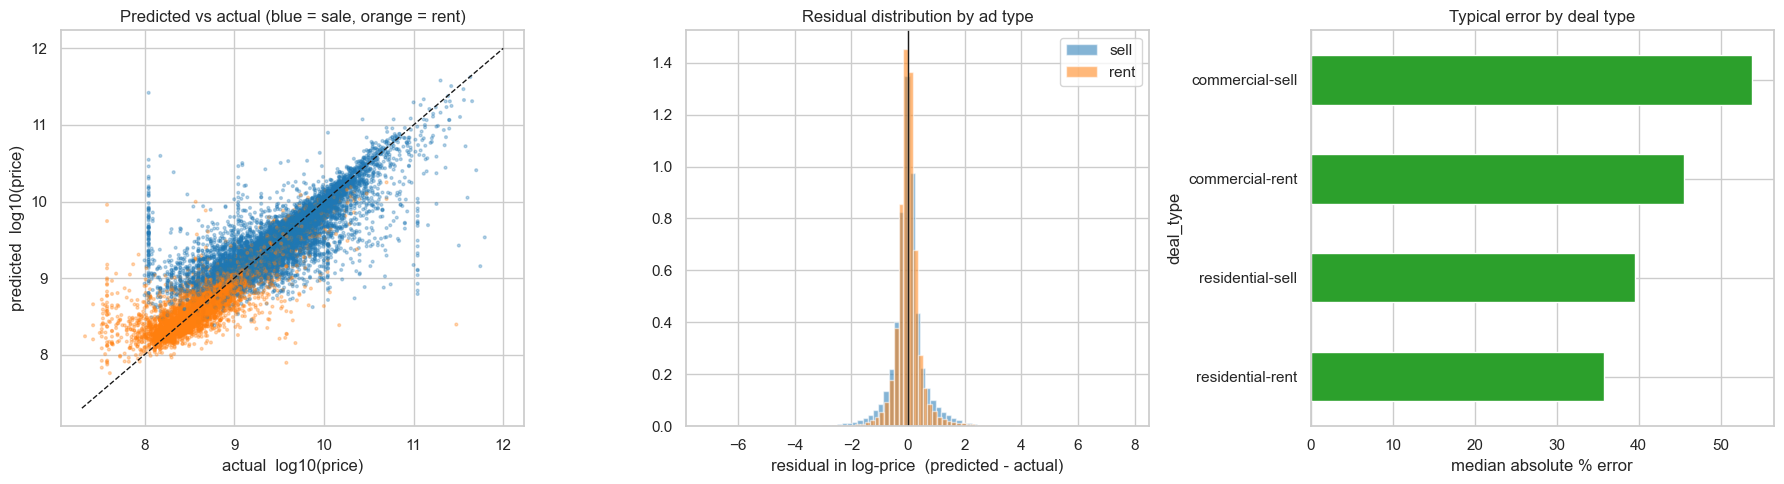

In [338]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

s = np.random.RandomState(SEED).choice(
    len(y_test),
    min(20_000, len(y_test)),
    replace=False,
)

colors = np.where(
    test["ad_type"].values[s] == "sell",
    "tab:blue",
    "tab:orange",
)

ax[0].scatter(
    y_test[s] / np.log(10),
    p_test[s] / np.log(10),
    s=4,
    alpha=.3,
    c=colors,
)

lims = [
    min(y_test.min(), p_test.min()) / np.log(10),
    max(y_test.max(), p_test.max()) / np.log(10),
]

ax[0].plot(lims, lims, "k--", lw=1)

ax[0].set(
    xlabel="actual  log10(price)",
    ylabel="predicted  log10(price)",
    title="Predicted vs actual (blue = sale, orange = rent)",
)


res = p_test - y_test

for t, c in [("sell", "tab:blue"), ("rent", "tab:orange")]:
    ax[1].hist(
        res[test["ad_type"].values == t],
        bins=80,
        alpha=.55,
        color=c,
        label=t,
        density=True,
    )

ax[1].axvline(0, color="k", lw=1)
ax[1].legend()

ax[1].set(
    xlabel="residual in log-price  (predicted - actual)",
    title="Residual distribution by ad type",
)


grp = (
    et.assign(
        ape=100
        * np.abs(
            np.exp(et.p_log) * SMEAR - np.exp(et.y_log)
        )
        / np.exp(et.y_log)
    )
    .groupby("deal_type")["ape"]
    .median()
    .sort_values()
)

grp.plot.barh(
    ax=ax[2],
    color="tab:green",
)

ax[2].set(
    xlabel="median absolute % error",
    title="Typical error by deal type",
)

plt.tight_layout()
plt.show()

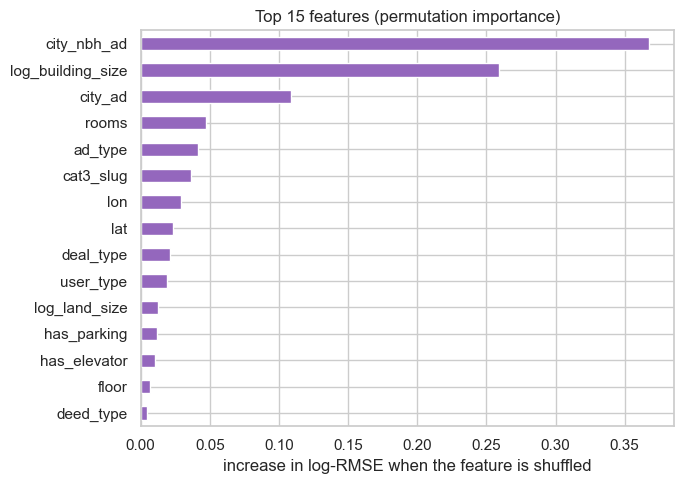

In [339]:
# permutation importance on a test sub-sample (analysis only; the model is already final)
s2 = np.random.RandomState(SEED).choice(
    len(X_test),
    min(15_000, len(X_test)),
    replace=False,
)

pi = permutation_importance(
    final_pipe,
    X_test.iloc[s2],
    y_test[s2],
    scoring="neg_root_mean_squared_error",
    n_repeats=3,
    random_state=SEED,
    n_jobs=1,
)

imp = pd.Series(
    pi.importances_mean,
    index=FEATURES,
).sort_values(ascending=False)

imp.head(15)[::-1].plot.barh(
    figsize=(7, 5),
    color="tab:purple",
)

plt.xlabel("increase in log-RMSE when the feature is shuffled")
plt.title("Top 15 features (permutation importance)")
plt.tight_layout()
plt.show()

#### 11. Notes for the written analysis / presentation

* **Why log-target:** prices span rent-deposits of tens of millions to sale prices of tens of billions. Fitting `log(price)` lets one model serve both deal types and keeps a few extreme listings from dominating the fit.
* **Pooled log-scale R² is flattered by the deal type itself:** sale and rent targets live on different scales, so simply knowing `deal_type` already explains a lot of the variance. Quote the **per-deal-type** table as the honest picture of model quality, and the pooled number only as a summary.
* **Raw-scale R², MAE and MSE look worse than the log-scale numbers.** They are dominated by a small number of very expensive properties (large errors squared). Explain this next to the median-%-error and per-deal-type tables, which describe the *typical* error.
* **Linear vs tree models:** if Ridge is clearly worse than the tree models, price depends non-linearly on location × size × deal type (interactions), which is exactly what trees capture.
* **No leakage:** every price/rent/credit-related column is excluded from the inputs; neighbourhood encodings are cross-fitted inside the training data; exact duplicate ads are removed before splitting.
* **Honest limitations:** location is only as precise as the neighbourhood/city slugs and (often missing) coordinates; condition, view and finish quality are not in the data; ad text is deliberately not used because it may quote the price.
* **Possible extensions (bonus):** text features from `title`/`description` after masking numbers, spatial neighbour features (median price of the k nearest ads, computed on training rows only), separate models per deal type vs. the single model here.